# STAP Barcode Pipeline Result Analysis

This notebook analyzes the barcode-first STAP oligo pipeline output. It compares the oligo identity inferred from the R3 barcode against the Bowtie2 aligned reference sequence, estimates how many deduplicated read1 TSS events are misaligned, and plots methylation-state counts for five oligos after removing those misaligned reads.

## 1. Packages To Install

Install these in the environment you use to launch Jupyter:

```bash
mamba install -c conda-forge -c bioconda jupyterlab pandas numpy matplotlib seaborn pysam
```

This notebook reads TSV files and BAM files, so it does not need `openpyxl`.

In [17]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import pysam
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

## Input Paths

The defaults point at the full oligo500 barcode-pipeline output. Edit `SAMPLE` or `RESULT_DIR` if you want to analyze a different run.

In [18]:
SAMPLE = "STAP_TSS_500_oligos_S2"

repo = Path.cwd()
if repo.name == "notebooks":
    repo = repo.parent

RESULT_DIR = repo / "results" / "barcode_pipeline" / SAMPLE
BAM = RESULT_DIR / f"{SAMPLE}.bowtie2.dedup.bam"
OLIGO_METADATA = RESULT_DIR / f"{SAMPLE}.oligo_metadata.tsv"
DEMUX_STATS = RESULT_DIR / f"{SAMPLE}.demux.stats.tsv"
TSS_TABLE = RESULT_DIR / f"{SAMPLE}.tss_by_oligo_meth.tsv"

for path in [RESULT_DIR, BAM, OLIGO_METADATA, DEMUX_STATS, TSS_TABLE]:
    print(path, "OK" if path.exists() else "MISSING")

/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_500_oligos_S2 OK
/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_500_oligos_S2/STAP_TSS_500_oligos_S2.bowtie2.dedup.bam OK
/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_500_oligos_S2/STAP_TSS_500_oligos_S2.oligo_metadata.tsv OK
/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_500_oligos_S2/STAP_TSS_500_oligos_S2.demux.stats.tsv OK
/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_500_oligos_S2/STAP_TSS_500_oligos_S2.tss_by_oligo_meth.tsv OK


## Load Run Summaries

`oligo_metadata.tsv` is generated in the same order used to build the 500-oligo reference FASTA. For `data_500.fa`, that means row 1 corresponds to `seq1`, row 2 to `seq2`, and so on. We use this to define the expected aligned reference for each barcode-derived `OLIGO=` tag.

In [19]:
demux_stats = pd.read_csv(DEMUX_STATS, sep="\t")
display(demux_stats)

oligo_meta = pd.read_csv(OLIGO_METADATA, sep="\t", dtype=str).fillna("")
oligo_meta["expected_chrom"] = [f"seq{i}" for i in range(1, len(oligo_meta) + 1)]
oligo_to_chrom = dict(zip(oligo_meta["oligo_id"], oligo_meta["expected_chrom"]))

print(f"Loaded {len(oligo_meta):,} oligos")
display(oligo_meta[["oligo_id", "barcode", "expected_chrom"]].head())

,metric,count
0,oligo_records_loaded,500
1,barcode_mismatches_0,35691195
2,barcode_mismatches_1,805319
3,barcode_offset_0,36496514
4,barcode_orientation_forward,26842
...,...,...
77,meth_TAG_10%,9065818
78,meth_TGA_20%,2556722
79,meth_TTT_100%,962475
80,total_triplets,43138388


Loaded 500 oligos


,oligo_id,barcode,expected_chrom
0,NativeTSS:2355:GCCCATGCAG,GCCCATGCAG,seq1
1,NativeTSS:2355:ACGCGGATTG,ACGCGGATTG,seq2
2,NativeTSS:1013:CGCACACTGG,CGCACACTGG,seq3
3,NativeTSS:1013:TAGCTCTGTG,TAGCTCTGTG,seq4
4,NativeTSS:3190:GTCCGGTTTG,GTCCGGTTTG,seq5


## 2. Misalignment From Barcode Identity Versus Aligned Sequence

A read is called **aligned_to_barcode_oligo** when the BAM reference name matches the expected `seqN` for the `OLIGO=` tag in the read name. It is called **misaligned_to_other_oligo** when the barcode says one oligo but Bowtie2 places read1 on another oligo sequence.

This section uses deduplicated primary read1 alignments, because those are the reads used for TSS quantification.

In [4]:
METH_RE = re.compile(r"(?:^|\|)METH=([^|]+)")
OLIGO_UMI_RE = re.compile(r"\|OLIGO=(.+)_([ACGTNacgtn]{22})$")

def parse_query_name(query_name):
    meth_match = METH_RE.search(query_name)
    oligo_match = OLIGO_UMI_RE.search(query_name)
    meth = meth_match.group(1) if meth_match else "UNKNOWN"
    oligo = oligo_match.group(1) if oligo_match else "UNKNOWN"
    umi = oligo_match.group(2).upper() if oligo_match else "UNKNOWN"
    return oligo, meth, umi

def read1_tss_1based(read):
    return int(read.reference_end) if read.is_reverse else int(read.reference_start) + 1

rows = []
with pysam.AlignmentFile(BAM, "rb") as bam:
    for read in bam.fetch(until_eof=True):
        if not read.is_read1:
            continue
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        if read.is_qcfail or read.is_duplicate:
            continue
        oligo, meth, umi = parse_query_name(read.query_name)
        aligned_chrom = bam.get_reference_name(read.reference_id)
        expected_chrom = oligo_to_chrom.get(oligo, "UNKNOWN")
        if expected_chrom == "UNKNOWN":
            status = "unknown_oligo_tag"
        elif aligned_chrom == expected_chrom:
            status = "aligned_to_barcode_oligo"
        else:
            status = "misaligned_to_other_oligo"
        rows.append({
            "read_name": read.query_name,
            "oligo_id": oligo,
            "meth_state": meth,
            "umi": umi,
            "expected_chrom": expected_chrom,
            "aligned_chrom": aligned_chrom,
            "tss_position": read1_tss_1based(read),
            "mapq": read.mapping_quality,
            "is_reverse": read.is_reverse,
            "status": status,
        })

read1_df = pd.DataFrame(rows)
print(f"Deduplicated primary mapped read1 records: {len(read1_df):,}")
display(read1_df.head())

Deduplicated primary mapped read1 records: 236,109


,read_name,oligo_id,meth_state,umi,expected_chrom,aligned_chrom,tss_position,mapq,is_reverse,status
0,VH01570:206:AAJ2NL3M5:1:1510:40499:49390|METH=20%|OLIGO=NativeTSS:2355:GCCCATGCAG_CTGCGCGGTTTAATAGAAAATA,NativeTSS:2355:GCCCATGCAG,20%,CTGCGCGGTTTAATAGAAAATA,seq1,seq1,140,42,False,aligned_to_barcode_oligo
1,VH01570:206:AAJ2NL3M5:1:1608:70569:8573|METH=10%|OLIGO=NativeTSS:2355:GCCCATGCAG_ACAAAACAAATAGAGATGTGTG,NativeTSS:2355:GCCCATGCAG,10%,ACAAAACAAATAGAGATGTGTG,seq1,seq1,143,34,False,aligned_to_barcode_oligo
2,VH01570:206:AAJ2NL3M5:1:2610:29346:47137|METH=10%|OLIGO=NativeTSS:2355:GCCCATGCAG_TGGTACACGTGAGGGAGAAAAA,NativeTSS:2355:GCCCATGCAG,10%,TGGTACACGTGAGGGAGAAAAA,seq1,seq1,146,34,False,aligned_to_barcode_oligo
3,VH01570:206:AAJ2NL3M5:1:1401:29025:54577|METH=10%|OLIGO=NativeTSS:2355:GCCCATGCAG_ACGCGCACAGATGGGTGAGGTA,NativeTSS:2355:GCCCATGCAG,10%,ACGCGCACAGATGGGTGAGGTA,seq1,seq1,148,42,False,aligned_to_barcode_oligo
4,VH01570:206:AAJ2NL3M5:1:1209:69262:14006|METH=10%|OLIGO=NativeTSS:2355:GCCCATGCAG_GCGATCTCATAAGGGAAAAGGG,NativeTSS:2355:GCCCATGCAG,10%,GCGATCTCATAAGGGAAAAGGG,seq1,seq1,148,34,False,aligned_to_barcode_oligo


In [5]:
status_summary = (
    read1_df.groupby("status")
    .size()
    .rename("reads")
    .reset_index()
    .assign(frac=lambda d: d["reads"] / d["reads"].sum())
    .sort_values("reads", ascending=False)
)
display(status_summary)

misaligned_df = read1_df.query("status == 'misaligned_to_other_oligo'").copy()
print(f"Misaligned read1 records: {len(misaligned_df):,}")
print(f"Misaligned fraction: {len(misaligned_df) / max(len(read1_df), 1):.2%}")

,status,reads,frac
0,aligned_to_barcode_oligo,235297,0.996561
1,misaligned_to_other_oligo,812,0.003439


Misaligned read1 records: 812
Misaligned fraction: 0.34%


In [6]:
mis_by_meth = (
    read1_df.assign(is_misaligned=read1_df["status"].eq("misaligned_to_other_oligo"))
    .groupby("meth_state")
    .agg(total_reads=("read_name", "size"), misaligned_reads=("is_misaligned", "sum"))
    .assign(misaligned_frac=lambda d: d["misaligned_reads"] / d["total_reads"])
    .sort_index()
)
display(mis_by_meth)

top_misalignment_pairs = (
    misaligned_df.groupby(["oligo_id", "expected_chrom", "aligned_chrom"])
    .size()
    .rename("reads")
    .reset_index()
    .sort_values("reads", ascending=False)
    .head(20)
)
display(top_misalignment_pairs)

,total_reads,misaligned_reads,misaligned_frac
meth_state,,,
0%,46758,125,0.002673
0.1%,46308,161,0.003477
1%,49576,170,0.003429
10%,50659,151,0.002981
100%,8067,27,0.003347
20%,18549,64,0.003450
40%,8373,63,0.007524
60%,7819,51,0.006523


,oligo_id,expected_chrom,aligned_chrom,reads
22,NativeTSS:1874:GTGTCTCTTT,seq186,seq185,76
199,SyntheticTSS:2625038:ATGGTGGACT,seq300,seq334,56
23,NativeTSS:1914:ACCCTCACAA,seq134,seq133,30
67,NativeTSS:3055:GATGCCCGTA,seq146,seq145,24
132,NativeTSS:596:CTGCACCATC,seq138,seq137,21
141,NativeTSS:6687:CTCAGTGGTA,seq26,seq182,18
25,NativeTSS:1914:CTCAATCCTC,seq133,seq134,16
127,NativeTSS:559:GCCCTCTACA,seq44,seq43,16
50,NativeTSS:259:CATCGGGCGT,seq178,seq177,15
51,NativeTSS:259:CATCGGGCGT,seq178,seq21,14


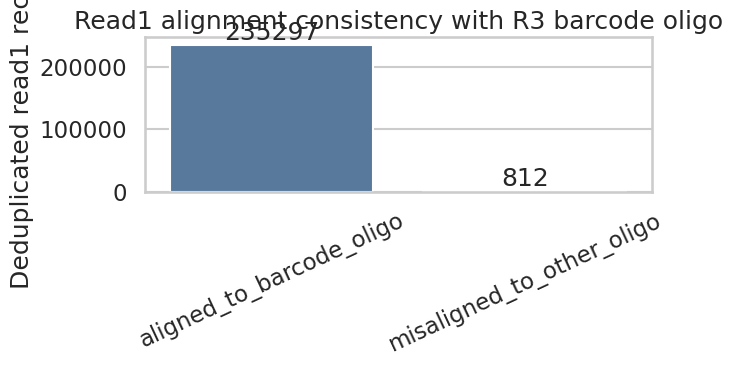

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_status = status_summary.copy()
sns.barplot(data=plot_status, x="status", y="reads", ax=ax, color="#4C78A8")
ax.set_xlabel("")
ax.set_ylabel("Deduplicated read1 records")
ax.set_title("Read1 alignment consistency with R3 barcode oligo")
ax.tick_params(axis="x", rotation=25)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.tight_layout()

## 3. Five-Oligo Methylation Counts After Removing Misaligned Reads

The next cells discard reads where the aligned reference sequence disagrees with the barcode-derived oligo. By default, the notebook selects the five oligos with the most remaining read1 records. You can replace `selected_oligos` with any five `oligo_id` values.

In [7]:
aligned_only = read1_df.query("status == 'aligned_to_barcode_oligo'").copy()

# Set this manually if desired, e.g.:
# selected_oligos = ["NativeTSS:2355:GCCCATGCAG", "NativeTSS:2355:ACGCGGATTG", ...]
selected_oligos = (
    aligned_only.groupby("oligo_id")
    .size()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

print("Selected oligos:")
for oligo in selected_oligos:
    print("  ", oligo)

meth_order = ["0%", "0.1%", "1%", "10%", "20%", "40%", "60%", "100%"]
selected_df = aligned_only[aligned_only["oligo_id"].isin(selected_oligos)].copy()

counts = (
    selected_df.groupby(["oligo_id", "meth_state"])
    .size()
    .rename("Count")
    .reset_index()
)
full_index = pd.MultiIndex.from_product([selected_oligos, meth_order], names=["oligo_id", "meth_state"])
counts = (
    counts.set_index(["oligo_id", "meth_state"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)
display(counts.head(20))

Selected oligos:
   NativeTSS:2416:CCTTGACTGG
   SyntheticTSS:1010643:CGGGCACTAA
   NativeTSS:6749:CCATGCACAC
   promoter_design:tss68_real:CTCCTAAAGG
   SyntheticTSS:2992677:CCTTTGGTTG


,oligo_id,meth_state,Count
0,NativeTSS:2416:CCTTGACTGG,0%,1732
1,NativeTSS:2416:CCTTGACTGG,0.1%,1686
2,NativeTSS:2416:CCTTGACTGG,1%,1729
3,NativeTSS:2416:CCTTGACTGG,10%,1688
4,NativeTSS:2416:CCTTGACTGG,20%,648
5,NativeTSS:2416:CCTTGACTGG,40%,319
6,NativeTSS:2416:CCTTGACTGG,60%,257
7,NativeTSS:2416:CCTTGACTGG,100%,270
8,SyntheticTSS:1010643:CGGGCACTAA,0%,1687
9,SyntheticTSS:1010643:CGGGCACTAA,0.1%,1605


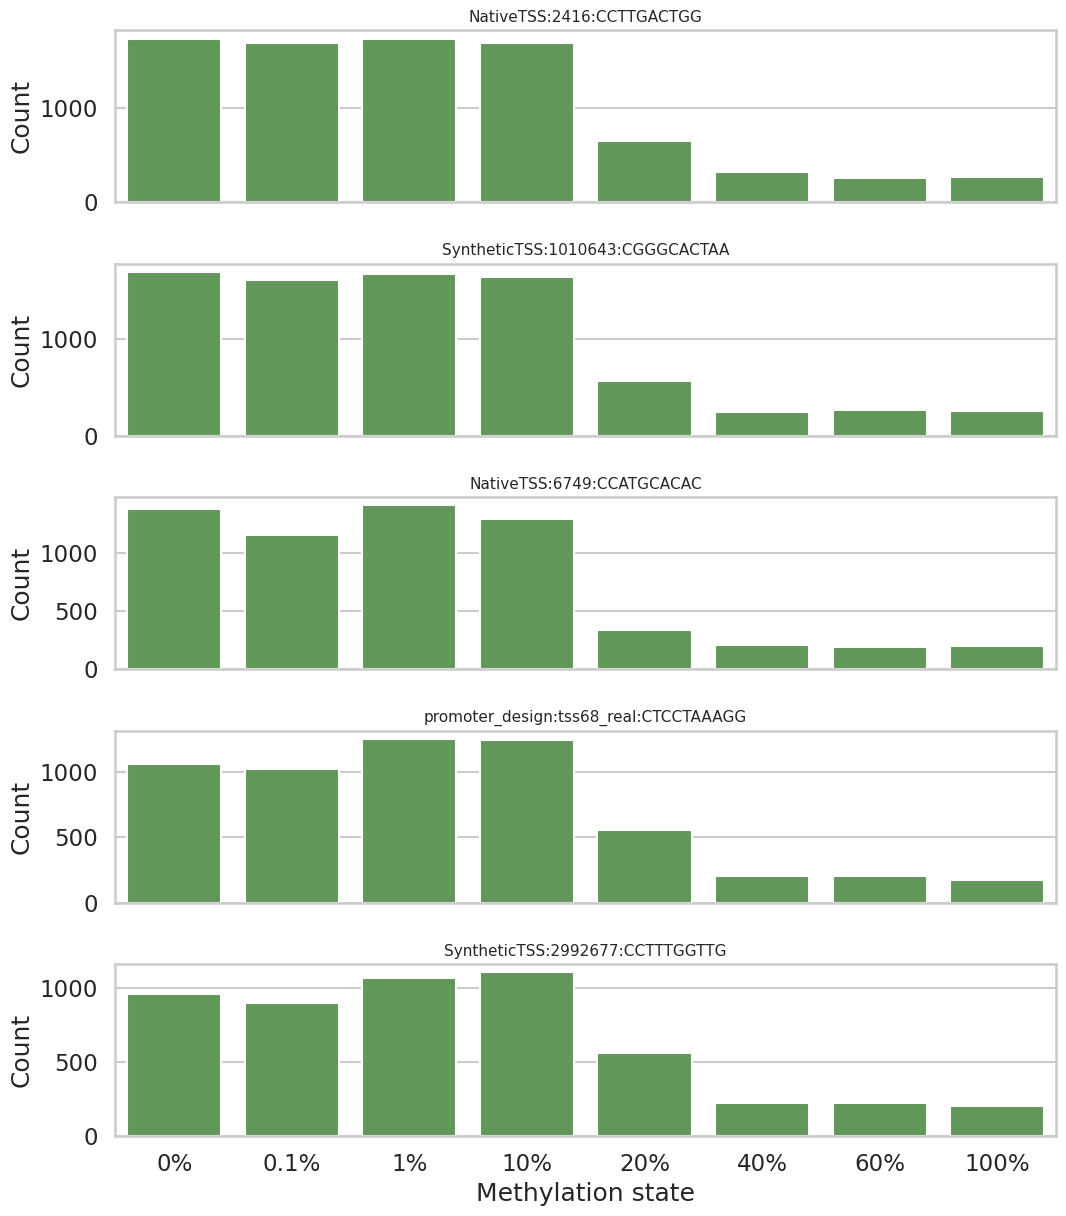

In [13]:
fig, axes = plt.subplots(len(selected_oligos), 1, figsize=(11, 2.5 * len(selected_oligos)), sharex=True)
if len(selected_oligos) == 1:
    axes = [axes]

for ax, oligo in zip(axes, selected_oligos):
    sub = counts[counts["oligo_id"] == oligo]
    sns.barplot(data=sub, x="meth_state", y="Count", order=meth_order, ax=ax, color="#59A14F")
    ax.set_title(oligo, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
plt.xlabel("Methylation state")
plt.tight_layout()

,meth_state,Count
0,0%,6808
1,0.1%,6357
2,1%,7118
3,10%,6962
5,20%,2664
6,40%,1191
7,60%,1134
4,100%,1103


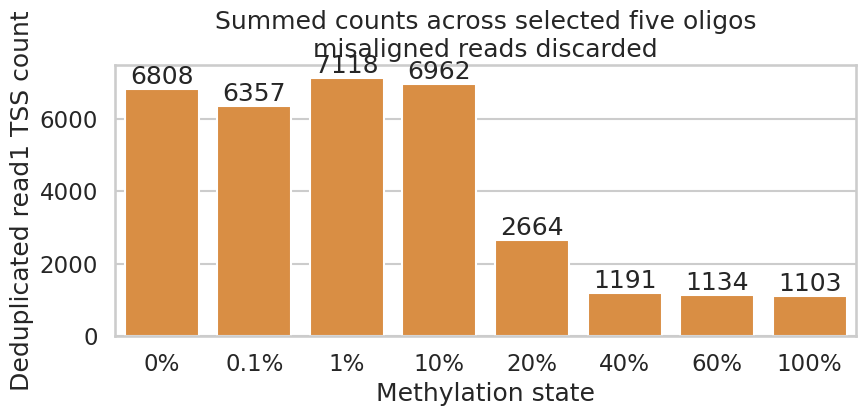

In [14]:
summed_counts = counts.groupby("meth_state", as_index=False)["Count"].sum()
summed_counts["meth_state"] = pd.Categorical(summed_counts["meth_state"], categories=meth_order, ordered=True)
summed_counts = summed_counts.sort_values("meth_state")

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=summed_counts, x="meth_state", y="Count", order=meth_order, ax=ax, color="#F28E2B")
ax.set_title("Summed counts across selected five oligos\nmisaligned reads discarded")
ax.set_xlabel("Methylation state")
ax.set_ylabel("Deduplicated read1 TSS count")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.tight_layout()
display(summed_counts)

## Optional: Save Aligned-Only TSS Counts

This writes a filtered table with the same main columns as the pipeline final output, but after removing barcode/alignment disagreements.

In [8]:
SAVE_FILTERED_COUNTS = True

filtered_tss_counts = (
    aligned_only.groupby(["oligo_id", "meth_state", "aligned_chrom", "tss_position"])
    .size()
    .rename("Count")
    .reset_index()
    .rename(columns={
        "oligo_id": "Oligo_ID",
        "meth_state": "Meth_State",
        "aligned_chrom": "Chromosome",
        "tss_position": "TSS_Position",
    })
)

display(filtered_tss_counts.head())

if SAVE_FILTERED_COUNTS:
    out_path = RESULT_DIR / f"{SAMPLE}.tss_by_oligo_meth.aligned_only.tsv"
    filtered_tss_counts.to_csv(out_path, sep="\t", index=False)
    print(out_path)

,Oligo_ID,Meth_State,Chromosome,TSS_Position,Count
0,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0%,seq413,172,2
1,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0%,seq413,207,1
2,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0%,seq413,214,1
3,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0.1%,seq413,115,1
4,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0.1%,seq413,117,2


/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_500_oligos_S2/STAP_TSS_500_oligos_S2.tss_by_oligo_meth.aligned_only.tsv


### Read original TSS table

In [42]:
filtered_tss_counts = pd.read_csv(RESULT_DIR / f"{SAMPLE}.tss_by_oligo_meth.aligned_only.tsv", sep='\t')
filtered_tss_counts_agg = filtered_tss_counts.groupby(["Oligo_ID", "Meth_State"], as_index=False)['Count'].agg('sum')
filtered_tss_counts_agg.head()

,Oligo_ID,Meth_State,Count
0,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0%,4
1,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0.1%,8
2,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,1%,4
3,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,10%,7
4,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,100%,1


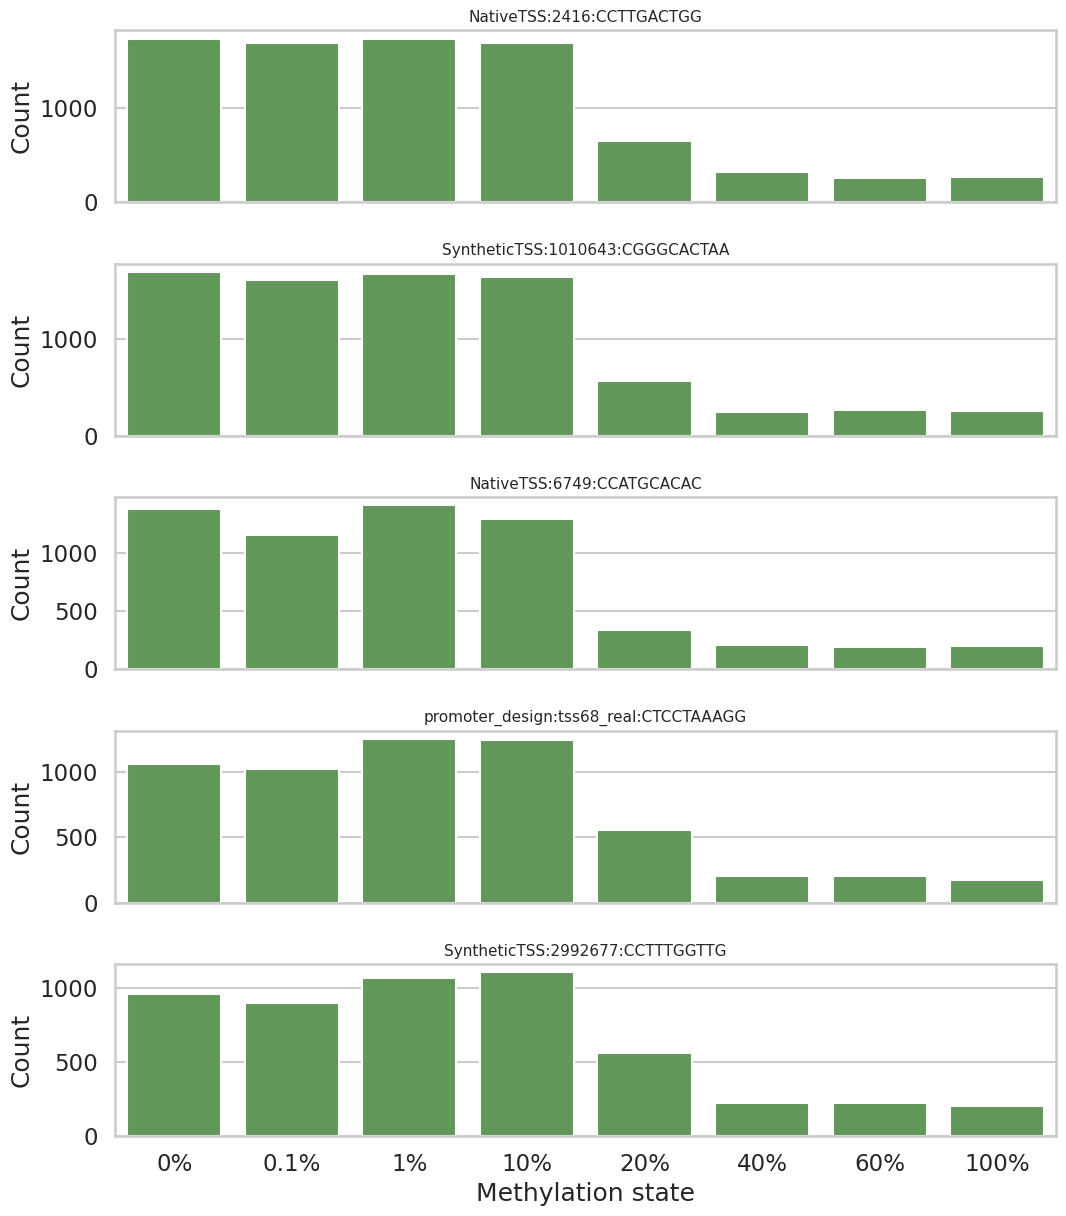

In [10]:
fig, axes = plt.subplots(len(selected_oligos), 1, figsize=(11, 2.5 * len(selected_oligos)), sharex=True)
if len(selected_oligos) == 1:
    axes = [axes]

for ax, oligo in zip(axes, selected_oligos):
    sub = filtered_tss_counts_agg[filtered_tss_counts_agg["Oligo_ID"] == oligo]
    sns.barplot(data=sub, x="Meth_State", y="Count", order=meth_order, ax=ax, color="#59A14F")
    ax.set_title(oligo, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
plt.xlabel("Methylation state")
plt.tight_layout()

# Statistical test in motif deletion

In [ ]:
filtered_tss_counts_agg.loc[filtered_tss_counts_agg['Oligo_ID'].str.contains("NativeTSS:2355")]

,Oligo_ID,Meth_State,Count
447,NativeTSS:2355:ACGCGGATTG,0%,5
448,NativeTSS:2355:ACGCGGATTG,0.1%,4
449,NativeTSS:2355:ACGCGGATTG,1%,8
450,NativeTSS:2355:ACGCGGATTG,10%,2
451,NativeTSS:2355:ACGCGGATTG,60%,2
452,NativeTSS:2355:GCCCATGCAG,0%,149
453,NativeTSS:2355:GCCCATGCAG,0.1%,132
454,NativeTSS:2355:GCCCATGCAG,1%,143
455,NativeTSS:2355:GCCCATGCAG,10%,166
456,NativeTSS:2355:GCCCATGCAG,100%,14


In [16]:
filtered_tss_counts_agg.loc[filtered_tss_counts_agg['Oligo_ID'].str.contains("NativeTSS:1013")]

,Oligo_ID,Meth_State,Count
229,NativeTSS:1013:CGCACACTGG,0%,783
230,NativeTSS:1013:CGCACACTGG,0.1%,751
231,NativeTSS:1013:CGCACACTGG,1%,782
232,NativeTSS:1013:CGCACACTGG,10%,737
233,NativeTSS:1013:CGCACACTGG,100%,120
234,NativeTSS:1013:CGCACACTGG,20%,240
235,NativeTSS:1013:CGCACACTGG,40%,72
236,NativeTSS:1013:CGCACACTGG,60%,114
237,NativeTSS:1013:TAGCTCTGTG,0%,57
238,NativeTSS:1013:TAGCTCTGTG,0.1%,47


In [26]:
native_tss_counts = filtered_tss_counts_agg.loc[filtered_tss_counts_agg['Oligo_ID'].str.contains("NativeTSS")]
native_tss_counts = pd.merge(native_tss_counts, oligo_meta[['oligo_id','del motif']].rename(columns={'oligo_id':'Oligo_ID'}), how='left')
native_tss_counts.head()

,Oligo_ID,Meth_State,Count,del motif
0,NativeTSS:1013:CGCACACTGG,0%,783,ZNF143+
1,NativeTSS:1013:CGCACACTGG,0.1%,751,ZNF143+
2,NativeTSS:1013:CGCACACTGG,1%,782,ZNF143+
3,NativeTSS:1013:CGCACACTGG,10%,737,ZNF143+
4,NativeTSS:1013:CGCACACTGG,100%,120,ZNF143+


In [ ]:
native_tss_counts_znf143 = native_tss_counts.loc[native_tss_counts['del motif'].str.contains("ZNF143+")]
native_tss_counts_znf143.head()

,Oligo_ID,Meth_State,Count,del motif
0,NativeTSS:1013:CGCACACTGG,0%,783,ZNF143+
1,NativeTSS:1013:CGCACACTGG,0.1%,751,ZNF143+
2,NativeTSS:1013:CGCACACTGG,1%,782,ZNF143+
3,NativeTSS:1013:CGCACACTGG,10%,737,ZNF143+
4,NativeTSS:1013:CGCACACTGG,100%,120,ZNF143+


In [30]:
native_tss_counts_znf143.to_csv("tss_znf143.tsv", sep='\t', index=False)

In [59]:
import statsmodels.formula.api as smf

df = native_tss_counts.loc[native_tss_counts['del motif'].str.contains("NRF\+")]

# 2. Data Preprocessing
print("--- Preprocessing Data ---")

# Convert Meth_State from strings like '10%' to floats like 0.10
df['Meth_Float'] = df['Meth_State'].str.rstrip('%').astype(float) / 100.0

# Extract the Promoter ID (e.g., '1013' from 'NativeTSS:1013:CGCACACTGG')
df['Promoter'] = df['Oligo_ID'].apply(lambda x: x.split(':')[1])

# Create a clean binary column for Motif Status (WT vs Del)
df['Motif_Status'] = df['del motif'].apply(lambda x: 'Deleted' if 'del' in x else 'WT')

print(df[['Promoter', 'Meth_Float', 'Motif_Status', 'Count']].head())
print("\n")

# 3. Fit the Negative Binomial Model
print("--- Fitting Negative Binomial GLM ---")

# Formula: Count depends on Methylation, Motif Status, their interaction, and the Promoter background
# The '*' operator automatically includes main effects and the interaction term
formula = 'Count ~ Meth_Float * C(Motif_Status) + C(Promoter)'

# Fit the model
model = smf.negativebinomial(formula, data=df).fit(disp=0)

# 4. View Results
print("\n--- Model Summary ---")
print(model.summary())

--- Preprocessing Data ---
   Promoter  Meth_Float Motif_Status  Count
64     1613       0.001      Deleted      3
65     1613       0.010      Deleted      5
66     1613       0.100      Deleted      4
67     1613       0.200      Deleted      2
68     1613       0.600      Deleted      1


--- Fitting Negative Binomial GLM ---

--- Model Summary ---
                     NegativeBinomial Regression Results                      
Dep. Variable:                  Count   No. Observations:                   75
Model:               NegativeBinomial   Df Residuals:                       67
Method:                           MLE   Df Model:                            7
Date:                Tue, 02 Jun 2026   Pseudo R-squ.:                  0.2048
Time:                        16:08:07   Log-Likelihood:                -331.67
converged:                       True   LL-Null:                       -417.08
Covariance Type:            nonrobust   LLR p-value:                 1.690e-33
              

In [72]:
%%capture my_output

import re
import statsmodels.formula.api as smf

motif_list = ['ZNF143+', 'ZNF143-', 'SP+', 'SP-', 'ETS+', 'ETS-', 'CREB+', 'CREB-', 'NFY+', 'NFY-', 'NRF+', 'NRF-', 'U1 snRNP+', 'YY1+', 'TATA+', 'Long Inr +']
for motif in motif_list:
    df = native_tss_counts.loc[native_tss_counts['del motif'].str.contains(re.escape(motif))]
    # 2. Data Preprocessing
    print(f"--- Preprocessing {motif} ---")

    # Convert Meth_State from strings like '10%' to floats like 0.10
    df['Meth_Float'] = df['Meth_State'].str.rstrip('%').astype(float) / 100.0

    # Extract the Promoter ID (e.g., '1013' from 'NativeTSS:1013:CGCACACTGG')
    df['Promoter'] = df['Oligo_ID'].apply(lambda x: x.split(':')[1])

    # Create a clean binary column for Motif Status (WT vs Del)
    df['Motif_Status'] = df['del motif'].apply(lambda x: 'Deleted' if 'del' in x else 'WT')

    # Formula: Count depends on Methylation, Motif Status, their interaction, and the Promoter background
    # The '*' operator automatically includes main effects and the interaction term
    formula = 'Count ~ Meth_Float * C(Motif_Status) + C(Promoter)'

    # Fit the model
    model = smf.negativebinomial(formula, data=df).fit(disp=0)

    # 4. View Results
    print("\n--- Model Summary ---")
    print(model.summary())

In [75]:
with open('./intermediate_data/native_tss_del_motif_glm.txt', 'w') as f:
    f.write(my_output.stdout)

## Test the magnitude of methylation repression

In [11]:
filtered_tss_counts_agg

,Oligo_ID,Meth_State,Count
0,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0%,4
1,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0.1%,8
2,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,1%,4
3,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,10%,7
4,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,100%,1
...,...,...,...
3452,promoter_design:tss94_real:CGTGGCGGCC,10%,595
3453,promoter_design:tss94_real:CGTGGCGGCC,100%,95
3454,promoter_design:tss94_real:CGTGGCGGCC,20%,189
3455,promoter_design:tss94_real:CGTGGCGGCC,40%,80


In [9]:

df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio
# Since the column names are strings like '10%' and '40%', you can access them directly.
df_pivoted['10_to_40_ratio'] = df_pivoted['10%'] / df_pivoted['40%']

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
result = df_pivoted.reset_index()[['Oligo_ID', '10%', '40%', '10_to_40_ratio']]

result

Meth_State,Oligo_ID,10%,40%,10_to_40_ratio
0,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,7.0,1.0,7.000000
1,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:GCTGTCCGTC,2.0,1.0,2.000000
2,CRISPer-promoters:11_SYNGR3_chr16_1992523_+:CACGAGAGAT,5.0,3.0,1.666667
3,CRISPer-promoters:11_SYNGR3_chr16_1992523_+:TTCCAACCTC,10.0,1.0,10.000000
4,CRISPer-promoters:12_SOCS1_chr16_11256199_-:ACGGGAGCGG,24.0,4.0,6.000000
...,...,...,...,...
479,promoter_design:tss8_generated_1:TCTACCGCCG,93.0,23.0,4.043478
480,promoter_design:tss8_generated_2:GGCATAATGC,72.0,4.0,18.000000
481,promoter_design:tss8_generated_3:GTACGCGTCG,122.0,26.0,4.692308
482,promoter_design:tss8_real:TCGCAAGGTA,56.0,6.0,9.333333


(array([37., 69., 95., 70., 50., 35., 15., 10.,  4.,  5.,  0.,  3.,  1.,
         2.,  1.,  0.,  0.,  2.,  0.,  1.]),
 array([ 0.66666667,  2.48333333,  4.3       ,  6.11666667,  7.93333333,
         9.75      , 11.56666667, 13.38333333, 15.2       , 17.01666667,
        18.83333333, 20.65      , 22.46666667, 24.28333333, 26.1       ,
        27.91666667, 29.73333333, 31.55      , 33.36666667, 35.18333333,
        37.        ]),
 <BarContainer object of 20 artists>)

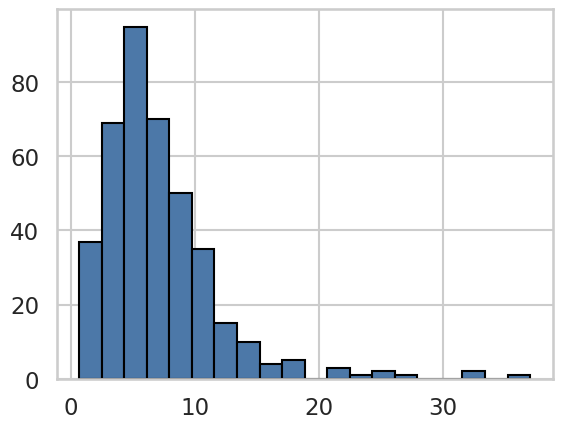

In [13]:
plt.hist(result['10_to_40_ratio'], bins=20, color="#4C78A8", edgecolor="black")

(array([ 1.,  0.,  8.,  3.,  4., 16., 11., 18., 35., 44., 60., 50., 55.,
        47., 19., 13.,  6.,  5.,  2.,  3.]),
 array([-0.5849625 , -0.29524171, -0.00552091,  0.28419988,  0.57392067,
         0.86364147,  1.15336226,  1.44308305,  1.73280385,  2.02252464,
         2.31224543,  2.60196623,  2.89168702,  3.18140781,  3.47112861,
         3.7608494 ,  4.05057019,  4.34029099,  4.63001178,  4.91973257,
         5.20945337]),
 <BarContainer object of 20 artists>)

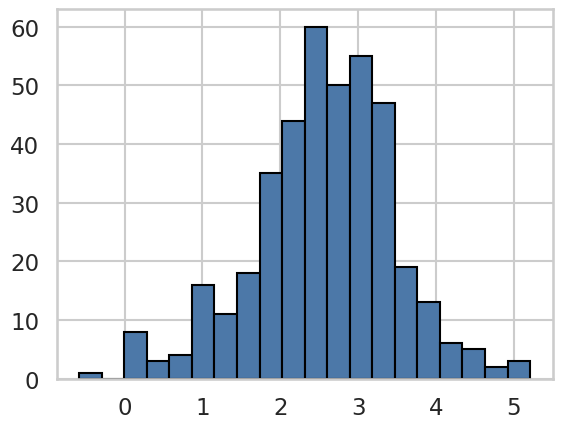

In [14]:
plt.hist(np.log2(result['10_to_40_ratio']), bins=20, color="#4C78A8", edgecolor="black")

In [15]:
np.log2(result['10_to_40_ratio']).mean(), np.log2(result['10_to_40_ratio']).std()

(np.float64(2.5534472526489944), np.float64(0.9145525279672089))

In [17]:
2.55 - 2*0.91, 2.55 + 2*0.91

(0.7299999999999998, 4.37)

In [18]:
lower_mask = np.log2(result['10_to_40_ratio']) < 2.55 - 2*0.91
upper_mask = np.log2(result['10_to_40_ratio']) > 2.55 + 2*0.91

In [23]:
result.loc[lower_mask]

Meth_State,Oligo_ID,10%,40%,10_to_40_ratio
88,NativeTSS:3190:CCACCCTTCA,2.0,2.0,1.000000
108,NativeTSS:3731:GGACCAGTCG,1.0,1.0,1.000000
163,NativeTSS:607:GGGAATCTCT,2.0,2.0,1.000000
206,NativeTSS:8173:GGTGCCCATG,3.0,2.0,1.500000
249,SyntheticTSS:1240943:AGGTTTGGCC,5.0,4.0,1.250000
334,SyntheticTSS:5659854:GGACCACGTT,1.0,1.0,1.000000
373,SyntheticTSS:7871688:GTACGGCTGA,4.0,3.0,1.333333
384,SyntheticTSS:8284794:GTCTCGCCAT,2.0,3.0,0.666667
412,SyntheticTSS:9902180:AAACACGGTG,1.0,1.0,1.000000
423,control:neutral4_WT_BC1:TACCACCAGT,1.0,1.0,1.000000


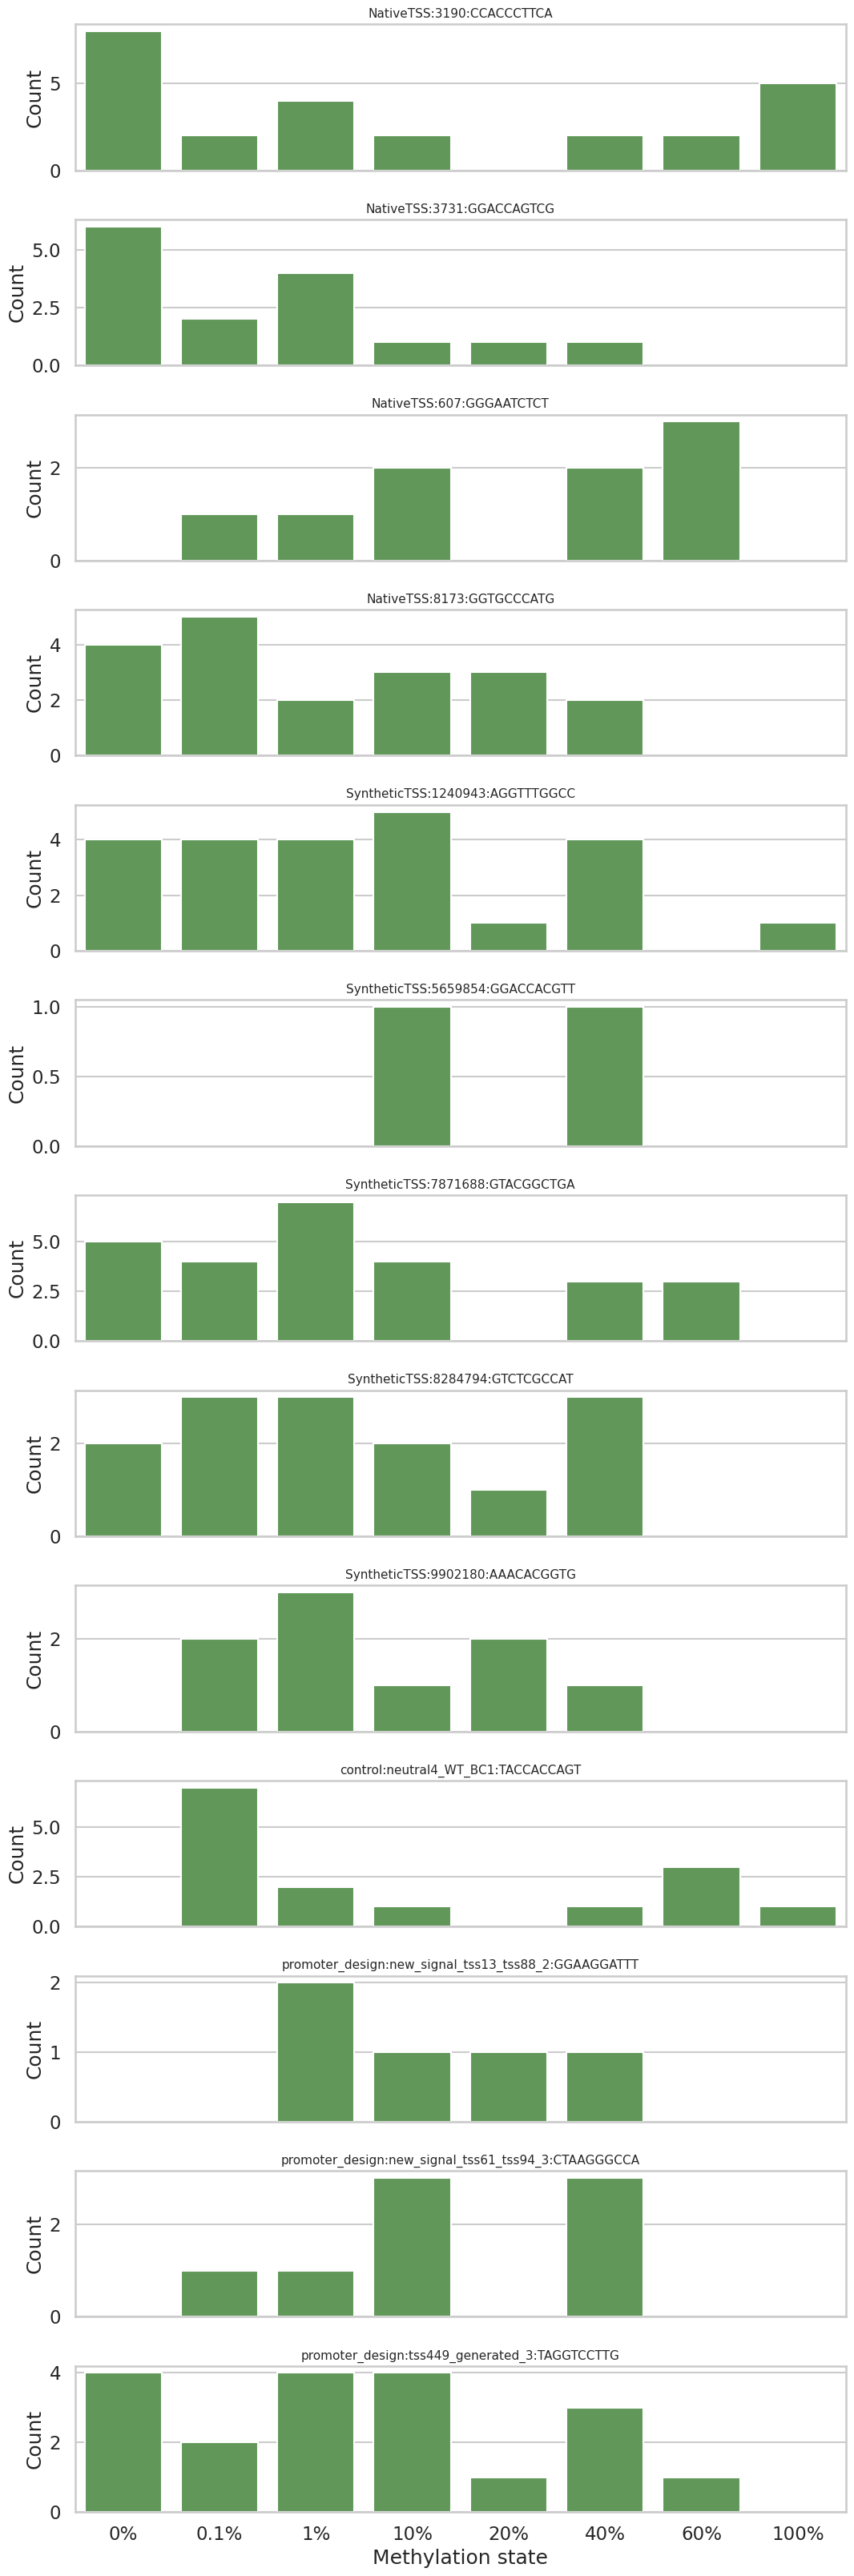

In [21]:
selected_oligos = result.loc[lower_mask, 'Oligo_ID'].tolist()
fig, axes = plt.subplots(len(selected_oligos), 1, figsize=(11, 2.5 * len(selected_oligos)), sharex=True)
if len(selected_oligos) == 1:
    axes = [axes]
meth_order = ["0%", "0.1%", "1%", "10%", "20%", "40%", "60%", "100%"]
for ax, oligo in zip(axes, selected_oligos):
    sub = filtered_tss_counts_agg[filtered_tss_counts_agg["Oligo_ID"] == oligo]
    sns.barplot(data=sub, x="Meth_State", y="Count", order=meth_order, ax=ax, color="#59A14F")
    ax.set_title(oligo, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
plt.xlabel("Methylation state")
plt.tight_layout()

In [24]:
result.loc[upper_mask]

Meth_State,Oligo_ID,10%,40%,10_to_40_ratio
180,NativeTSS:6781:AGGTCGAGAC,80.0,3.0,26.666667
187,NativeTSS:7238:GTTTGGGAGG,33.0,1.0,33.000000
191,NativeTSS:7552:GATCCCACTG,21.0,1.0,21.000000
199,NativeTSS:7922:GTATGCCAGG,32.0,1.0,32.000000
205,NativeTSS:8173:ACCAAGGGAC,22.0,1.0,22.000000
213,NativeTSS:9651:AGAGTCAGGT,37.0,1.0,37.000000
232,Synth-del:4003609:CTCAATGCCG,74.0,3.0,24.666667
256,SyntheticTSS:1692759:GCAACTACGC,21.0,1.0,21.000000
387,SyntheticTSS:8427961:TCTGTCGATC,25.0,1.0,25.000000
402,SyntheticTSS:9235289:CAGTACGGAG,23.0,1.0,23.000000


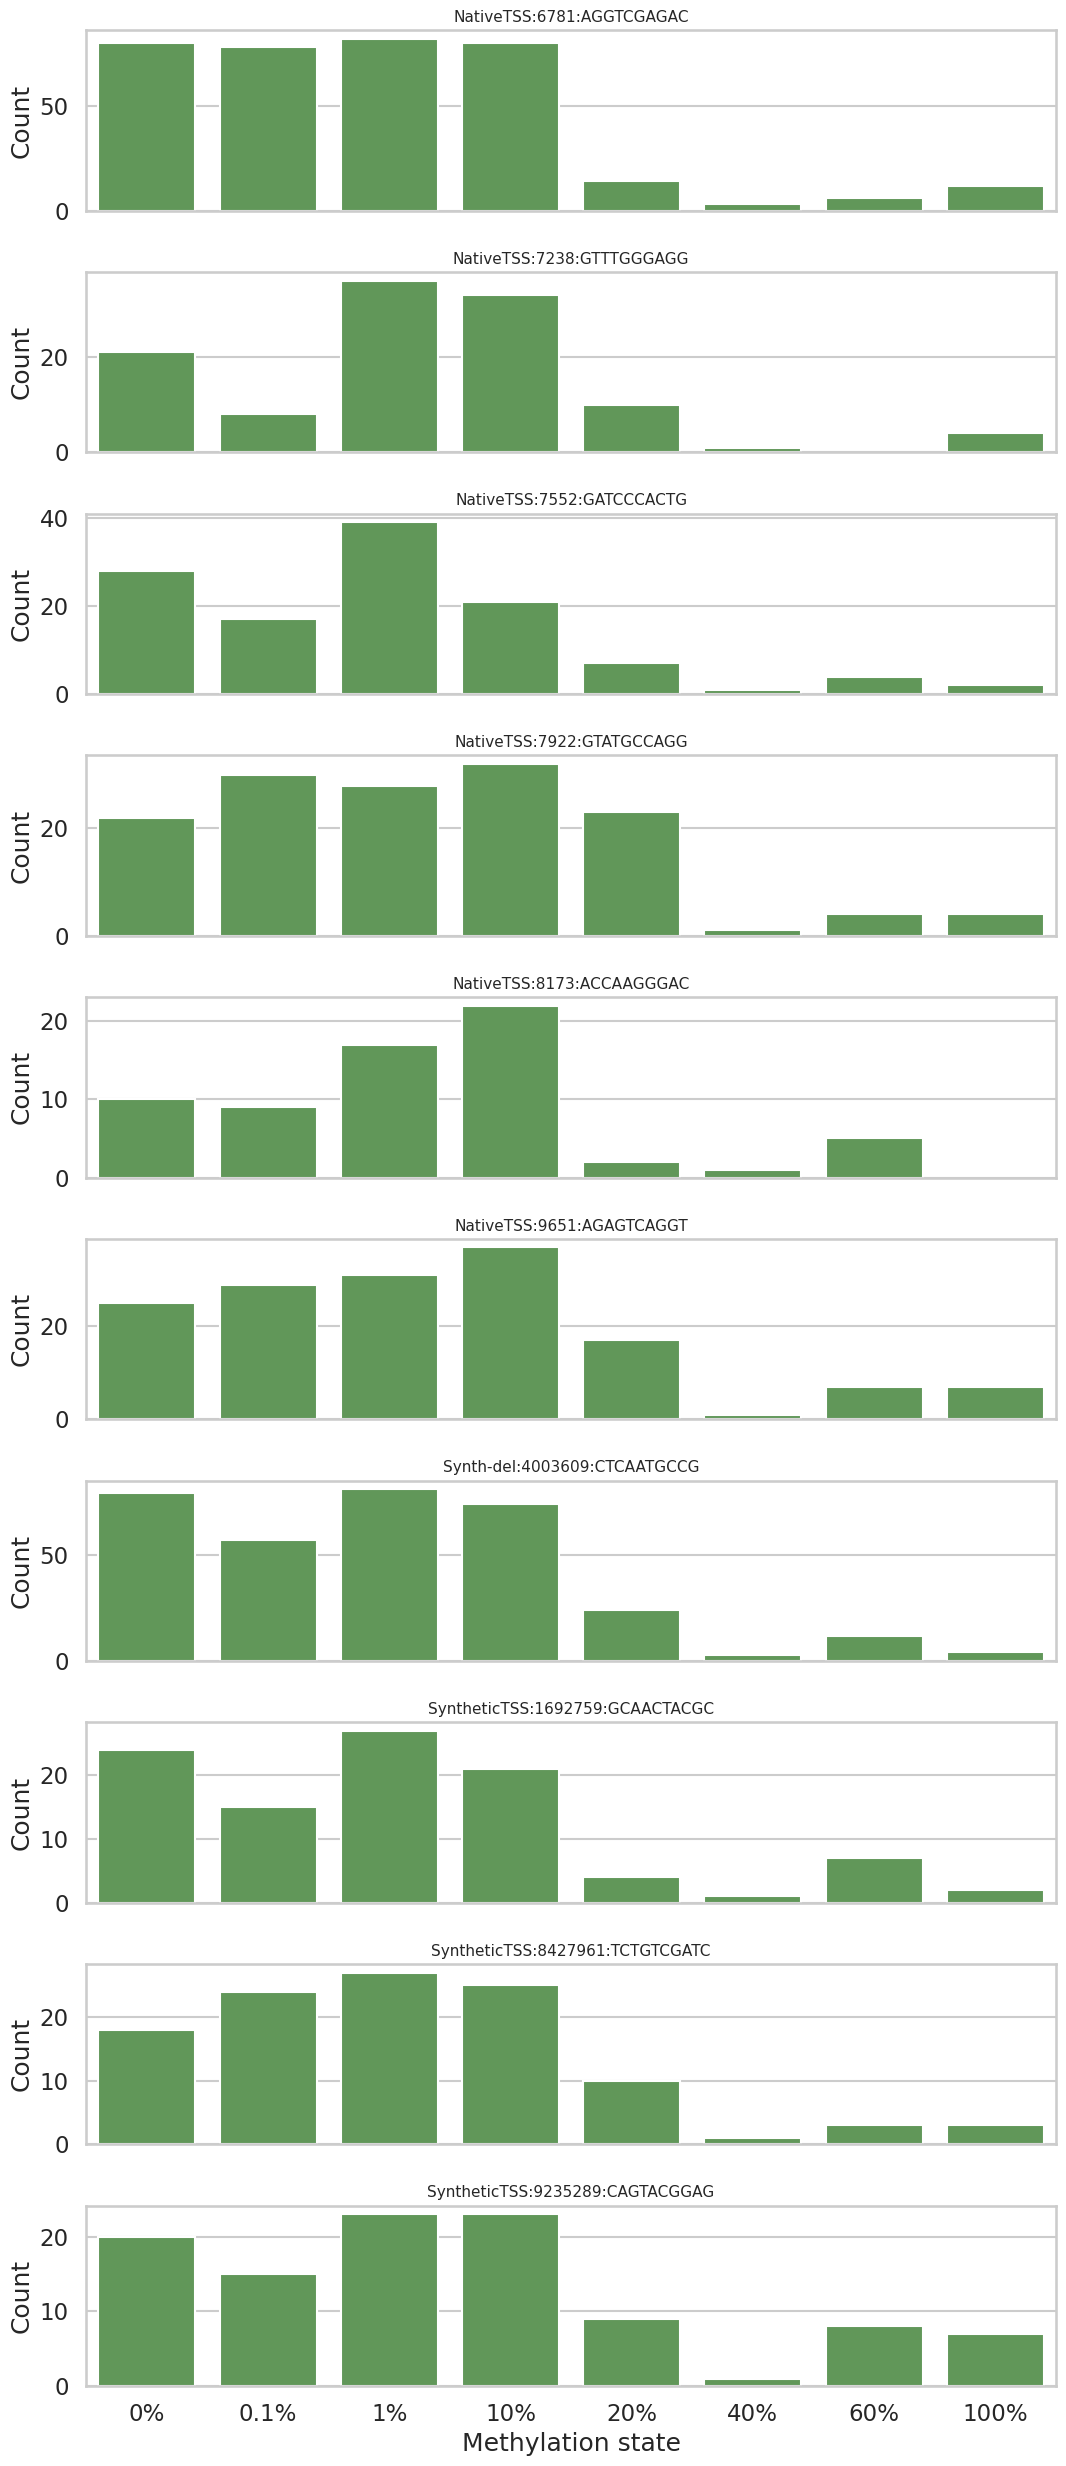

In [25]:
selected_oligos = result.loc[upper_mask, 'Oligo_ID'].tolist()
fig, axes = plt.subplots(len(selected_oligos), 1, figsize=(11, 2.5 * len(selected_oligos)), sharex=True)
if len(selected_oligos) == 1:
    axes = [axes]
meth_order = ["0%", "0.1%", "1%", "10%", "20%", "40%", "60%", "100%"]
for ax, oligo in zip(axes, selected_oligos):
    sub = filtered_tss_counts_agg[filtered_tss_counts_agg["Oligo_ID"] == oligo]
    sns.barplot(data=sub, x="Meth_State", y="Count", order=meth_order, ax=ax, color="#59A14F")
    ax.set_title(oligo, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
plt.xlabel("Methylation state")
plt.tight_layout()

In [10]:
result

Meth_State,Oligo_ID,10%,40%,10_to_40_ratio
0,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,7.0,1.0,7.000000
1,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:GCTGTCCGTC,2.0,1.0,2.000000
2,CRISPer-promoters:11_SYNGR3_chr16_1992523_+:CACGAGAGAT,5.0,3.0,1.666667
3,CRISPer-promoters:11_SYNGR3_chr16_1992523_+:TTCCAACCTC,10.0,1.0,10.000000
4,CRISPer-promoters:12_SOCS1_chr16_11256199_-:ACGGGAGCGG,24.0,4.0,6.000000
...,...,...,...,...
479,promoter_design:tss8_generated_1:TCTACCGCCG,93.0,23.0,4.043478
480,promoter_design:tss8_generated_2:GGCATAATGC,72.0,4.0,18.000000
481,promoter_design:tss8_generated_3:GTACGCGTCG,122.0,26.0,4.692308
482,promoter_design:tss8_real:TCGCAAGGTA,56.0,6.0,9.333333


# DESeq

In [5]:
filtered_tss_counts = pd.read_csv(RESULT_DIR / f"{SAMPLE}.tss_by_oligo_meth.aligned_only.tsv", sep='\t')
filtered_tss_counts_agg = filtered_tss_counts.groupby(["Oligo_ID", "Meth_State"], as_index=False)['Count'].agg('sum')
filtered_tss_counts_agg.head()

,Oligo_ID,Meth_State,Count
0,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0%,4
1,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0.1%,8
2,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,1%,4
3,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,10%,7
4,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,100%,1


In [6]:
counts_df = filtered_tss_counts_agg.pivot(index='Meth_State', columns='Oligo_ID', values='Count')

# It is highly likely that some oligos will have 0 counts in certain states, 
# resulting in NaN values after pivoting. DESeq2 requires integers, so we fill NaNs with 0.
counts_df = counts_df.fillna(0).astype(int)

counts_df.head()

Oligo_ID,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:GCTGTCCGTC,CRISPer-promoters:11_SYNGR3_chr16_1992523_+:CACGAGAGAT,CRISPer-promoters:11_SYNGR3_chr16_1992523_+:TTCCAACCTC,CRISPer-promoters:12_SOCS1_chr16_11256199_-:ACGGGAGCGG,CRISPer-promoters:12_SOCS1_chr16_11256199_-:CGAGCGATTA,CRISPer-promoters:13_C19orf43_chr19_12734681_-:GATAACCTAC,CRISPer-promoters:13_C19orf43_chr19_12734681_-:GGCATCTGAC,CRISPer-promoters:14_ICAM1_chr19_10271119_+:AGTCTTGGCG,CRISPer-promoters:14_ICAM1_chr19_10271119_+:CGAATCTTAA,CRISPer-promoters:15_ECI1_chr16_2251586_-:AACTCAAGCC,CRISPer-promoters:15_ECI1_chr16_2251586_-:TAACCTCGAG,CRISPer-promoters:16_LETMD1_chr12_51048326_+:GAGTCAGGGA,CRISPer-promoters:16_LETMD1_chr12_51048326_+:TCCCACATGC,CRISPer-promoters:1_HIST1H1D_chr6_26234986-:ACCCTTTGAG,CRISPer-promoters:1_HIST1H1D_chr6_26234986-:CATAGGGTGA,CRISPer-promoters:2_C1orf63_chr1_25247453_-:TGACGAGTGT,CRISPer-promoters:2_C1orf63_chr1_25247453_-:TTGCAGAGCA,CRISPer-promoters:3_EDEM2_chr20_35278121_-:CGTACTGAAT,CRISPer-promoters:3_EDEM2_chr20_35278121_-:TTCAGGGCCT,CRISPer-promoters:4_RBM4_chr11_66616629_+:CCACTGAAGC,CRISPer-promoters:4_RBM4_chr11_66616629_+:GTCGATTACC,CRISPer-promoters:5_IRF1_chr5_132490772_-:ACGGAGCTGA,CRISPer-promoters:5_IRF1_chr5_132490772_-:GAACGCCAAC,CRISPer-promoters:6_TMED9_chr5_177592202_+:GACTGCACTT,CRISPer-promoters:6_TMED9_chr5_177592202_+:TCTTGCTCAC,CRISPer-promoters:7_NDUFV3_chr21_42893312_+:CATGCACCTT,CRISPer-promoters:7_NDUFV3_chr21_42893312_+:CCATTACTCG,CRISPer-promoters:8_HSF1_chr8_144291604_+:CCTATCACGC,CRISPer-promoters:8_HSF1_chr8_144291604_+:CGCTGGAAGT,CRISPer-promoters:9_SMCHD1_chr18_2655725_+:AGCGCTAAGG,CRISPer-promoters:9_SMCHD1_chr18_2655725_+:CCGCGCTTGA,NativeTSS:1013:CGCACACTGG,NativeTSS:1013:TAGCTCTGTG,NativeTSS:1289:GCTTGGACAG,NativeTSS:1289:GTGTTCACTT,NativeTSS:1345:GATAGCCTCG,NativeTSS:1345:GCTACGCACC,NativeTSS:1477:GGGCGAGTAA,NativeTSS:1477:GTTGTGTCCT,...,promoter_design:tss0_generated_3:CTGAATTCCA,promoter_design:tss0_real:ATAGGGCGAG,promoter_design:tss1003_real:CTGACCGTGT,promoter_design:tss13_real:GACGCGAGTC,promoter_design:tss25_real:TCGGTACGGA,promoter_design:tss298_generated_1:AAGGCAACTG,promoter_design:tss298_generated_2:TGTTTGCGCC,promoter_design:tss298_generated_3:CGGTAGCGAA,promoter_design:tss298_real:AGGGTAACAC,promoter_design:tss3_generated_1:CGTTACCATC,promoter_design:tss3_generated_2:GTGGTGTAAT,promoter_design:tss3_generated_3:TGTGTCGGTA,promoter_design:tss3_real:GAACACTCTC,promoter_design:tss449_generated_1:CGTCCCTCTA,promoter_design:tss449_generated_2:CCCTATGGTA,promoter_design:tss449_generated_3:TAGGTCCTTG,promoter_design:tss449_real:TACATGCGTC,promoter_design:tss4_real:ACTACGCTTG,promoter_design:tss53_generated_1:CGGAGAATGT,promoter_design:tss53_generated_2:TCGACGCGTT,promoter_design:tss53_generated_3:TGGTAGCCGG,promoter_design:tss61_real:TTCTCGACTC,promoter_design:tss68_real:CTCCTAAAGG,promoter_design:tss79_real:ACGAGGCATC,promoter_design:tss80_real:ATTCGATCCG,promoter_design:tss82_generated_1:GTATATGCCG,promoter_design:tss82_generated_2:CGCATCGGTT,promoter_design:tss82_generated_3:CGCAAGACAC,promoter_design:tss82_real:CGCAGGATAG,promoter_design:tss88_generated_1:TGAGCCGCAA,promoter_design:tss88_generated_2:GGAGAGGAGA,promoter_design:tss88_generated_3:CGAGGGTGAC,promoter_design:tss88_real:AAACCAAGCG,promoter_design:tss88_real:ACGATGCAGA,promoter_design:tss88_real:GATGGTCGTC,promoter_design:tss8_generated_1:TCTACCGCCG,promoter_design:tss8_generated_2:GGCATAATGC,promoter_design:tss8_generated_3:GTACGCGTCG,promoter_design:tss8_real:TCGCAAGGTA,promoter_design:tss94_real:CGTGGCGGCC
Meth_State,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0%,4,5,6,11,10,11,11,21,1,3,32,10,107,163,0,0,14,53,65,37,76,126,23,10,27,73,61,61,46,15,12,1,783,57,104,44,74,353,52,39,...,22,338,0,22,27,50,45,19,36,50,28,80,39,5,8,4,13,191,2,2,0,7,1059,209,5,18,29,9,17,61,64,75,43,103,80,87,47,83,36,493
0.1%,8,3,5,16,13,8,6,10,

In [32]:
# 1. Calculate the maximum count for each oligo (column) across all conditions (rows)
# If the maximum count is >= 10, it means it is NOT < 10 under all conditions.
mask = counts_df.max(axis=0) >= 20

# 2. Apply the mask to keep only the columns (oligos) that pass the threshold
filtered_counts_df = counts_df.loc[:, mask]

In [33]:
test_counts_df = filtered_counts_df.loc[['0%', '0.1%', '60%', '100%']].copy()
# Create metadata matching the index of your new counts_df
metadata_df = pd.DataFrame({
    # You can map the continuous percentages to categorical conditions if needed,
    # or just use the state as the condition itself depending on your contrast goals.
    "Condition": ['unmethylated', 'unmethylated', 'methylated', 'methylated']
}, index=test_counts_df.index)
test_counts_df.head()

Oligo_ID,CRISPer-promoters:12_SOCS1_chr16_11256199_-:ACGGGAGCGG,CRISPer-promoters:13_C19orf43_chr19_12734681_-:GATAACCTAC,CRISPer-promoters:13_C19orf43_chr19_12734681_-:GGCATCTGAC,CRISPer-promoters:15_ECI1_chr16_2251586_-:AACTCAAGCC,CRISPer-promoters:16_LETMD1_chr12_51048326_+:GAGTCAGGGA,CRISPer-promoters:16_LETMD1_chr12_51048326_+:TCCCACATGC,CRISPer-promoters:2_C1orf63_chr1_25247453_-:TGACGAGTGT,CRISPer-promoters:2_C1orf63_chr1_25247453_-:TTGCAGAGCA,CRISPer-promoters:3_EDEM2_chr20_35278121_-:CGTACTGAAT,CRISPer-promoters:3_EDEM2_chr20_35278121_-:TTCAGGGCCT,CRISPer-promoters:4_RBM4_chr11_66616629_+:CCACTGAAGC,CRISPer-promoters:4_RBM4_chr11_66616629_+:GTCGATTACC,CRISPer-promoters:5_IRF1_chr5_132490772_-:ACGGAGCTGA,CRISPer-promoters:6_TMED9_chr5_177592202_+:GACTGCACTT,CRISPer-promoters:6_TMED9_chr5_177592202_+:TCTTGCTCAC,CRISPer-promoters:7_NDUFV3_chr21_42893312_+:CATGCACCTT,CRISPer-promoters:7_NDUFV3_chr21_42893312_+:CCATTACTCG,CRISPer-promoters:8_HSF1_chr8_144291604_+:CCTATCACGC,CRISPer-promoters:8_HSF1_chr8_144291604_+:CGCTGGAAGT,NativeTSS:1013:CGCACACTGG,NativeTSS:1013:TAGCTCTGTG,NativeTSS:1289:GCTTGGACAG,NativeTSS:1289:GTGTTCACTT,NativeTSS:1345:GATAGCCTCG,NativeTSS:1345:GCTACGCACC,NativeTSS:1477:GGGCGAGTAA,NativeTSS:1477:GTTGTGTCCT,NativeTSS:1613:TCGGGCGAGA,NativeTSS:1652:TTCAGTTGCT,NativeTSS:1690:ACTCCCGTGC,NativeTSS:1690:TCTCTACTCT,NativeTSS:1715:CTCCGCAAAG,NativeTSS:1715:GGCAGAGTGG,NativeTSS:1874:CACTTCAGCG,NativeTSS:1874:GTGTCTCTTT,NativeTSS:1914:ACCCTCACAA,NativeTSS:1914:CTCAATCCTC,NativeTSS:1949:CTGCTACGCA,NativeTSS:1949:TACCACTTAG,NativeTSS:2031:GTTCGGAGGC,...,promoter_design:HSPA_generated2:CGTCTAAACT,promoter_design:HSPA_real:GGAGCGAGCA,promoter_design:new_signal_tss13_tss88_1:AGAACCCTCA,promoter_design:new_signal_tss4_tss25_2:TTAGCGACAG,promoter_design:new_signal_tss4_tss25_3:ATCTGCTCCT,promoter_design:new_signal_tss68_tss79_1:TAGGAACTGT,promoter_design:new_signal_tss68_tss79_2:TGACACTCGT,promoter_design:new_signal_tss68_tss79_3:AGCAGCCTGA,promoter_design:new_signal_tss80_tss88_3:CGCTATGGCG,promoter_design:tss0_generated_2:AGTCTCAGCT,promoter_design:tss0_generated_3:CTGAATTCCA,promoter_design:tss0_real:ATAGGGCGAG,promoter_design:tss13_real:GACGCGAGTC,promoter_design:tss25_real:TCGGTACGGA,promoter_design:tss298_generated_1:AAGGCAACTG,promoter_design:tss298_generated_2:TGTTTGCGCC,promoter_design:tss298_generated_3:CGGTAGCGAA,promoter_design:tss298_real:AGGGTAACAC,promoter_design:tss3_generated_1:CGTTACCATC,promoter_design:tss3_generated_2:GTGGTGTAAT,promoter_design:tss3_generated_3:TGTGTCGGTA,promoter_design:tss3_real:GAACACTCTC,promoter_design:tss4_real:ACTACGCTTG,promoter_design:tss68_real:CTCCTAAAGG,promoter_design:tss79_real:ACGAGGCATC,promoter_design:tss80_real:ATTCGATCCG,promoter_design:tss82_generated_1:GTATATGCCG,promoter_design:tss82_generated_2:CGCATCGGTT,promoter_design:tss82_real:CGCAGGATAG,promoter_design:tss88_generated_1:TGAGCCGCAA,promoter_design:tss88_generated_2:GGAGAGGAGA,promoter_design:tss88_generated_3:CGAGGGTGAC,promoter_design:tss88_real:AAACCAAGCG,promoter_design:tss88_real:ACGATGCAGA,promoter_design:tss88_real:GATGGTCGTC,promoter_design:tss8_generated_1:TCTACCGCCG,promoter_design:tss8_generated_2:GGCATAATGC,promoter_design:tss8_generated_3:GTACGCGTCG,promoter_design:tss8_real:TCGCAAGGTA,promoter_design:tss94_real:CGTGGCGGCC
Meth_State,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0%,10,11,21,32,107,163,14,53,65,37,76,126,23,27,73,61,61,46,15,783,57,104,44,74,353,52,39,255,104,21,70,24,94,120,243,244,667,246,31,40,...,48,21,37,17,32,458,251,452,25,46,22,338,22,27,50,45,19,36,50,28,80,39,191,1059,209,5,18,29,17,61,64,75,43,103,80,87,47,83,36,493
0.1%,13,6,10,38,80,124,31,38,51,34,79,138,18,39,73,52,72,40,12,751,47,109,42,56,366,44,38,285,91,20,100,30,88,99,206,268,589,226,48,59,...,28,28,25,12,31,388,210,443,15,44,29,284,32,43,33,45,36,34,53,39,68,51,186,1022,263,3,17,16,15,58,58,82,34,94,85,67,55,101,44,420
60%,4,3,3,6,14,26,3,5,6,14,20,20,6,4,12,5,13,3,1,11

In [35]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import glm
from statsmodels.stats.multitest import multipletests

# 1. Prepare an empty list to store our results
results = []

# Ensure metadata index matches count data index
metadata_df = pd.DataFrame({
    "Condition": ['unmethylated', 'unmethylated', 'methylated', 'methylated']
}, index=test_counts_df.index)

# 2. Set up the Negative Binomial family
# We use a small, fixed dispersion parameter (alpha) since N=2 is too small 
# to reliably estimate dispersion on a per-gene basis.
nb_family = sm.families.NegativeBinomial(alpha=0.1)

print("Fitting GLMs for all oligos...")

# 3. Loop through every oligo (column) and fit an independent GLM
for oligo in test_counts_df.columns:
    
    # Create a simple DataFrame for this specific oligo
    temp_df = pd.DataFrame({
        'Count': test_counts_df[oligo],
        'Condition': metadata_df['Condition']
    })
    
    try:
        # Fit the model. 
        # C(Condition, Treatment('unmethylated')) forces 'unmethylated' to be the baseline.
        model = glm("Count ~ C(Condition, Treatment('unmethylated'))", 
                    data=temp_df, 
                    family=nb_family).fit()
        
        # The parameter name generated by statsmodels for the difference
        param_name = "C(Condition, Treatment('unmethylated'))[T.methylated]"
        
        # Extract the coefficient. 
        # GLMs use the natural log (base e). We divide by np.log(2) to get log2FoldChange.
        coef_ln = model.params[param_name]
        lfc_log2 = coef_ln / np.log(2)
        
        # Extract the p-value and standard error
        p_val = model.pvalues[param_name]
        se_ln = model.bse[param_name]
        se_log2 = se_ln / np.log(2)
        
        # Calculate baseMean (just the raw average across all 4 samples)
        base_mean = temp_df['Count'].mean()
        
        results.append({
            'Oligo_ID': oligo,
            'baseMean': base_mean,
            'log2FoldChange': lfc_log2,
            'lfcSE': se_log2,
            'pvalue': p_val
        })
        
    except Exception as e:
        # If a model fails to converge (e.g., all counts are 0), record NaNs
        results.append({
            'Oligo_ID': oligo,
            'baseMean': temp_df['Count'].mean(),
            'log2FoldChange': np.nan,
            'lfcSE': np.nan,
            'pvalue': np.nan
        })

# 4. Convert results to a DataFrame
res_df = pd.DataFrame(results).set_index('Oligo_ID')

# Drop any oligos that failed to converge
res_df = res_df.dropna(subset=['pvalue'])

# 5. Apply Multiple Testing Correction (Benjamini-Hochberg FDR)
_, res_df['padj'], _, _ = multipletests(res_df['pvalue'], method='fdr_bh')

print("\n--- Custom GLM Results ---")
res_df.head()

Fitting GLMs for all oligos...

--- Custom GLM Results ---


,baseMean,log2FoldChange,lfcSE,pvalue,padj
Oligo_ID,,,,,
CRISPer-promoters:12_SOCS1_chr16_11256199_-:ACGGGAGCGG,7.00,-2.201634,0.845521,9.217508e-03,9.625879e-03
CRISPer-promoters:13_C19orf43_chr19_12734681_-:GATAACCTAC,5.75,-1.502500,0.823082,6.793229e-02,6.834651e-02
CRISPer-promoters:13_C19orf43_chr19_12734681_-:GGCATCTGAC,9.25,-2.369234,0.788779,2.667430e-03,2.914741e-03
CRISPer-promoters:15_ECI1_chr16_2251586_-:AACTCAAGCC,20.00,-2.807355,0.667838,2.626486e-05,4.355480e-05
CRISPer-promoters:16_LETMD1_chr12_51048326_+:GAGTCAGGGA,52.75,-2.961932,0.553164,8.578180e-08,3.676363e-07


In [36]:
import scipy.stats as stats

# Calculate precision weights (inverse variance)
weights = 1 / (res_df["lfcSE"] ** 2)

# Calculate the weighted mean effect size across all genes
weighted_mean_lfc = np.sum(weights * res_df["log2FoldChange"]) / np.sum(weights)

# Calculate Cochran's Q
q_stat = np.sum(weights * (res_df["log2FoldChange"] - weighted_mean_lfc) ** 2)

# Calculate global p-value (Degrees of freedom = number of genes - 1)
df_q = len(res_df) - 1
q_p_value = stats.chi2.sf(q_stat, df_q)

print(f"Global Heterogeneity P-value: {q_p_value:.4e}")

Global Heterogeneity P-value: 9.8621e-01


(array([ 2.,  0.,  0.,  5.,  4., 10., 13., 28., 25., 48., 46., 37., 36.,
        31., 18.,  6.,  7.,  4.,  8.,  2.]),
 array([-4.46876948, -4.29665462, -4.12453976, -3.95242489, -3.78031003,
        -3.60819517, -3.4360803 , -3.26396544, -3.09185057, -2.91973571,
        -2.74762085, -2.57550598, -2.40339112, -2.23127626, -2.05916139,
        -1.88704653, -1.71493167, -1.5428168 , -1.37070194, -1.19858707,
        -1.02647221]),
 <BarContainer object of 20 artists>)

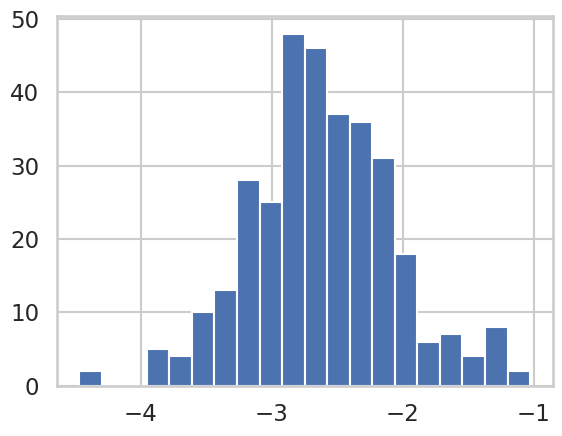

In [37]:
plt.hist(res_df['log2FoldChange'], bins=20)

In [38]:
from scipy import stats

# 1. Filter the dataframe to ensure we only use oligos with valid math
# (Drops any rows where standard error is missing or exactly 0 to prevent division by zero)
valid_res = res_df.dropna(subset=['log2FoldChange', 'lfcSE']).copy()
valid_res = valid_res[valid_res['lfcSE'] > 0]

# 2. Extract arrays for cleaner math
lfc = valid_res['log2FoldChange'].values
se = valid_res['lfcSE'].values

# 3. Calculate Inverse Variance Weights
weights = 1.0 / (se ** 2)

# 4. Calculate the Weighted Mean Log2 Fold Change
weighted_mean_lfc = np.sum(weights * lfc) / np.sum(weights)

# 5. Calculate Cochran's Q Statistic
q_stat = np.sum(weights * ((lfc - weighted_mean_lfc) ** 2))

# 6. Calculate the Global P-Value using the Chi-Square survival function
df_q = len(valid_res) - 1
global_p_value = stats.chi2.sf(q_stat, df_q)

# --- Print Results ---
print("--- Global Heterogeneity Test ---")
print(f"Number of valid oligos tested: {len(valid_res)}")
print(f"Weighted Mean LFC: {weighted_mean_lfc:.4f}")
print(f"Cochran's Q Statistic: {q_stat:.4f}")
print(f"Global P-Value: {global_p_value:.4e}")

if global_p_value < 0.05:
    print("\nConclusion: SIGNIFICANT heterogeneity.")
    print("Different oligos show genuinely different biological responses between the unmethylated and methylated states.")
else:
    print("\nConclusion: NO significant heterogeneity.")
    print("The variance in fold changes is indistinguishable from random noise. The treatment effect is uniform across oligos.")

--- Global Heterogeneity Test ---
Number of valid oligos tested: 330
Weighted Mean LFC: -2.5678
Cochran's Q Statistic: 275.0744
Global P-Value: 9.8621e-01

Conclusion: NO significant heterogeneity.
The variance in fold changes is indistinguishable from random noise. The treatment effect is uniform across oligos.


# Test the predictive power of the count of CpG

In [83]:
tss_counts = pd.read_csv(RESULT_DIR / f"{SAMPLE}.tss_by_oligo_meth.aligned_only.tsv", sep='\t')
tss_counts_agg = tss_counts.groupby(["Oligo_ID", "Meth_State"], as_index=False)['Count'].agg('sum')
ref_cpg_count = pd.read_csv("/gpfs/data/zhou-lab/yczhang/methylation/data/meta/data_500_cpg_counts.tsv", sep="\t")

oligo_cpg = []
for oligo in tss_counts_agg['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    cpg_count = ref_cpg_count.loc[ref_cpg_count['sequence_id'] == sequence_id, 'cpg_count'].values
    oligo_cpg.append(cpg_count[0].item())
tss_counts_agg['CpG_Count'] = oligo_cpg

In [84]:
## filter oligos with fewer than 20 counts under all conditions
tss_counts_agg = tss_counts_agg.merge(tss_counts_agg.groupby(by='Oligo_ID', as_index=False)['Count'].agg({'Max_Count':'max'}), how='left', on='Oligo_ID')
filtered_tss_counts_agg = tss_counts_agg.query("Max_Count >= 20").copy()

/home/yuchenz2/mytmp/ipykernel_4049530/204608278.py:2: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  tss_counts_agg = tss_counts_agg.merge(tss_counts_agg.groupby(by='Oligo_ID', as_index=False)['Count'].agg({'Max_Count':'max'}), how='left', on='Oligo_ID')


In [85]:
pd.unique(filtered_tss_counts_agg['Oligo_ID']).shape

(330,)

## Quantify the relationship between CpG count and methylation repression magnitude

In [117]:
df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

oligo_cpg = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    cpg_count = ref_cpg_count.loc[ref_cpg_count['sequence_id'] == sequence_id, 'cpg_count'].values
    oligo_cpg.append(cpg_count[0].item())
tss_meth_repression_magnitude['CpG_Count'] = oligo_cpg
tss_meth_repression_magnitude.dropna(inplace=True)

In [118]:
tss_meth_repression_magnitude

Meth_State,Oligo_ID,0%,0.1%,60%,100%,low_to_high_ratio,CpG_Count
0,CRISPer-promoters:12_SOCS1_chr16_11256199_-:ACGGGAGCGG,10.0,13.0,4.0,1.0,4.600000,36
1,CRISPer-promoters:13_C19orf43_chr19_12734681_-:GATAACCTAC,11.0,6.0,3.0,3.0,2.833333,35
2,CRISPer-promoters:13_C19orf43_chr19_12734681_-:GGCATCTGAC,21.0,10.0,3.0,3.0,5.166667,33
3,CRISPer-promoters:15_ECI1_chr16_2251586_-:AACTCAAGCC,32.0,38.0,6.0,4.0,7.000000,30
4,CRISPer-promoters:16_LETMD1_chr12_51048326_+:GAGTCAGGGA,107.0,80.0,14.0,10.0,7.791667,16
...,...,...,...,...,...,...,...
325,promoter_design:tss8_generated_1:TCTACCGCCG,87.0,67.0,4.0,17.0,7.333333,21
326,promoter_design:tss8_generated_2:GGCATAATGC,47.0,55.0,6.0,15.0,4.857143,23
327,promoter_design:tss8_generated_3:GTACGCGTCG,83.0,101.0,21.0,9.0,6.133333,25
328,promoter_design:tss8_real:TCGCAAGGTA,36.0,44.0,8.0,8.0,5.000000,23


Text(0.5, 1.0, 'Methylation Repression Magnitude vs CpG Count')

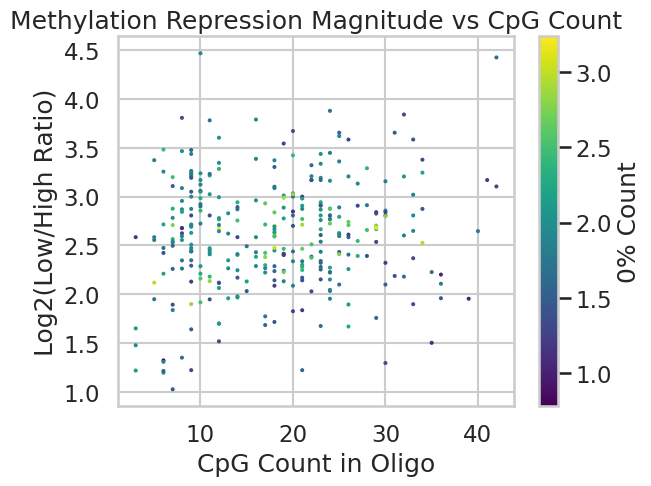

In [119]:
plt.scatter(tss_meth_repression_magnitude['CpG_Count'], np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), s=2, c=np.log10(tss_meth_repression_magnitude['0%']+1), cmap='viridis')
plt.colorbar(label='0% Count')
plt.xlabel('CpG Count in Oligo')
plt.ylabel('Log2(Low/High Ratio)')
plt.title('Methylation Repression Magnitude vs CpG Count')

In [120]:
# fit a linear regression model for log2(low_to_high_ratio) ~ CpG_Count
import statsmodels.api as sm
# Prepare the data
X = tss_meth_repression_magnitude['CpG_Count']
y = np.log2(tss_meth_repression_magnitude['low_to_high_ratio'])
X = sm.add_constant(X)  # Adds a constant term to the predictor
# Fit the model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      low_to_high_ratio   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     4.585
Date:                Thu, 11 Jun 2026   Prob (F-statistic):             0.0330
Time:                        14:39:29   Log-Likelihood:                -264.68
No. Observations:                 322   AIC:                             533.4
Df Residuals:                     320   BIC:                             540.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4703      0.072     34.531      0.0

## Midpoint: low (0%, 0.1%) vs. medium (20%)

In [113]:
df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (20% and 100%)
df_pivoted['low_to_medium_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / df_pivoted['20%'] / 2

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '20%', 'low_to_medium_ratio']]

In [114]:
tss_meth_repression_magnitude

Meth_State,Oligo_ID,0%,0.1%,20%,low_to_medium_ratio
0,CRISPer-promoters:12_SOCS1_chr16_11256199_-:ACGGGAGCGG,10.0,13.0,7.0,1.642857
1,CRISPer-promoters:13_C19orf43_chr19_12734681_-:GATAACCTAC,11.0,6.0,5.0,1.700000
2,CRISPer-promoters:13_C19orf43_chr19_12734681_-:GGCATCTGAC,21.0,10.0,7.0,2.214286
3,CRISPer-promoters:15_ECI1_chr16_2251586_-:AACTCAAGCC,32.0,38.0,9.0,3.888889
4,CRISPer-promoters:16_LETMD1_chr12_51048326_+:GAGTCAGGGA,107.0,80.0,21.0,4.452381
...,...,...,...,...,...
325,promoter_design:tss8_generated_1:TCTACCGCCG,87.0,67.0,34.0,2.264706
326,promoter_design:tss8_generated_2:GGCATAATGC,47.0,55.0,14.0,3.642857
327,promoter_design:tss8_generated_3:GTACGCGTCG,83.0,101.0,29.0,3.172414
328,promoter_design:tss8_real:TCGCAAGGTA,36.0,44.0,42.0,0.952381


In [115]:
oligo_cpg = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    cpg_count = ref_cpg_count.loc[ref_cpg_count['sequence_id'] == sequence_id, 'cpg_count'].values
    oligo_cpg.append(cpg_count[0].item())
tss_meth_repression_magnitude['CpG_Count'] = oligo_cpg
tss_meth_repression_magnitude.dropna(inplace=True)

Text(0.5, 1.0, 'Methylation Repression Magnitude vs CpG Count')

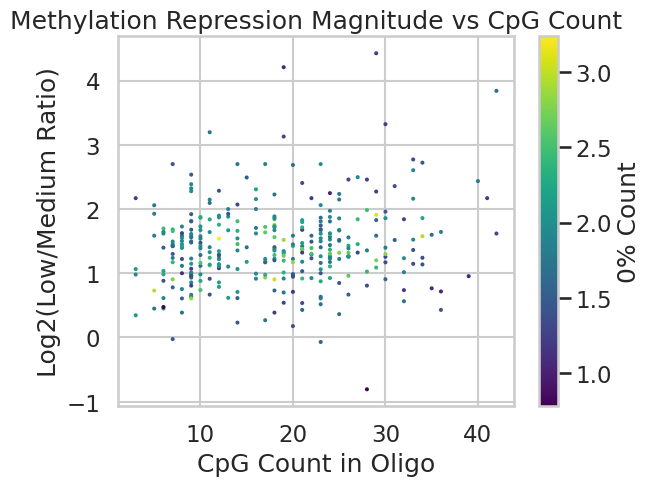

In [116]:
plt.scatter(tss_meth_repression_magnitude['CpG_Count'], np.log2(tss_meth_repression_magnitude['low_to_medium_ratio']), s=2, c=np.log10(tss_meth_repression_magnitude['0%']+1), cmap='viridis')
plt.colorbar(label='0% Count')
plt.xlabel('CpG Count in Oligo')
plt.ylabel('Log2(Low/Medium Ratio)')
plt.title('Methylation Repression Magnitude vs CpG Count')

# Test whether NRF motif-containing oligos show different methylation repression magnitude

In [22]:
motifmatches_np = np.load("./intermediate_data/oligo500-motif-screen.npy")
motifmatches_rc_np = np.load("./intermediate_data/oligo500-motif-screen-rc.npy")

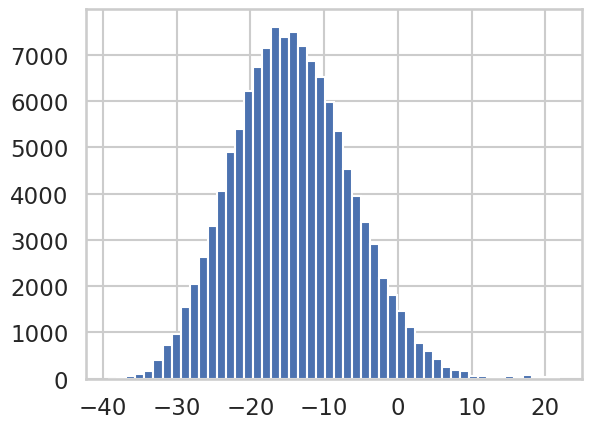

In [37]:
import matplotlib.pyplot as plt
plt.hist(motifmatches_np[:, 168].flatten(), bins=50)
plt.show()

In [38]:
# use cutoff=10
oligos_with_motif = (motifmatches_np[:, 168, :].max(axis=-1)>10) | (motifmatches_rc_np[:, 168, :].max(axis=-1)>10)
oligos_with_motif.sum()

np.int64(281)

In [45]:
df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

In [73]:
oligo_to_chrom

{'NativeTSS:2355:GCCCATGCAG': 'seq1',
 'NativeTSS:2355:ACGCGGATTG': 'seq2',
 'NativeTSS:1013:CGCACACTGG': 'seq3',
 'NativeTSS:1013:TAGCTCTGTG': 'seq4',
 'NativeTSS:3190:GTCCGGTTTG': 'seq5',
 'NativeTSS:3190:CCACCCTTCA': 'seq6',
 'NativeTSS:3878:GTCAGACTGC': 'seq7',
 'NativeTSS:3878:AGCGCGTTAT': 'seq8',
 'NativeTSS:2031:GTTCGGAGGC': 'seq9',
 'NativeTSS:2031:GAGTCGCATA': 'seq10',
 'NativeTSS:676:ATGGACCACT': 'seq11',
 'NativeTSS:676:GCTCTTTCGG': 'seq12',
 'NativeTSS:7238:AGAGGCTATG': 'seq13',
 'NativeTSS:7238:GTTTGGGAGG': 'seq14',
 'NativeTSS:6288:AGGCGTCAGC': 'seq15',
 'NativeTSS:6288:AGGTGCGATC': 'seq16',
 'NativeTSS:7316:CGTAGACACC': 'seq17',
 'NativeTSS:7316:GAAGGCGCCT': 'seq18',
 'NativeTSS:6165:TAACGGGCTT': 'seq19',
 'NativeTSS:6165:AACGAGGGTA': 'seq20',
 'NativeTSS:310:ACCTGGAAAC': 'seq21',
 'NativeTSS:310:GGAACTGCAA': 'seq22',
 'NativeTSS:8173:ACCAAGGGAC': 'seq23',
 'NativeTSS:8173:GGTGCCCATG': 'seq24',
 'NativeTSS:6687:GCAACGATGA': 'seq25',
 'NativeTSS:6687:CTCAGTGGTA': 'seq26',

In [46]:
oligo_with_motif = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    oligo_index = int(sequence_id.replace("seq", "")) - 1
    has_motif = oligos_with_motif[oligo_index]
    oligo_with_motif.append(has_motif)
tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
tss_meth_repression_magnitude.dropna(inplace=True)

In [ ]:
tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio'].mean(), tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio'].mean()

(np.float64(7.184818949588917), np.float64(5.630077830700118))

In [77]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
    np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
    alternative='two-sided', 
    nan_policy='omit'
)

print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value:.4e}")

Mann-Whitney U statistic: 16702.5
P-value: 1.5838e-07


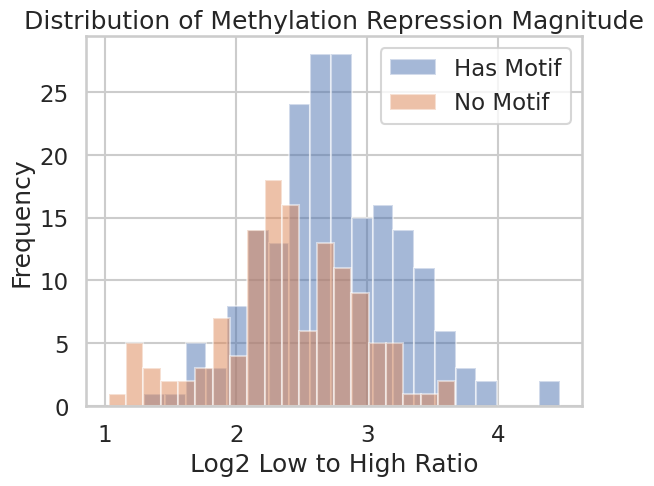

In [78]:
plt.hist(np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), bins=20, alpha=0.5, label='Has Motif')
plt.hist(np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), bins=20, alpha=0.5, label='No Motif')
plt.xlabel('Log2 Low to High Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of Methylation Repression Magnitude')
plt.legend()
plt.show()

In [81]:
from scipy.stats import mannwhitneyu

# test 0% expression level between oligos with vs without motif
stat, p_value = mannwhitneyu(
    np.log10(tss_meth_repression_magnitude.query("Has_Motif == True")['0%']+1), 
    np.log10(tss_meth_repression_magnitude.query("Has_Motif == False")['0%']+1), 
    alternative='two-sided', 
    nan_policy='omit'
)

print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value:.4e}")

Mann-Whitney U statistic: 11185.5
P-value: 1.3244e-01


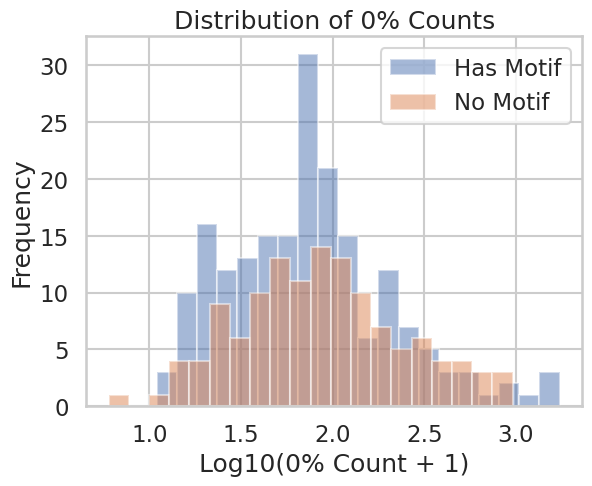

In [80]:
plt.hist(np.log10(tss_meth_repression_magnitude.query("Has_Motif == True")['0%']+1), bins=20, alpha=0.5, label='Has Motif')
plt.hist(np.log10(tss_meth_repression_magnitude.query("Has_Motif == False")['0%']+1), bins=20, alpha=0.5, label='No Motif')
plt.xlabel('Log10(0% Count + 1)')
plt.ylabel('Frequency')
plt.title('Distribution of 0% Counts')
plt.legend()
plt.show()

## NFY motif

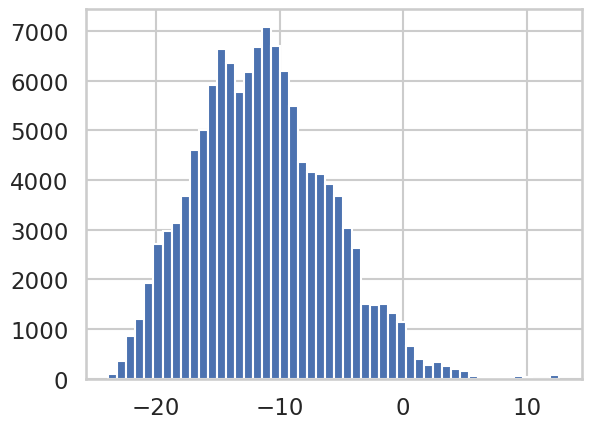

In [107]:
# (37, 'NFYA'), (165, 'NFYB'), (724, 'NFYC')
import matplotlib.pyplot as plt
plt.hist(motifmatches_np[:, 724].flatten(), bins=50)
plt.show()

In [86]:
# use cutoff=10
oligos_with_nfya = (motifmatches_np[:, 37, :].max(axis=-1)>10) | (motifmatches_rc_np[:, 37, :].max(axis=-1)>10)
oligos_with_nfya.sum()

np.int64(161)

In [91]:
df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

oligo_with_motif = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    oligo_index = int(sequence_id.replace("seq", "")) - 1
    has_motif = oligos_with_nfya[oligo_index]
    oligo_with_motif.append(has_motif)
tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
tss_meth_repression_magnitude.dropna(inplace=True)
tss_meth_repression_magnitude.head()

Meth_State,Oligo_ID,0%,0.1%,60%,100%,low_to_high_ratio,Has_Motif
0,CRISPer-promoters:12_SOCS1_chr16_11256199_-:ACGGGAGCGG,10.0,13.0,4.0,1.0,4.600000,False
1,CRISPer-promoters:13_C19orf43_chr19_12734681_-:GATAACCTAC,11.0,6.0,3.0,3.0,2.833333,False
2,CRISPer-promoters:13_C19orf43_chr19_12734681_-:GGCATCTGAC,21.0,10.0,3.0,3.0,5.166667,False
3,CRISPer-promoters:15_ECI1_chr16_2251586_-:AACTCAAGCC,32.0,38.0,6.0,4.0,7.000000,False
4,CRISPer-promoters:16_LETMD1_chr12_51048326_+:GAGTCAGGGA,107.0,80.0,14.0,10.0,7.791667,True


In [92]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
    np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
    alternative='two-sided', 
    nan_policy='omit'
)

print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value:.4e}")

Mann-Whitney U statistic: 10478.0
P-value: 2.1683e-01


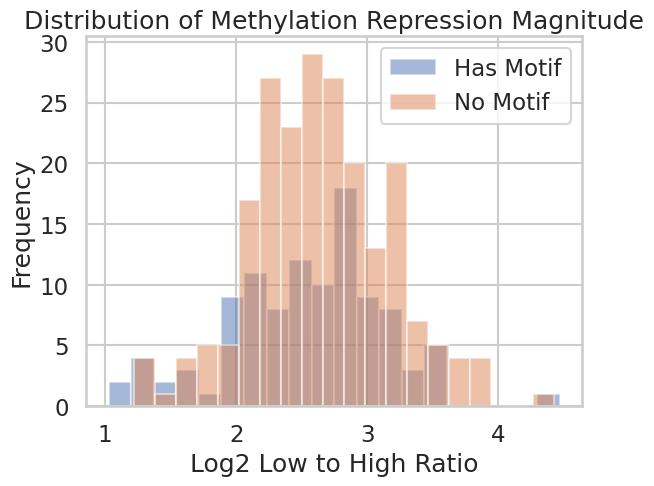

In [93]:
plt.hist(np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), bins=20, alpha=0.5, label='Has Motif')
plt.hist(np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), bins=20, alpha=0.5, label='No Motif')
plt.xlabel('Log2 Low to High Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of Methylation Repression Magnitude')
plt.legend()
plt.show()

In [98]:
# use cutoff=10
oligos_with_nfyb = (motifmatches_np[:, 165, :].max(axis=-1)>10) | (motifmatches_rc_np[:, 165, :].max(axis=-1)>10)
oligos_with_nfyb.sum()

np.int64(183)

In [99]:
df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

oligo_with_motif = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    oligo_index = int(sequence_id.replace("seq", "")) - 1
    has_motif = oligos_with_nfyb[oligo_index]
    oligo_with_motif.append(has_motif)
tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
tss_meth_repression_magnitude.dropna(inplace=True)

from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
    np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
    alternative='two-sided', 
    nan_policy='omit'
)

print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value:.4e}")

Mann-Whitney U statistic: 11898.0
P-value: 7.4607e-01


In [108]:
# use cutoff=10
oligos_with_nfyc = (motifmatches_np[:, 724, :].max(axis=-1)>10) | (motifmatches_rc_np[:, 724, :].max(axis=-1)>10)
oligos_with_nfyc.sum()

np.int64(95)

In [109]:
df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

oligo_with_motif = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    oligo_index = int(sequence_id.replace("seq", "")) - 1
    has_motif = oligos_with_nfyc[oligo_index]
    oligo_with_motif.append(has_motif)
tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
tss_meth_repression_magnitude.dropna(inplace=True)

from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
    np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
    alternative='two-sided', 
    nan_policy='omit'
)

print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value:.4e}")

Mann-Whitney U statistic: 6901.0
P-value: 5.7861e-02


## CREB

In [120]:
test_motifs = [
(8, 'CREB1'),
 (207, 'Creb3l2'),
 (235, 'CREB3'),
 (435, 'CREB3L1'),
 (436, 'Creb5'),
 (581, 'CREB3L4'),
 (582, 'CREB3L4'),
 (935, 'CREB3L3')
]

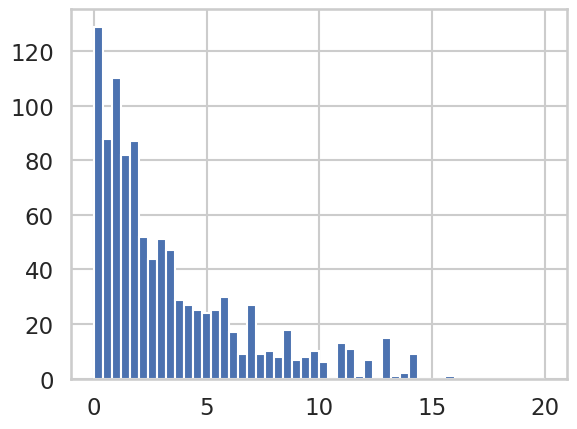

In [87]:
import matplotlib.pyplot as plt
plt.hist(motifmatches_np[:, 235].flatten(), bins=50, range=(0,20))
plt.show()

In [121]:
# use cutoff=10
for idx, motif in test_motifs:
    oligos_with_motif = (motifmatches_np[:, idx, :].max(axis=-1)>10) | (motifmatches_rc_np[:, idx, :].max(axis=-1)>10)
    print(f"Number of oligos with motif {motif}: {oligos_with_motif.sum()}")

    df = filtered_tss_counts_agg.copy()

    df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

    # 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
    df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

    # 3. (Optional) Clean up the resulting DataFrame
    # Reset the index to turn 'Oligo_ID' back into a regular column
    tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

    oligo_with_motif = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        has_motif = oligos_with_motif[oligo_index]
        oligo_with_motif.append(has_motif)
    tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
    tss_meth_repression_magnitude.dropna(inplace=True)

    from scipy.stats import mannwhitneyu

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )

    print(f"Mann-Whitney U statistic: {stat}")
    print(f"P-value: {p_value:.4e}")

Number of oligos with motif CREB1: 30
Mann-Whitney U statistic: 3550.5
P-value: 5.5308e-01
Number of oligos with motif Creb3l2: 51
Mann-Whitney U statistic: 5445.0
P-value: 9.2830e-01
Number of oligos with motif CREB3: 113
Mann-Whitney U statistic: 10898.0
P-value: 2.5698e-03
Number of oligos with motif CREB3L1: 52
Mann-Whitney U statistic: 4480.5
P-value: 4.1888e-01
Number of oligos with motif Creb5: 115
Mann-Whitney U statistic: 9988.0
P-value: 6.6255e-02
Number of oligos with motif CREB3L4: 162
Mann-Whitney U statistic: 12980.5
P-value: 1.5013e-02
Number of oligos with motif CREB3L4: 162
Mann-Whitney U statistic: 12980.5
P-value: 1.5013e-02
Number of oligos with motif CREB3L3: 42
Mann-Whitney U statistic: 3692.0
P-value: 2.4498e-01


In [ ]:
# use cutoff=8
for idx, motif in test_motifs:
    oligos_with_motif = (motifmatches_np[:, idx, :].max(axis=-1)>8) | (motifmatches_rc_np[:, idx, :].max(axis=-1)>8)
    print(f"Number of oligos with motif {motif}: {oligos_with_motif.sum()}")

    df = filtered_tss_counts_agg.copy()

    df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

    # 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
    df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

    # 3. (Optional) Clean up the resulting DataFrame
    # Reset the index to turn 'Oligo_ID' back into a regular column
    tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

    oligo_with_motif = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        has_motif = oligos_with_motif[oligo_index]
        oligo_with_motif.append(has_motif)
    tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
    tss_meth_repression_magnitude.dropna(inplace=True)

    from scipy.stats import mannwhitneyu

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )

    print(f"Mann-Whitney U statistic: {stat}")
    print(f"P-value: {p_value:.4e}")

Number of oligos with motif CREB1: 106
Mann-Whitney U statistic: 9390.5
P-value: 4.0811e-01
Number of oligos with motif Creb3l2: 141
Mann-Whitney U statistic: 11707.5
P-value: 7.3197e-02
Number of oligos with motif CREB3: 180
Mann-Whitney U statistic: 13278.0
P-value: 8.5839e-02
Number of oligos with motif CREB3L1: 106
Mann-Whitney U statistic: 8564.5
P-value: 6.1788e-01
Number of oligos with motif Creb5: 137
Mann-Whitney U statistic: 11478.0
P-value: 7.2053e-02
Number of oligos with motif CREB3L4: 215
Mann-Whitney U statistic: 13915.5
P-value: 1.5595e-01
Number of oligos with motif CREB3L4: 215
Mann-Whitney U statistic: 13915.5
P-value: 1.5595e-01
Number of oligos with motif CREB3L3: 66
Mann-Whitney U statistic: 6356.0
P-value: 9.8976e-01


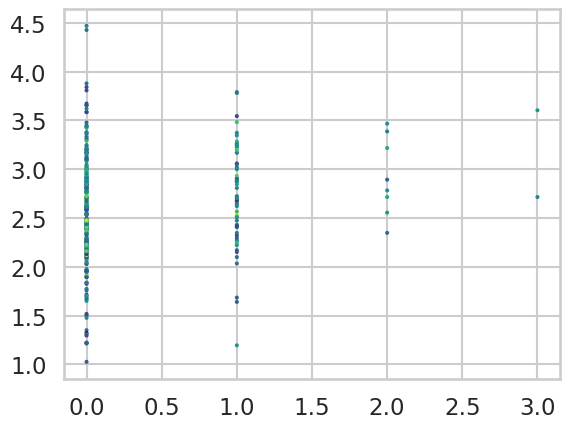

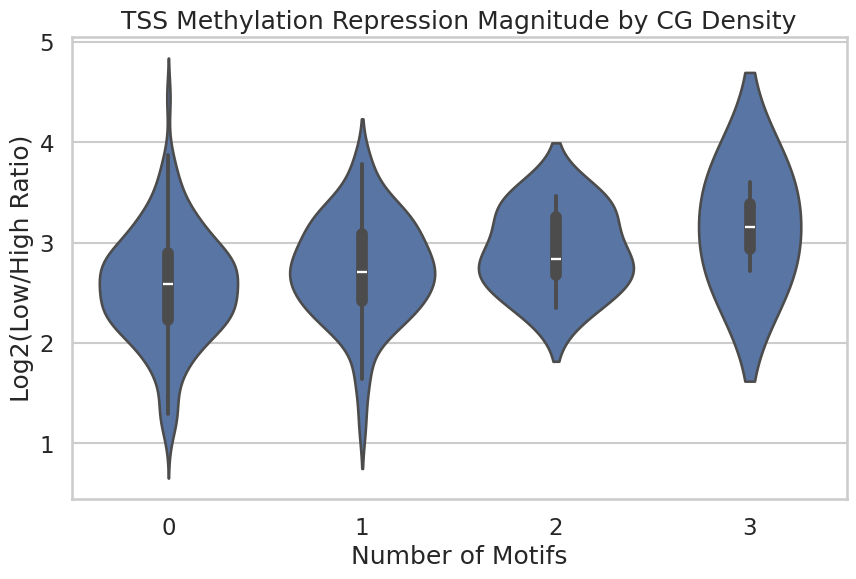

In [89]:
# CREB3
oligos_with_motif_count = (motifmatches_np[:, 235, :]>10).sum(axis=-1) + (motifmatches_rc_np[:, 235, :]>10).sum(axis=-1)

df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

oligo_with_motif_count = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    oligo_index = int(sequence_id.replace("seq", "")) - 1
    has_motif = oligos_with_motif_count[oligo_index]
    oligo_with_motif_count.append(has_motif)
tss_meth_repression_magnitude['Num_Motif'] = oligo_with_motif_count
tss_meth_repression_magnitude.dropna(inplace=True)

plt.scatter(tss_meth_repression_magnitude['Num_Motif'], np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), s=2, c=np.log10(tss_meth_repression_magnitude['0%']+1), cmap='viridis')

# violin plot of low_to_high_ratio for oligos with Num_Motif = 0, 1, 2, 3
import seaborn as sns
tss_meth_repression_magnitude['Num_Motif_Bin'] = pd.cut(tss_meth_repression_magnitude['Num_Motif'], bins=[-0.5, 0.5, 1.5, 2.5, 3.5], labels=['0', '1', '2', '3'])
plt.figure(figsize=(10, 6))
sns.violinplot(x='Num_Motif_Bin', y=np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), data=tss_meth_repression_magnitude, inner='box')
plt.xlabel('Number of Motifs')
plt.ylabel('Log2(Low/High Ratio)')
plt.title('TSS Methylation Repression Magnitude by CG Density')
plt.show()

In [90]:
# fit a linear regression model for log2(low_to_medium_ratio) ~ CpG_Count
import statsmodels.api as sm
X = tss_meth_repression_magnitude['Num_Motif']
y = np.log2(tss_meth_repression_magnitude['low_to_high_ratio'])
X = sm.add_constant(X)  # Adds a constant term to the predictor
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      low_to_high_ratio   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     9.405
Date:                Thu, 11 Jun 2026   Prob (F-statistic):            0.00235
Time:                        11:48:57   Log-Likelihood:                -262.31
No. Observations:                 322   AIC:                             528.6
Df Residuals:                     320   BIC:                             536.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5632      0.034     75.525      0.0

## ETS

In [123]:
test_motifs = [(67, 'ETS1'), (589, 'ETS2')]

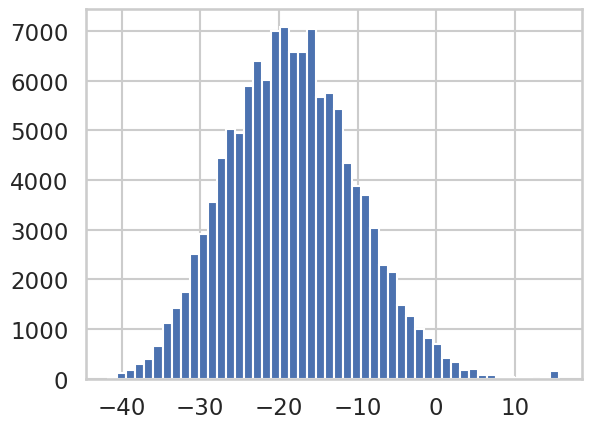

In [125]:
import matplotlib.pyplot as plt
plt.hist(motifmatches_np[:, 589].flatten(), bins=50)
plt.show()

In [126]:
# use cutoff=10
for idx, motif in test_motifs:
    oligos_with_motif = (motifmatches_np[:, idx, :].max(axis=-1)>10) | (motifmatches_rc_np[:, idx, :].max(axis=-1)>10)
    print(f"Number of oligos with motif {motif}: {oligos_with_motif.sum()}")

    df = filtered_tss_counts_agg.copy()

    df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

    # 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
    df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

    # 3. (Optional) Clean up the resulting DataFrame
    # Reset the index to turn 'Oligo_ID' back into a regular column
    tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

    oligo_with_motif = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        has_motif = oligos_with_motif[oligo_index]
        oligo_with_motif.append(has_motif)
    tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
    tss_meth_repression_magnitude.dropna(inplace=True)

    from scipy.stats import mannwhitneyu

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )

    print(f"Mann-Whitney U statistic: {stat}")
    print(f"P-value: {p_value:.4e}")

Number of oligos with motif ETS1: 248
Mann-Whitney U statistic: 13676.5
P-value: 2.5837e-01
Number of oligos with motif ETS2: 245
Mann-Whitney U statistic: 13816.5
P-value: 2.3669e-01


In [127]:
# use cutoff=8
for idx, motif in test_motifs:
    oligos_with_motif = (motifmatches_np[:, idx, :].max(axis=-1)>8) | (motifmatches_rc_np[:, idx, :].max(axis=-1)>8)
    print(f"Number of oligos with motif {motif}: {oligos_with_motif.sum()}")

    df = filtered_tss_counts_agg.copy()

    df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

    # 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
    df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

    # 3. (Optional) Clean up the resulting DataFrame
    # Reset the index to turn 'Oligo_ID' back into a regular column
    tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

    oligo_with_motif = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        has_motif = oligos_with_motif[oligo_index]
        oligo_with_motif.append(has_motif)
    tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
    tss_meth_repression_magnitude.dropna(inplace=True)

    from scipy.stats import mannwhitneyu

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )

    print(f"Mann-Whitney U statistic: {stat}")
    print(f"P-value: {p_value:.4e}")

Number of oligos with motif ETS1: 325
Mann-Whitney U statistic: 12403.0
P-value: 2.6385e-02
Number of oligos with motif ETS2: 319
Mann-Whitney U statistic: 13362.0
P-value: 3.4379e-03


## CEBP

In [128]:
test_motifs = [(71, 'CEBPA'),
 (130, 'CEBPB'),
 (432, 'CEBPD'),
 (433, 'CEBPE'),
 (434, 'CEBPG'),
 (716, 'CEBPG')]

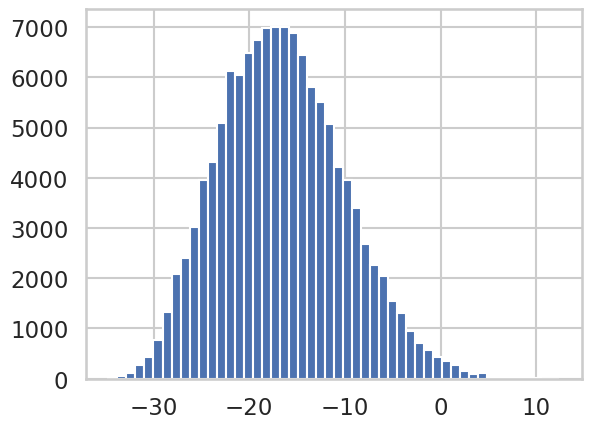

In [134]:
import matplotlib.pyplot as plt
plt.hist(motifmatches_np[:, 716].flatten(), bins=50)
plt.show()

In [135]:
# use cutoff=10
for idx, motif in test_motifs:
    oligos_with_motif = (motifmatches_np[:, idx, :].max(axis=-1)>10) | (motifmatches_rc_np[:, idx, :].max(axis=-1)>10)
    print(f"Number of oligos with motif {motif}: {oligos_with_motif.sum()}")

    df = filtered_tss_counts_agg.copy()

    df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

    # 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
    df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

    # 3. (Optional) Clean up the resulting DataFrame
    # Reset the index to turn 'Oligo_ID' back into a regular column
    tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

    oligo_with_motif = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        has_motif = oligos_with_motif[oligo_index]
        oligo_with_motif.append(has_motif)
    tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
    tss_meth_repression_magnitude.dropna(inplace=True)

    from scipy.stats import mannwhitneyu

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )

    print(f"Mann-Whitney U statistic: {stat}")
    print(f"P-value: {p_value:.4e}")

Number of oligos with motif CEBPA: 9
Mann-Whitney U statistic: 460.0
P-value: 1.0797e-01
Number of oligos with motif CEBPB: 3
Mann-Whitney U statistic: 315.5
P-value: 3.1130e-01
Number of oligos with motif CEBPD: 20
Mann-Whitney U statistic: 1897.5
P-value: 4.4886e-01
Number of oligos with motif CEBPE: 3
Mann-Whitney U statistic: 315.5
P-value: 3.1130e-01
Number of oligos with motif CEBPG: 18
Mann-Whitney U statistic: 1659.5
P-value: 7.3263e-01
Number of oligos with motif CEBPG: 18
Mann-Whitney U statistic: 1659.5
P-value: 7.3263e-01


In [ ]:
# use cutoff=5
for idx, motif in test_motifs:
    oligos_with_motif = (motifmatches_np[:, idx, :].max(axis=-1)>5) | (motifmatches_rc_np[:, idx, :].max(axis=-1)>5)
    print(f"Number of oligos with motif {motif}: {oligos_with_motif.sum()}")

    df = filtered_tss_counts_agg.copy()

    df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

    # 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
    df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

    # 3. (Optional) Clean up the resulting DataFrame
    # Reset the index to turn 'Oligo_ID' back into a regular column
    tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

    oligo_with_motif = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        has_motif = oligos_with_motif[oligo_index]
        oligo_with_motif.append(has_motif)
    tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
    tss_meth_repression_magnitude.dropna(inplace=True)

    from scipy.stats import mannwhitneyu

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )

    print(f"Mann-Whitney U statistic: {stat}")
    print(f"P-value: {p_value:.4e}")

Number of oligos with motif CEBPA: 191
Mann-Whitney U statistic: 12789.0
P-value: 5.8900e-01
Number of oligos with motif CEBPB: 61
Mann-Whitney U statistic: 6529.5
P-value: 1.6757e-01
Number of oligos with motif CEBPD: 230
Mann-Whitney U statistic: 12311.0
P-value: 5.3076e-01
Number of oligos with motif CEBPE: 61
Mann-Whitney U statistic: 6529.5
P-value: 1.6757e-01
Number of oligos with motif CEBPG: 153
Mann-Whitney U statistic: 10245.5
P-value: 2.3806e-01
Number of oligos with motif CEBPG: 153
Mann-Whitney U statistic: 10245.5
P-value: 2.3806e-01


## ONECUT

In [138]:
test_motifs = [(276, 'ONECUT1'), (353, 'ONECUT2'), (354, 'ONECUT3')]

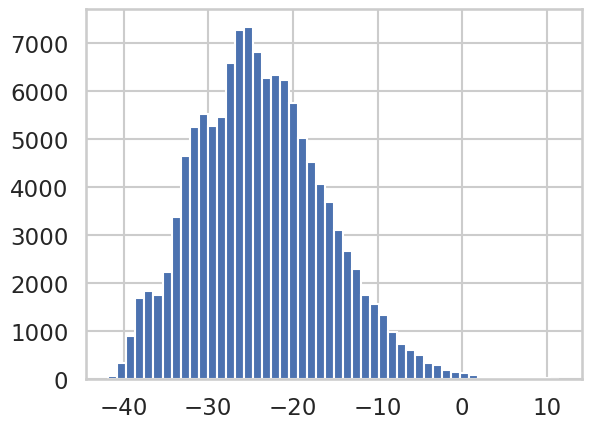

In [141]:
import matplotlib.pyplot as plt
plt.hist(motifmatches_np[:, 354].flatten(), bins=50)
plt.show()

In [ ]:
# use cutoff=8
for idx, motif in test_motifs:
    oligos_with_motif = (motifmatches_np[:, idx, :].max(axis=-1)>8) | (motifmatches_rc_np[:, idx, :].max(axis=-1)>8)
    print(f"Number of oligos with motif {motif}: {oligos_with_motif.sum()}")

    df = filtered_tss_counts_agg.copy()

    df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

    # 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
    df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

    # 3. (Optional) Clean up the resulting DataFrame
    # Reset the index to turn 'Oligo_ID' back into a regular column
    tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

    oligo_with_motif = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        has_motif = oligos_with_motif[oligo_index]
        oligo_with_motif.append(has_motif)
    tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
    tss_meth_repression_magnitude.dropna(inplace=True)

    from scipy.stats import mannwhitneyu

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )

    print(f"Mann-Whitney U statistic: {stat}")
    print(f"P-value: {p_value:.4e}")

Number of oligos with motif ONECUT1: 32
Mann-Whitney U statistic: 1885.5
P-value: 7.0949e-01
Number of oligos with motif ONECUT2: 30
Mann-Whitney U statistic: 1405.5
P-value: 5.9513e-01
Number of oligos with motif ONECUT3: 18
Mann-Whitney U statistic: 1183.0
P-value: 7.8038e-01


## YY

In [144]:
test_motifs = [(66, 'Yy1'), (345, 'YY2')]

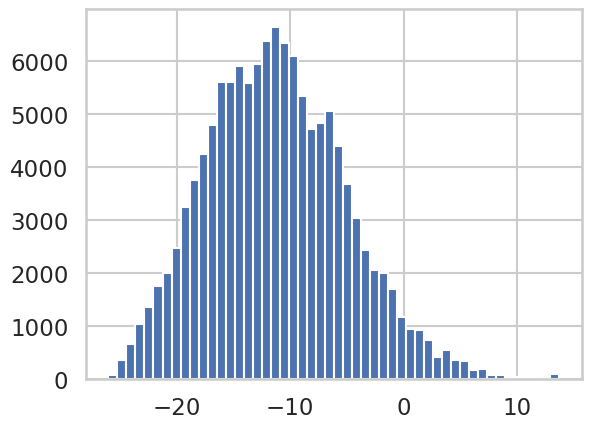

In [146]:
import matplotlib.pyplot as plt
plt.hist(motifmatches_np[:, 345].flatten(), bins=50)
plt.show()

In [149]:
# use cutoff=10
for idx, motif in test_motifs:
    oligos_with_motif = (motifmatches_np[:, idx, :].max(axis=-1)>10) | (motifmatches_rc_np[:, idx, :].max(axis=-1)>10)
    print(f"Number of oligos with motif {motif}: {oligos_with_motif.sum()}")

    df = filtered_tss_counts_agg.copy()

    df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

    # 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
    df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

    # 3. (Optional) Clean up the resulting DataFrame
    # Reset the index to turn 'Oligo_ID' back into a regular column
    tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

    oligo_with_motif = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        has_motif = oligos_with_motif[oligo_index]
        oligo_with_motif.append(has_motif)
    tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
    tss_meth_repression_magnitude.dropna(inplace=True)

    from scipy.stats import mannwhitneyu

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )

    print(f"Mann-Whitney U statistic: {stat}")
    print(f"P-value: {p_value:.4e}")

Number of oligos with motif Yy1: 114
Mann-Whitney U statistic: 8749.5
P-value: 8.1674e-01
Number of oligos with motif YY2: 168
Mann-Whitney U statistic: 12709.0
P-value: 1.2537e-01


In [148]:
# use cutoff=8
for idx, motif in test_motifs:
    oligos_with_motif = (motifmatches_np[:, idx, :].max(axis=-1)>8) | (motifmatches_rc_np[:, idx, :].max(axis=-1)>8)
    print(f"Number of oligos with motif {motif}: {oligos_with_motif.sum()}")

    df = filtered_tss_counts_agg.copy()

    df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

    # 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
    df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

    # 3. (Optional) Clean up the resulting DataFrame
    # Reset the index to turn 'Oligo_ID' back into a regular column
    tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

    oligo_with_motif = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        has_motif = oligos_with_motif[oligo_index]
        oligo_with_motif.append(has_motif)
    tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
    tss_meth_repression_magnitude.dropna(inplace=True)

    from scipy.stats import mannwhitneyu

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )

    print(f"Mann-Whitney U statistic: {stat}")
    print(f"P-value: {p_value:.4e}")

Number of oligos with motif Yy1: 176
Mann-Whitney U statistic: 11922.0
P-value: 9.7463e-01
Number of oligos with motif YY2: 298
Mann-Whitney U statistic: 14273.5
P-value: 4.5255e-02


## SP

In [150]:
test_motifs = [(54, 'SP1'),
 (177, 'SP2'),
 (282, 'SP4'),
 (343, 'SP3'),
 (344, 'SP8'),
 (661, 'SP9'),
 (802, 'SP5')]

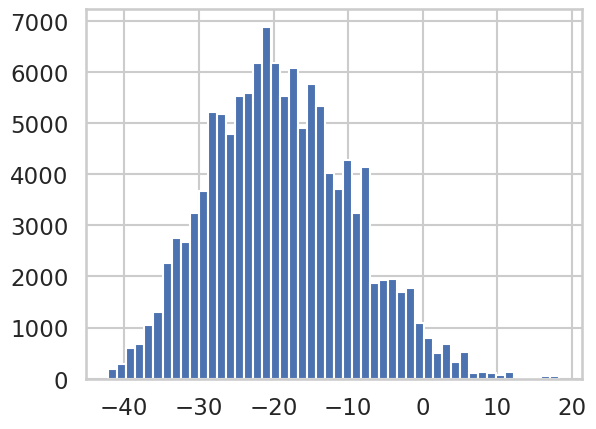

In [153]:
import matplotlib.pyplot as plt
plt.hist(motifmatches_np[:, 282].flatten(), bins=50)
plt.show()

In [154]:
# use cutoff=10
for idx, motif in test_motifs:
    oligos_with_motif = (motifmatches_np[:, idx, :].max(axis=-1)>10) | (motifmatches_rc_np[:, idx, :].max(axis=-1)>10)
    print(f"Number of oligos with motif {motif}: {oligos_with_motif.sum()}")

    df = filtered_tss_counts_agg.copy()

    df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

    # 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
    df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

    # 3. (Optional) Clean up the resulting DataFrame
    # Reset the index to turn 'Oligo_ID' back into a regular column
    tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

    oligo_with_motif = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        has_motif = oligos_with_motif[oligo_index]
        oligo_with_motif.append(has_motif)
    tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
    tss_meth_repression_magnitude.dropna(inplace=True)

    from scipy.stats import mannwhitneyu

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )

    print(f"Mann-Whitney U statistic: {stat}")
    print(f"P-value: {p_value:.4e}")

Number of oligos with motif SP1: 278
Mann-Whitney U statistic: 10888.0
P-value: 4.4424e-02
Number of oligos with motif SP2: 298
Mann-Whitney U statistic: 11287.0
P-value: 3.0270e-01
Number of oligos with motif SP4: 283
Mann-Whitney U statistic: 11138.5
P-value: 8.8161e-02
Number of oligos with motif SP3: 258
Mann-Whitney U statistic: 12539.5
P-value: 7.3967e-01
Number of oligos with motif SP8: 254
Mann-Whitney U statistic: 12182.5
P-value: 4.3453e-01
Number of oligos with motif SP9: 308
Mann-Whitney U statistic: 11259.0
P-value: 4.2181e-01
Number of oligos with motif SP5: 185
Mann-Whitney U statistic: 11752.0
P-value: 3.9520e-01


In [155]:
# use cutoff=12
for idx, motif in test_motifs:
    oligos_with_motif = (motifmatches_np[:, idx, :].max(axis=-1)>12) | (motifmatches_rc_np[:, idx, :].max(axis=-1)>12)
    print(f"Number of oligos with motif {motif}: {oligos_with_motif.sum()}")

    df = filtered_tss_counts_agg.copy()

    df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

    # 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
    df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

    # 3. (Optional) Clean up the resulting DataFrame
    # Reset the index to turn 'Oligo_ID' back into a regular column
    tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

    oligo_with_motif = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        has_motif = oligos_with_motif[oligo_index]
        oligo_with_motif.append(has_motif)
    tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
    tss_meth_repression_magnitude.dropna(inplace=True)

    from scipy.stats import mannwhitneyu

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )

    print(f"Mann-Whitney U statistic: {stat}")
    print(f"P-value: {p_value:.4e}")

Number of oligos with motif SP1: 217
Mann-Whitney U statistic: 11886.0
P-value: 2.2900e-01
Number of oligos with motif SP2: 243
Mann-Whitney U statistic: 11497.0
P-value: 8.0247e-02
Number of oligos with motif SP4: 221
Mann-Whitney U statistic: 11958.0
P-value: 2.7731e-01
Number of oligos with motif SP3: 213
Mann-Whitney U statistic: 12354.0
P-value: 5.0481e-01
Number of oligos with motif SP8: 187
Mann-Whitney U statistic: 12064.5
P-value: 5.6318e-01
Number of oligos with motif SP9: 217
Mann-Whitney U statistic: 12190.0
P-value: 4.1933e-01
Number of oligos with motif SP5: 184
Mann-Whitney U statistic: 11752.0
P-value: 3.9520e-01


## ZNF143

In [156]:
test_motifs = [(60, 'ZNF143')]

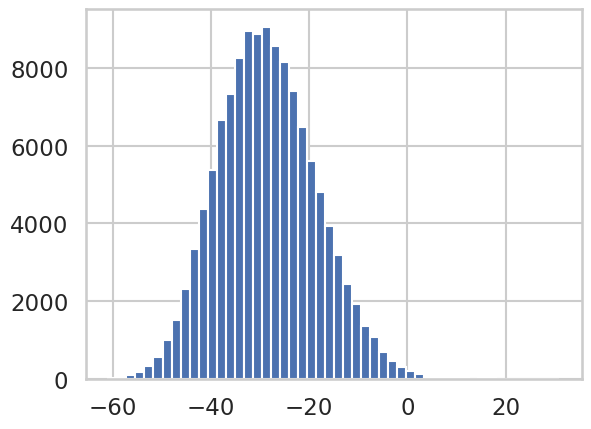

In [157]:
import matplotlib.pyplot as plt
plt.hist(motifmatches_np[:, 60].flatten(), bins=50)
plt.show()

In [ ]:
# use cutoff=10
for idx, motif in test_motifs:
    oligos_with_motif = (motifmatches_np[:, idx, :].max(axis=-1)>10) | (motifmatches_rc_np[:, idx, :].max(axis=-1)>10)
    print(f"Number of oligos with motif {motif}: {oligos_with_motif.sum()}")

    df = filtered_tss_counts_agg.copy()

    df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

    # 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
    df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

    # 3. (Optional) Clean up the resulting DataFrame
    # Reset the index to turn 'Oligo_ID' back into a regular column
    tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

    oligo_with_motif = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        has_motif = oligos_with_motif[oligo_index]
        oligo_with_motif.append(has_motif)
    tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
    tss_meth_repression_magnitude.dropna(inplace=True)

    from scipy.stats import mannwhitneyu

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )

    print(f"Mann-Whitney U statistic: {stat}")
    print(f"P-value: {p_value:.4e}")

Number of oligos with motif ZNF143: 69
Mann-Whitney U statistic: 7539.5
P-value: 5.0754e-01


In [160]:
# use cutoff=5
for idx, motif in test_motifs:
    oligos_with_motif = (motifmatches_np[:, idx, :].max(axis=-1)>5) | (motifmatches_rc_np[:, idx, :].max(axis=-1)>5)
    print(f"Number of oligos with motif {motif}: {oligos_with_motif.sum()}")

    df = filtered_tss_counts_agg.copy()

    df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

    # 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
    df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

    # 3. (Optional) Clean up the resulting DataFrame
    # Reset the index to turn 'Oligo_ID' back into a regular column
    tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

    oligo_with_motif = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        has_motif = oligos_with_motif[oligo_index]
        oligo_with_motif.append(has_motif)
    tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
    tss_meth_repression_magnitude.dropna(inplace=True)

    from scipy.stats import mannwhitneyu

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )

    print(f"Mann-Whitney U statistic: {stat}")
    print(f"P-value: {p_value:.4e}")

Number of oligos with motif ZNF143: 163
Mann-Whitney U statistic: 12562.5
P-value: 5.4876e-01


## all available motifs

In [66]:
import glob
motiffiles = sorted(glob.glob('../../data/JASPAR/*.jaspar'))

from Bio.motifs import jaspar
motifs=[]
for m in motiffiles:
    motifs.append(jaspar.read(open(m,'r'), 'jaspar').pop())
    
motifname = [m.name for m in motifs]

In [67]:
num_exist_motifs = []
test_pvalues = []
# use cutoff=10
for idx, motif in enumerate(motifname):
    oligos_with_motif = (motifmatches_np[:, idx, :].max(axis=-1)>10) | (motifmatches_rc_np[:, idx, :].max(axis=-1)>10)
    # print(f"Number of oligos with motif {motif}: {oligos_with_motif.sum()}")

    df = filtered_tss_counts_agg.copy()

    df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

    # 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
    df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

    # 3. (Optional) Clean up the resulting DataFrame
    # Reset the index to turn 'Oligo_ID' back into a regular column
    tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

    oligo_with_motif = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        has_motif = oligos_with_motif[oligo_index]
        oligo_with_motif.append(has_motif)
    tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
    tss_meth_repression_magnitude.dropna(inplace=True)
    num_exist_motifs.append(tss_meth_repression_magnitude['Has_Motif'].sum())

    from scipy.stats import mannwhitneyu

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )

    # print(f"Mann-Whitney U statistic: {stat}")
    # print(f"P-value: {p_value:.4e}")
    test_pvalues.append(p_value)

/home/yuchenz2/mytmp/ipykernel_4049530/1762652559.py:31: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_value = mannwhitneyu(
/home/yuchenz2/mytmp/ipykernel_4049530/1762652559.py:31: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_value = mannwhitneyu(
/home/yuchenz2/mytmp/ipykernel_4049530/1762652559.py:31: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_value = mannwhitneyu(
/home/yuchenz2/mytmp/ipykernel_4049530/1762652559.py:31: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_value = mannwhitneyu(
/home/yuchenz2/mytmp/ipykernel_4049530/1762652559.py:31: SmallSample

In [ ]:
with open('./intermediate_data/motif_mannwhitneyu_results_cutoff10.txt', 'w') as f:
    f.write(my_output.stdout)

In [68]:
motif_test_results = pd.DataFrame({
    'Motif': motifname,
    'Num_Oligos_With_Motif': num_exist_motifs,
    'PValue': test_pvalues
})

In [69]:
motif_test_results.query("PValue < 0.05").sort_values('PValue')[:20]

,Motif,Num_Oligos_With_Motif,PValue
168,Nrf1,194,1.583809e-07
940,ZNF131,241,2.822881e-04
84,Mafb,24,1.691829e-03
827,Gli1,41,1.886275e-03
235,CREB3,70,2.569800e-03
560,PPARA::RXRA,24,4.828981e-03
775,ERF::NHLH1,39,5.645756e-03
923,ZNF772,3,6.000475e-03
595,HNF4A,5,9.065509e-03
81,HNF4A,5,9.065509e-03


In [71]:
motif_test_results.sort_values('PValue').to_csv('./intermediate_data/motif_mannwhitneyu_results_cutoff10.csv', index=False)

## ZNF131

In [ ]:
motifmatches_np = np.load("./intermediate_data/oligo500-motif-screen.npy")
motifmatches_rc_np = np.load("./intermediate_data/oligo500-motif-screen-rc.npy")

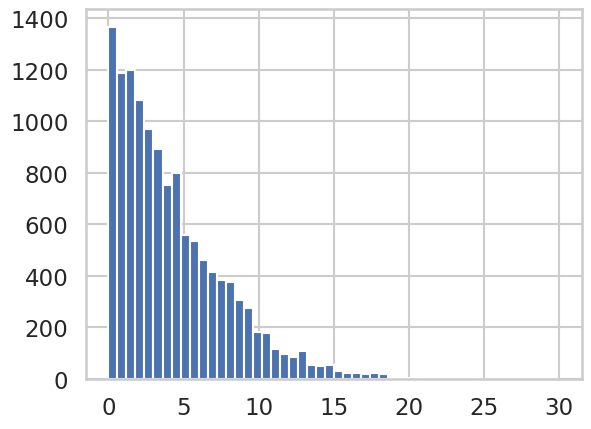

In [91]:
test_motifs = [(940, 'ZNF143')]
import matplotlib.pyplot as plt
plt.hist(motifmatches_np[:, 940].flatten(), bins=50, range=(0, 30))
plt.show()

In [92]:
# use cutoff=10
for idx, motif in test_motifs:
    oligos_with_motif = (motifmatches_np[:, idx, :].max(axis=-1)>15) | (motifmatches_rc_np[:, idx, :].max(axis=-1)>15)

    df = filtered_tss_counts_agg.copy()

    df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

    # 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
    df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

    # 3. (Optional) Clean up the resulting DataFrame
    # Reset the index to turn 'Oligo_ID' back into a regular column
    tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

    oligo_with_motif = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        has_motif = oligos_with_motif[oligo_index]
        oligo_with_motif.append(has_motif)
    tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
    tss_meth_repression_magnitude.dropna(inplace=True)

    from scipy.stats import mannwhitneyu

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )
    print(f"Number of oligos with motif {motif}: {tss_meth_repression_magnitude.query('Has_Motif == True').shape[0]} / {tss_meth_repression_magnitude.shape[0]}")
    print(f"Mann-Whitney U statistic: {stat}")
    print(f"P-value: {p_value:.4e}")

Number of oligos with motif ZNF143: 90 / 322
Mann-Whitney U statistic: 11500.5
P-value: 1.5737e-01


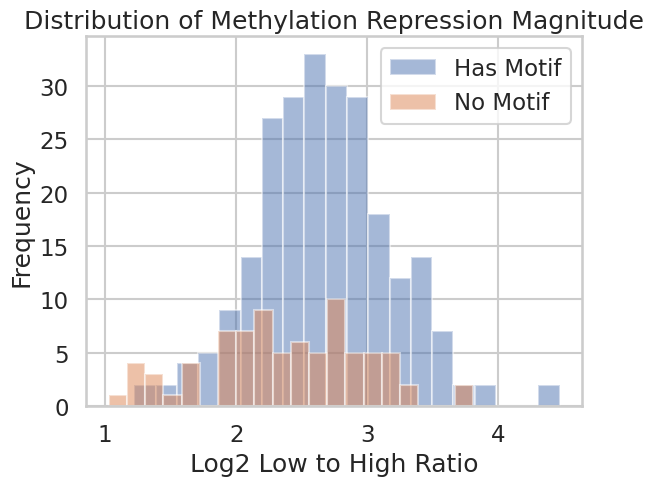

In [71]:
plt.hist(np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), bins=20, alpha=0.5, label='Has Motif')
plt.hist(np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), bins=20, alpha=0.5, label='No Motif')
plt.xlabel('Log2 Low to High Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of Methylation Repression Magnitude')
plt.legend()
plt.show()

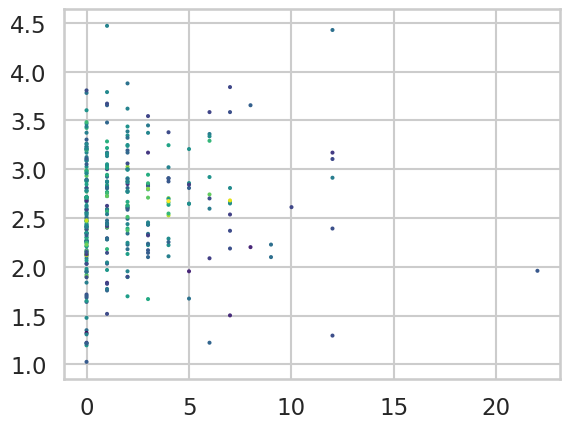

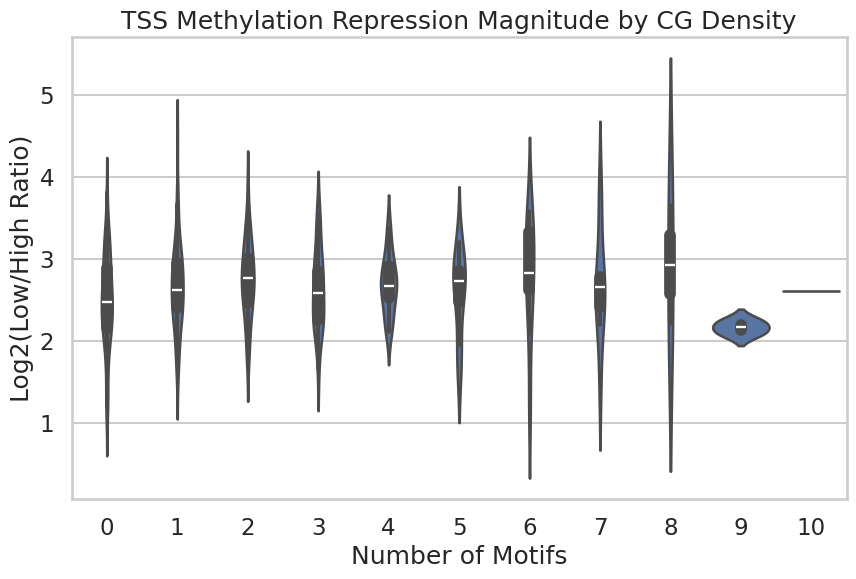

In [73]:
oligos_with_motif_count = (motifmatches_np[:, 940, :]>12).sum(axis=-1) + (motifmatches_rc_np[:, 940, :]>12).sum(axis=-1)

df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

oligo_with_motif_count = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    oligo_index = int(sequence_id.replace("seq", "")) - 1
    has_motif = oligos_with_motif_count[oligo_index]
    oligo_with_motif_count.append(has_motif)
tss_meth_repression_magnitude['Num_Motif'] = oligo_with_motif_count
tss_meth_repression_magnitude.dropna(inplace=True)

plt.scatter(tss_meth_repression_magnitude['Num_Motif'], np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), s=2, c=np.log10(tss_meth_repression_magnitude['0%']+1), cmap='viridis')

# violin plot of low_to_high_ratio for oligos with Num_Motif = 0, 1, 2, 3, 4, 5,6,7,8,9,10
import seaborn as sns
tss_meth_repression_magnitude['Num_Motif_Bin'] = pd.cut(tss_meth_repression_magnitude['Num_Motif'], bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5], labels=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])
plt.figure(figsize=(10, 6))
sns.violinplot(x='Num_Motif_Bin', y=np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), data=tss_meth_repression_magnitude, inner='box')
plt.xlabel('Number of Motifs')
plt.ylabel('Log2(Low/High Ratio)')
plt.title('TSS Methylation Repression Magnitude by CG Density')
plt.show()

## Mafb

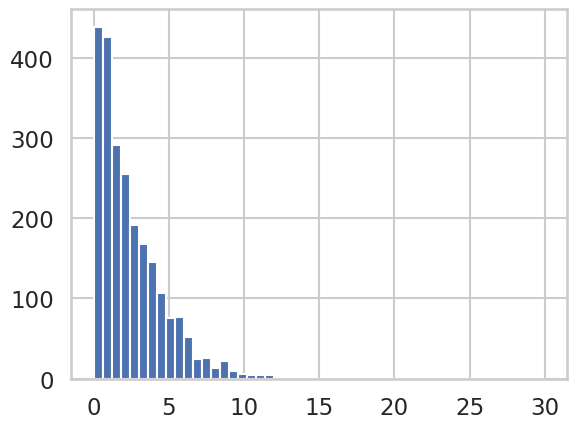

In [94]:
test_motifs = [(84, 'Mafb')]
import matplotlib.pyplot as plt
plt.hist(motifmatches_np[:, 84].flatten(), bins=50, range=(0, 30))
plt.show()

In [95]:
# use cutoff=10
for idx, motif in test_motifs:
    oligos_with_motif = (motifmatches_np[:, idx, :].max(axis=-1)>10) | (motifmatches_rc_np[:, idx, :].max(axis=-1)>10)

    df = filtered_tss_counts_agg.copy()

    df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

    # 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
    df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

    # 3. (Optional) Clean up the resulting DataFrame
    # Reset the index to turn 'Oligo_ID' back into a regular column
    tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

    oligo_with_motif = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        has_motif = oligos_with_motif[oligo_index]
        oligo_with_motif.append(has_motif)
    tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
    tss_meth_repression_magnitude.dropna(inplace=True)

    from scipy.stats import mannwhitneyu

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )
    print(f"Number of oligos with motif {motif}: {tss_meth_repression_magnitude.query('Has_Motif == True').shape[0]} / {tss_meth_repression_magnitude.shape[0]}")
    print(f"Mann-Whitney U statistic: {stat}")
    print(f"P-value: {p_value:.4e}")

Number of oligos with motif Mafb: 24 / 322
Mann-Whitney U statistic: 2198.0
P-value: 1.6918e-03


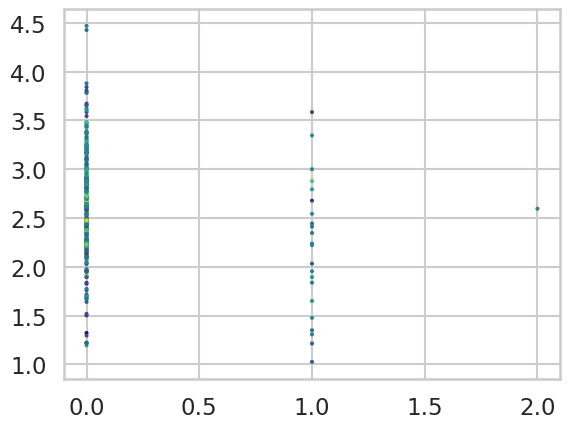

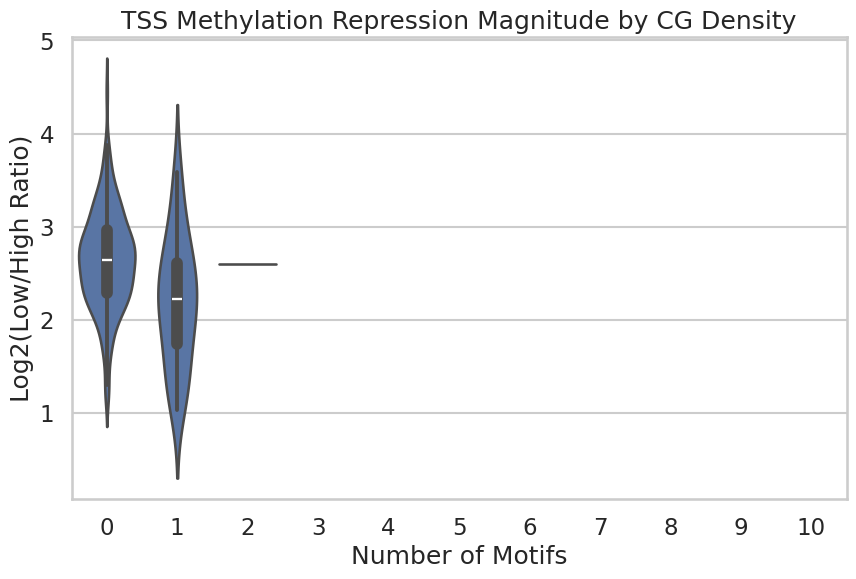

In [96]:
oligos_with_motif_count = (motifmatches_np[:, 84, :]>10).sum(axis=-1) + (motifmatches_rc_np[:, 84, :]>10).sum(axis=-1)

df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

oligo_with_motif_count = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    oligo_index = int(sequence_id.replace("seq", "")) - 1
    has_motif = oligos_with_motif_count[oligo_index]
    oligo_with_motif_count.append(has_motif)
tss_meth_repression_magnitude['Num_Motif'] = oligo_with_motif_count
tss_meth_repression_magnitude.dropna(inplace=True)

plt.scatter(tss_meth_repression_magnitude['Num_Motif'], np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), s=2, c=np.log10(tss_meth_repression_magnitude['0%']+1), cmap='viridis')

# violin plot of low_to_high_ratio for oligos with Num_Motif = 0, 1, 2, 3, 4, 5,6,7,8,9,10
import seaborn as sns
tss_meth_repression_magnitude['Num_Motif_Bin'] = pd.cut(tss_meth_repression_magnitude['Num_Motif'], bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5], labels=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])
plt.figure(figsize=(10, 6))
sns.violinplot(x='Num_Motif_Bin', y=np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), data=tss_meth_repression_magnitude, inner='box')
plt.xlabel('Number of Motifs')
plt.ylabel('Log2(Low/High Ratio)')
plt.title('TSS Methylation Repression Magnitude by CG Density')
plt.show()

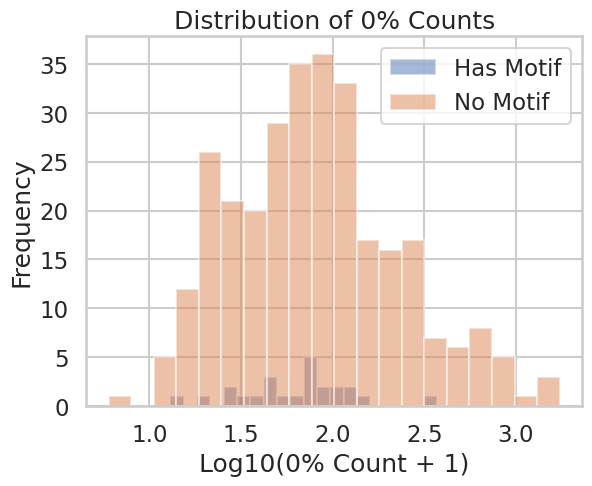

In [98]:
plt.hist(np.log10(tss_meth_repression_magnitude.query("Num_Motif > 0")['0%']+1), bins=20, alpha=0.5, label='Has Motif')
plt.hist(np.log10(tss_meth_repression_magnitude.query("Num_Motif == 0")['0%']+1), bins=20, alpha=0.5, label='No Motif')
plt.xlabel('Log10(0% Count + 1)')
plt.ylabel('Frequency')
plt.title('Distribution of 0% Counts')
plt.legend()
plt.show()

## Gli1

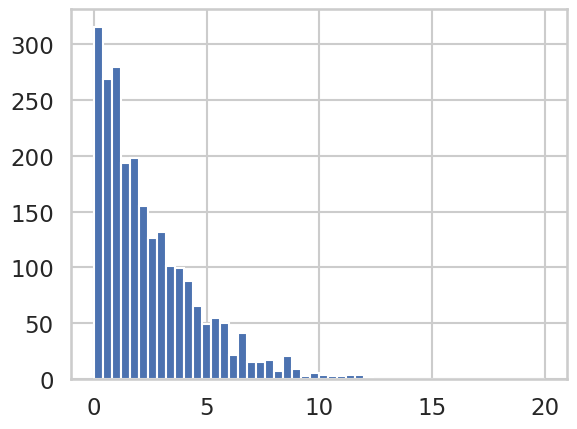

In [100]:
test_motifs = [(827, 'Gli1')]
import matplotlib.pyplot as plt
plt.hist(motifmatches_np[:, 84].flatten(), bins=50, range=(0, 20))
plt.show()

In [108]:
# use cutoff=10
for idx, motif in test_motifs:
    oligos_with_motif = (motifmatches_np[:, idx, :].max(axis=-1)>10) | (motifmatches_rc_np[:, idx, :].max(axis=-1)>10)

    df = filtered_tss_counts_agg.copy()

    df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

    # 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
    df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

    # 3. (Optional) Clean up the resulting DataFrame
    # Reset the index to turn 'Oligo_ID' back into a regular column
    tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

    oligo_with_motif = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        has_motif = oligos_with_motif[oligo_index]
        oligo_with_motif.append(has_motif)
    tss_meth_repression_magnitude['Has_Motif'] = oligo_with_motif
    tss_meth_repression_magnitude.dropna(inplace=True)

    from scipy.stats import mannwhitneyu

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == True")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Has_Motif == False")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )
    print(f"Number of oligos with motif {motif}: {tss_meth_repression_magnitude.query('Has_Motif == True').shape[0]} / {tss_meth_repression_magnitude.shape[0]}")
    print(f"Mann-Whitney U statistic: {stat}")
    print(f"P-value: {p_value:.4e}")

Number of oligos with motif Gli1: 41 / 322
Mann-Whitney U statistic: 4029.5
P-value: 1.8863e-03


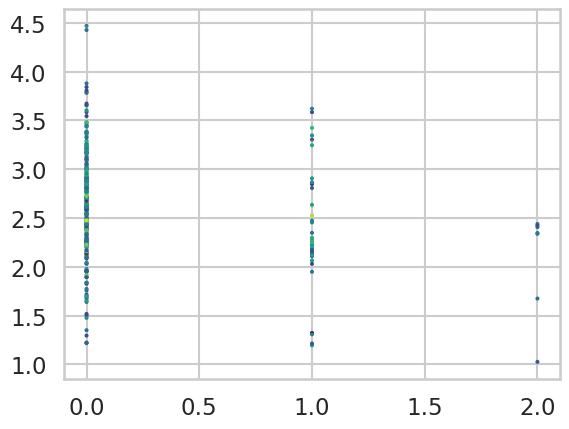

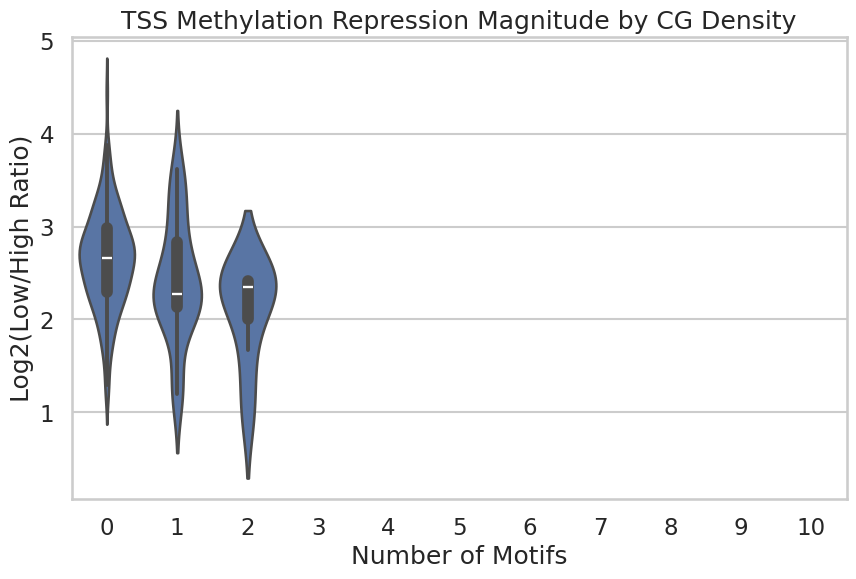

In [109]:
oligos_with_motif_count = (motifmatches_np[:, 827, :]>10).sum(axis=-1) + (motifmatches_rc_np[:, 827, :]>10).sum(axis=-1)

df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

oligo_with_motif_count = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    oligo_index = int(sequence_id.replace("seq", "")) - 1
    has_motif = oligos_with_motif_count[oligo_index]
    oligo_with_motif_count.append(has_motif)
tss_meth_repression_magnitude['Num_Motif'] = oligo_with_motif_count
tss_meth_repression_magnitude.dropna(inplace=True)

plt.scatter(tss_meth_repression_magnitude['Num_Motif'], np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), s=2, c=np.log10(tss_meth_repression_magnitude['0%']+1), cmap='viridis')

# violin plot of low_to_high_ratio for oligos with Num_Motif = 0, 1, 2, 3, 4, 5,6,7,8,9,10
import seaborn as sns
tss_meth_repression_magnitude['Num_Motif_Bin'] = pd.cut(tss_meth_repression_magnitude['Num_Motif'], bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5], labels=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])
plt.figure(figsize=(10, 6))
sns.violinplot(x='Num_Motif_Bin', y=np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), data=tss_meth_repression_magnitude, inner='box')
plt.xlabel('Number of Motifs')
plt.ylabel('Log2(Low/High Ratio)')
plt.title('TSS Methylation Repression Magnitude by CG Density')
plt.show()

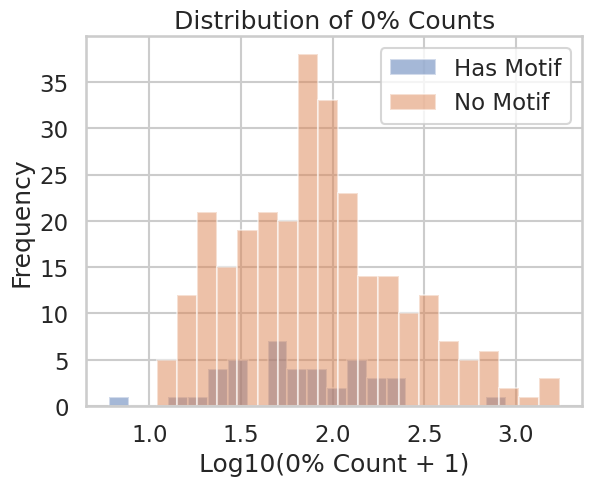

In [110]:
plt.hist(np.log10(tss_meth_repression_magnitude.query("Num_Motif > 0")['0%']+1), bins=20, alpha=0.5, label='Has Motif')
plt.hist(np.log10(tss_meth_repression_magnitude.query("Num_Motif == 0")['0%']+1), bins=20, alpha=0.5, label='No Motif')
plt.xlabel('Log10(0% Count + 1)')
plt.ylabel('Frequency')
plt.title('Distribution of 0% Counts')
plt.legend()
plt.show()

## number of NRF

In [158]:
import numpy as np
from scipy.ndimage import binary_closing

# 1. Extract the boolean masks 
fwd_mask = motifmatches_np[:, 168, :] > 10
rev_mask = motifmatches_rc_np[:, 168, :] > 10

# 2. Combine them (forward OR backward)
all_matches = fwd_mask | rev_mask

# 3. Bridge gaps of 10 bp or less
merge_window = np.ones((1, 11), dtype=bool)
merged_matches = binary_closing(all_matches, structure=merge_window)

# 4. Count matches per sequence natively in NumPy
# Pad the left side with False so a match at position 0 is correctly recognized as a new start
padded_matches = np.pad(merged_matches, ((0, 0), (1, 0)), mode='constant', constant_values=False)

# A new match event starts wherever the current position is True and the previous was False
match_starts = padded_matches[:, 1:] & ~padded_matches[:, :-1]

# Sum these "start flags" across the sequence axis (axis 1)
counts_per_sequence = np.sum(match_starts, axis=1)

# Result: A 1D array where counts_per_sequence[i] is the number of valid match events in sequence i
print(f"Counts for the first 10 sequences: {counts_per_sequence[:10]}")
print(f"Total sequences with AT LEAST one match: {np.sum(counts_per_sequence > 0)}")

Counts for the first 10 sequences: [1 1 0 0 0 0 0 0 1 1]
Total sequences with AT LEAST one match: 280


In [159]:
# count once when motifmatches_np and motifmatches_rc_np both have matches within 10 bp window


# oligos_with_motif_count = (motifmatches_np[:, 168, :]>10).sum(axis=-1) + (motifmatches_rc_np[:, 168, :]>10).sum(axis=-1)
oligos_with_motif_count = counts_per_sequence

In [160]:
df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

oligo_with_motif_count = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    oligo_index = int(sequence_id.replace("seq", "")) - 1
    has_motif = oligos_with_motif_count[oligo_index]
    oligo_with_motif_count.append(has_motif)
tss_meth_repression_magnitude['Num_Motif'] = oligo_with_motif_count
tss_meth_repression_magnitude.dropna(inplace=True)

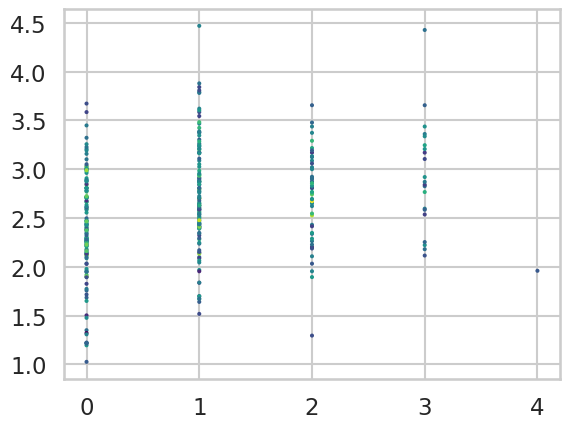

In [161]:
plt.scatter(tss_meth_repression_magnitude['Num_Motif'], np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), s=2, c=np.log10(tss_meth_repression_magnitude['0%']+1), cmap='viridis')

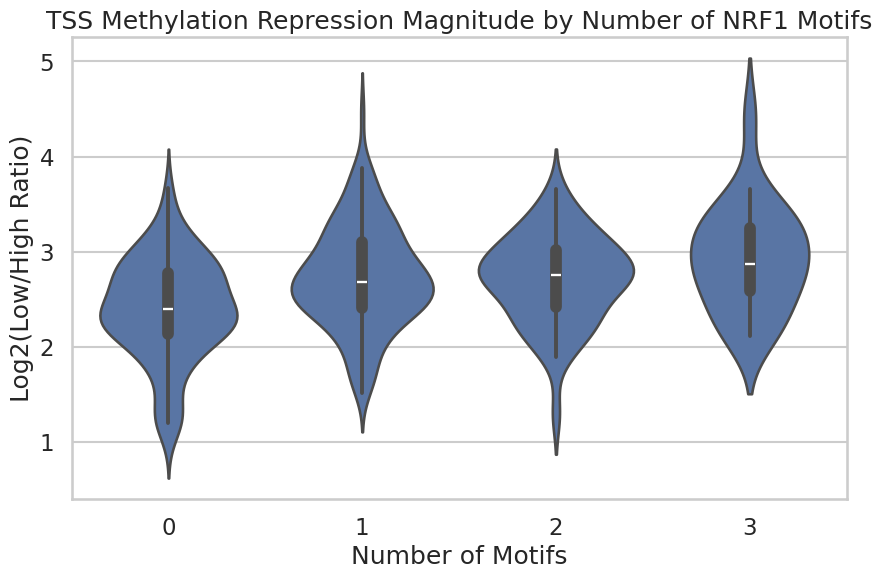

In [164]:
# violin plot of low_to_high_ratio for oligos with Num_Motif = 0, 1, 2, 3
import seaborn as sns
tss_meth_repression_magnitude['Num_Motif_Bin'] = pd.cut(tss_meth_repression_magnitude['Num_Motif'], bins=[-0.5, 0.5, 1.5, 2.5, 3.5], labels=['0', '1', '2', '3'])
plt.figure(figsize=(10, 6))
sns.violinplot(x='Num_Motif_Bin', y=np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), data=tss_meth_repression_magnitude, inner='box')
plt.xlabel('Number of Motifs')
plt.ylabel('Log2(Low/High Ratio)')
plt.title('TSS Methylation Repression Magnitude by Number of NRF1 Motifs')
plt.show()

In [163]:
stat, p_value = mannwhitneyu(
    np.log2(tss_meth_repression_magnitude.query("Num_Motif > 0")['low_to_high_ratio']), 
    np.log2(tss_meth_repression_magnitude.query("Num_Motif == 0")['low_to_high_ratio']), 
    alternative='two-sided', 
    nan_policy='omit'
)
print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value:.4e}")

Mann-Whitney U statistic: 16702.5
P-value: 1.5838e-07


In [138]:
# fit a linear regression model for log2(low_to_medium_ratio) ~ CpG_Count
import statsmodels.api as sm
X = tss_meth_repression_magnitude['Num_Motif']
y = np.log2(tss_meth_repression_magnitude['low_to_high_ratio'])
X = sm.add_constant(X)  # Adds a constant term to the predictor
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      low_to_high_ratio   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     25.16
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           8.75e-07
Time:                        15:04:44   Log-Likelihood:                -254.79
No. Observations:                 322   AIC:                             513.6
Df Residuals:                     320   BIC:                             521.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4613      0.042     58.810      0.0

In [139]:
tss_meth_repression_magnitude.query("Num_Motif == 2")

Meth_State,Oligo_ID,0%,0.1%,60%,100%,low_to_high_ratio,Num_Motif,Num_Motif_Bin
0,CRISPer-promoters:12_SOCS1_chr16_11256199_-:ACGGGAGCGG,10.0,13.0,4.0,1.0,4.600000,2,2
6,CRISPer-promoters:2_C1orf63_chr1_25247453_-:TGACGAGTGT,14.0,31.0,3.0,2.0,9.000000,2,2
7,CRISPer-promoters:2_C1orf63_chr1_25247453_-:TTGCAGAGCA,53.0,38.0,5.0,13.0,5.055556,2,2
10,CRISPer-promoters:4_RBM4_chr11_66616629_+:CCACTGAAGC,76.0,79.0,20.0,20.0,3.875000,2,2
11,CRISPer-promoters:4_RBM4_chr11_66616629_+:GTCGATTACC,126.0,138.0,20.0,51.0,3.718310,2,2
12,CRISPer-promoters:5_IRF1_chr5_132490772_-:ACGGAGCTGA,23.0,18.0,6.0,3.0,4.555556,2,2
13,CRISPer-promoters:6_TMED9_chr5_177592202_+:GACTGCACTT,27.0,39.0,4.0,5.0,7.333333,2,2
14,CRISPer-promoters:6_TMED9_chr5_177592202_+:TCTTGCTCAC,73.0,73.0,12.0,6.0,8.111111,2,2
27,NativeTSS:1613:TCGGGCGAGA,255.0,285.0,47.0,38.0,6.352941,2,2
53,NativeTSS:2723:TGGAGGAACG,101.0,102.0,13.0,15.0,7.250000,2,2


In [143]:
oligo_to_chrom['NativeTSS:2723:TGGAGGAACG']

'seq142'

In [148]:
motifmatches_np[141, 168, 90:150].max()

np.float32(12.288619)

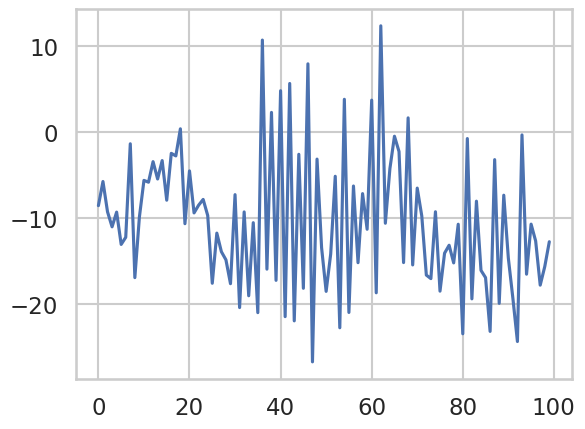

In [ ]:
plt.plot(motifmatches_np[141, 168, 50:150])

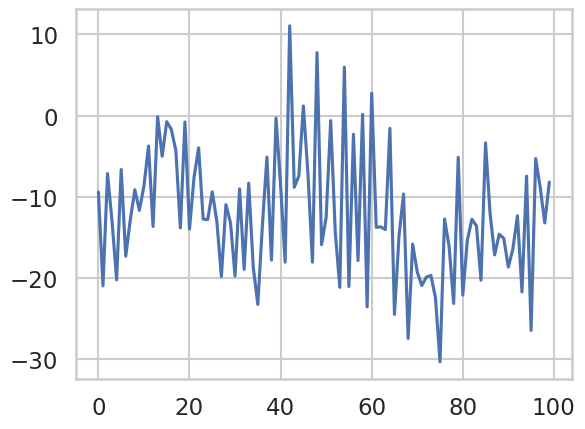

In [101]:
plt.plot(motifmatches_rc_np[184, 168, 150:250])

In [92]:
from Bio import Align

# Initialize the aligner
aligner = Align.PairwiseAligner()

# Configure the scoring parameters
aligner.mode = 'global' # or 'local'
aligner.match_score = 2
aligner.mismatch_score = -1
aligner.open_gap_score = -2
aligner.extend_gap_score = -0.5

# Define the sequences
seq1 = "GAATGGCTGCGCCCAGCGCGCGCTCTCATTTGAATGCGTGAGCGTTCAGAGCACTGGCCAATAGAGAGGAGCGGTGGCTGCGCTTCTTTCCCGGTGGATTACTGTGGGCCAATCACAATCTTCCCCAGACAGGGGGCGGAGCCACGCCAACAGTCAGAGGTCGCGCAGGCGCTGGTACCCCGTTGGTCCGCGCGTTGCTGCGTTGTGAGGGGTGTCAGCTCAGGTAAGCAAGGAGAGTAT"
seq2 = "GAATGGCTGCGCCCAGCGCGCGCTCTCATTTGAATGCGTGAGCGTTCAGAGCACTGGCCAATAGAGAGGAGCGGTGGCTGCGCTTCTTTCCCGGTGGATTACTGTCGGGAGGGTGCAATCTTCCCCAGACAGGGGGCGGAGCCACGCCAACAGTCAGAGGTCGCGCAGGCGCTGGTACCCCGTTGGTCCGCGCGTTGCTGCGTTGTGAGGGGTGTCAGCTCAGGTAAGCAAGGAGAGTAT"

# Perform the alignment
alignments = aligner.align(seq1, seq2)

# Extract and print the best alignment
best_alignment = alignments[0]
print("Alignment Score:", best_alignment.score)
print(best_alignment)

Alignment Score: 459.0
target            0 GAATGGCTGCGCCCAGCGCGCGCTCTCATTTGAATGCGTGAGCGTTCAGAGCACTGGCCA
                  0 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query             0 GAATGGCTGCGCCCAGCGCGCGCTCTCATTTGAATGCGTGAGCGTTCAGAGCACTGGCCA

target           60 ATAGAGAGGAGCGGTGGCTGCGCTTCTTTCCCGGTGGATTACTGT-GGGCCAATCACAAT
                 60 |||||||||||||||||||||||||||||||||||||||||||||-|||....|-.||||
query            60 ATAGAGAGGAGCGGTGGCTGCGCTTCTTTCCCGGTGGATTACTGTCGGGAGGGT-GCAAT

target          119 CTTCCCCAGACAGGGGGCGGAGCCACGCCAACAGTCAGAGGTCGCGCAGGCGCTGGTACC
                120 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           119 CTTCCCCAGACAGGGGGCGGAGCCACGCCAACAGTCAGAGGTCGCGCAGGCGCTGGTACC

target          179 CCGTTGGTCCGCGCGTTGCTGCGTTGTGAGGGGTGTCAGCTCAGGTAAGCAAGGAGAGTA
                180 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           179 CCGTTGGTCCGCGCGTTGCTGCGTTGTGAGGGGTGTCAGCTCAGGTAAGCAAGGAGAGTA

t

# Test GC content versus repression magnitude

In [197]:
oligo_gc_content = pd.read_csv("./intermediate_data/oligo500_gc.tsv", sep='\t', header=None, names=['Oligo_ID', 'GC_Content'])

In [200]:
df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

oligo_gc = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    oligo_index = int(sequence_id.replace("seq", "")) - 1
    gc_content = oligo_gc_content.loc[oligo_gc_content['Oligo_ID'] == sequence_id, 'GC_Content'].values[0]
    oligo_gc.append(gc_content)
tss_meth_repression_magnitude['GC_Content'] = oligo_gc
tss_meth_repression_magnitude.dropna(inplace=True)

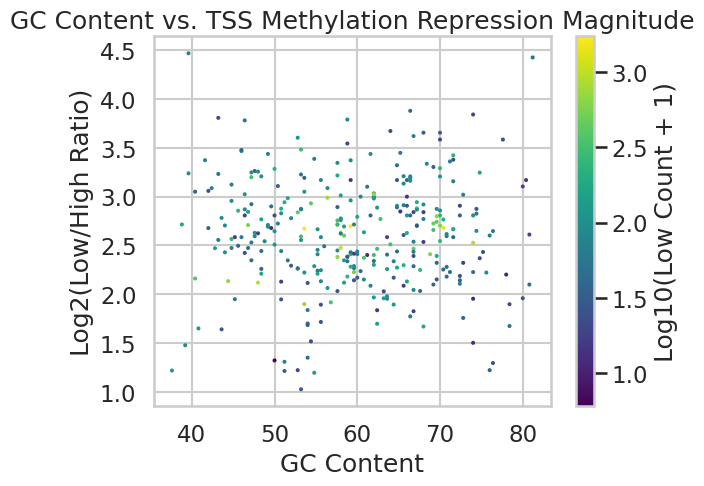

In [203]:
plt.scatter(tss_meth_repression_magnitude['GC_Content'], np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), s=2, c=np.log10(tss_meth_repression_magnitude['0%']+1), cmap='viridis')
plt.xlabel('GC Content')
plt.ylabel('Log2(Low/High Ratio)')
plt.title('GC Content vs. TSS Methylation Repression Magnitude')
plt.colorbar(label='Log10(Low Count + 1)')
plt.show()

# Test CGCG motif

In [204]:
import sys
import re
from Bio import SeqIO

def count_cgcg_motifs(fasta_path):
    motif = "CGCG"
    
    # Create the regex pattern for overlapping matches using a "lookahead" (?=...)
    # This allows the regex engine to find a match without consuming the characters,
    # meaning it can start the next search inside the previous match.
    overlap_pattern = re.compile(rf'(?={motif})')

    counts = []
    for record in SeqIO.parse(fasta_path, "fasta"):
        # Convert the sequence object to a standard string and make it uppercase
        seq_str = str(record.seq).upper()
        
        # 1. Non-Overlapping Count (Standard string method)
        non_overlap_count = seq_str.count(motif)
        
        # # 2. Overlapping Count (Regex lookahead method)
        # overlap_count = len(overlap_pattern.findall(seq_str))
        
        counts.append(non_overlap_count)
    return counts

cgcg_counts = count_cgcg_motifs('/gpfs/data/zhou-lab/dcai/059_DT/1_meCpG_STAP/data_500/data_500.fa')

In [216]:
df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

cgcg_count = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    oligo_index = int(sequence_id.replace("seq", "")) - 1
    gc_content = cgcg_counts[oligo_index]
    cgcg_count.append(gc_content)
tss_meth_repression_magnitude['CGCG_Count'] = cgcg_count
tss_meth_repression_magnitude.dropna(inplace=True)

In [217]:
tss_meth_repression_magnitude

Meth_State,Oligo_ID,0%,0.1%,60%,100%,low_to_high_ratio,CGCG_Count
0,CRISPer-promoters:12_SOCS1_chr16_11256199_-:ACGGGAGCGG,10.0,13.0,4.0,1.0,4.600000,3
1,CRISPer-promoters:13_C19orf43_chr19_12734681_-:GATAACCTAC,11.0,6.0,3.0,3.0,2.833333,4
2,CRISPer-promoters:13_C19orf43_chr19_12734681_-:GGCATCTGAC,21.0,10.0,3.0,3.0,5.166667,3
3,CRISPer-promoters:15_ECI1_chr16_2251586_-:AACTCAAGCC,32.0,38.0,6.0,4.0,7.000000,4
4,CRISPer-promoters:16_LETMD1_chr12_51048326_+:GAGTCAGGGA,107.0,80.0,14.0,10.0,7.791667,1
...,...,...,...,...,...,...,...
325,promoter_design:tss8_generated_1:TCTACCGCCG,87.0,67.0,4.0,17.0,7.333333,1
326,promoter_design:tss8_generated_2:GGCATAATGC,47.0,55.0,6.0,15.0,4.857143,1
327,promoter_design:tss8_generated_3:GTACGCGTCG,83.0,101.0,21.0,9.0,6.133333,3
328,promoter_design:tss8_real:TCGCAAGGTA,36.0,44.0,8.0,8.0,5.000000,2


In [218]:
stat, p_value = mannwhitneyu(
    np.log2(tss_meth_repression_magnitude.query("CGCG_Count == 0")['low_to_high_ratio']), 
    np.log2(tss_meth_repression_magnitude.query("CGCG_Count > 0")['low_to_high_ratio']), 
    alternative='two-sided', 
    nan_policy='omit'
)
print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value:.4e}")

Mann-Whitney U statistic: 8520.0
P-value: 2.3210e-03


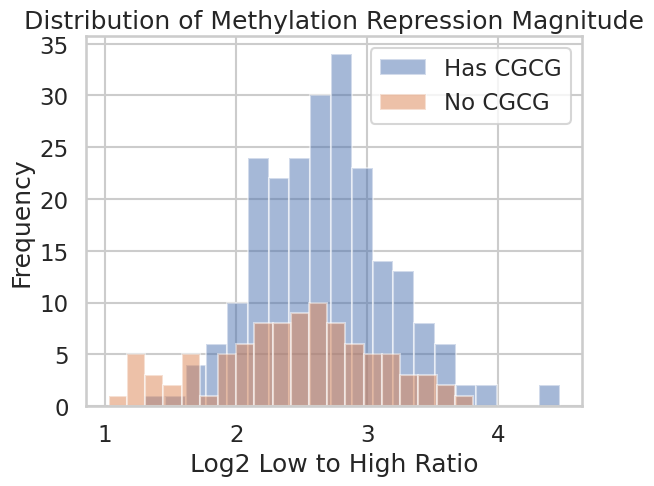

In [220]:
plt.hist(np.log2(tss_meth_repression_magnitude.query("CGCG_Count > 0")['low_to_high_ratio']), bins=20, alpha=0.5, label='Has CGCG')
plt.hist(np.log2(tss_meth_repression_magnitude.query("CGCG_Count == 0")['low_to_high_ratio']), bins=20, alpha=0.5, label='No CGCG')
plt.xlabel('Log2 Low to High Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of Methylation Repression Magnitude')
plt.legend()
plt.show()

In [222]:
stat, p_value = mannwhitneyu(
    np.log2(tss_meth_repression_magnitude.query("CGCG_Count == 0")['0%']+1), 
    np.log2(tss_meth_repression_magnitude.query("CGCG_Count > 0")['0%']+1), 
    alternative='two-sided', 
    nan_policy='omit'
)
print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value:.4e}")

Mann-Whitney U statistic: 10650.5
P-value: 7.9656e-01


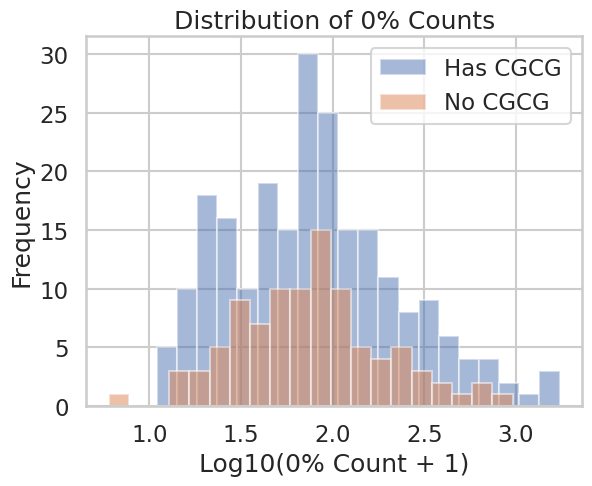

In [221]:
plt.hist(np.log10(tss_meth_repression_magnitude.query("CGCG_Count > 0")['0%']+1), bins=20, alpha=0.5, label='Has CGCG')
plt.hist(np.log10(tss_meth_repression_magnitude.query("CGCG_Count == 0")['0%']+1), bins=20, alpha=0.5, label='No CGCG')
plt.xlabel('Log10(0% Count + 1)')
plt.ylabel('Frequency')
plt.title('Distribution of 0% Counts')
plt.legend()
plt.show()

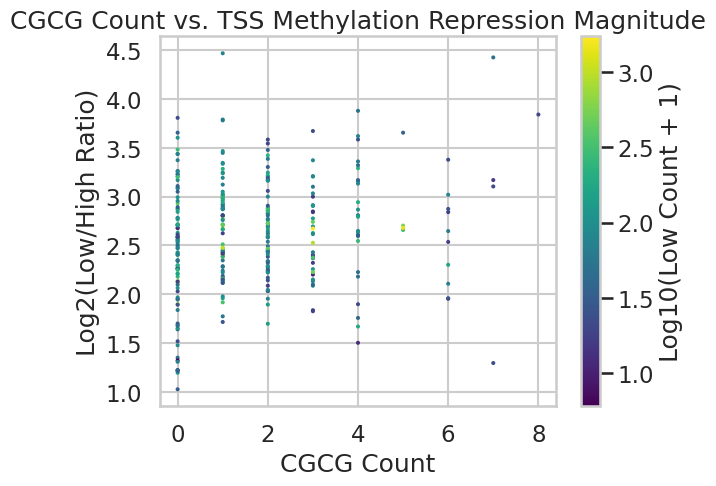

In [223]:
plt.scatter(tss_meth_repression_magnitude['CGCG_Count'], np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), s=2, c=np.log10(tss_meth_repression_magnitude['0%']+1), cmap='viridis')
plt.xlabel('CGCG Count')
plt.ylabel('Log2(Low/High Ratio)')
plt.title('CGCG Count vs. TSS Methylation Repression Magnitude')
plt.colorbar(label='Log10(Low Count + 1)')
plt.show()

# Test GCGC motif

In [27]:
import sys
import re
from Bio import SeqIO

def count_motifs(fasta_path, motif):
    
    # Create the regex pattern for overlapping matches using a "lookahead" (?=...)
    # This allows the regex engine to find a match without consuming the characters,
    # meaning it can start the next search inside the previous match.
    overlap_pattern = re.compile(rf'(?={motif})')

    counts = []
    for record in SeqIO.parse(fasta_path, "fasta"):
        # Convert the sequence object to a standard string and make it uppercase
        seq_str = str(record.seq).upper()
        
        # 1. Non-Overlapping Count (Standard string method)
        non_overlap_count = seq_str.count(motif)
        
        # # 2. Overlapping Count (Regex lookahead method)
        # overlap_count = len(overlap_pattern.findall(seq_str))
        
        counts.append(non_overlap_count)
    return counts

motif_counts = count_motifs('/gpfs/data/zhou-lab/dcai/059_DT/1_meCpG_STAP/data_500/data_500.fa', 'GCGC')

In [8]:
df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

motif_count = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    oligo_index = int(sequence_id.replace("seq", "")) - 1
    gc_content = motif_counts[oligo_index]
    motif_count.append(gc_content)
tss_meth_repression_magnitude['Motif_Count'] = motif_count
tss_meth_repression_magnitude.dropna(inplace=True)

In [10]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    np.log2(tss_meth_repression_magnitude.query("Motif_Count == 0")['low_to_high_ratio']), 
    np.log2(tss_meth_repression_magnitude.query("Motif_Count > 0")['low_to_high_ratio']), 
    alternative='two-sided', 
    nan_policy='omit'
)
print(f"Has Motif Count > 0: {tss_meth_repression_magnitude.query('Motif_Count > 0').shape[0]} / {tss_meth_repression_magnitude.shape[0]}")
print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value:.4e}")

Has Motif Count > 0: 272 / 322
Mann-Whitney U statistic: 4346.0
P-value: 5.0092e-05


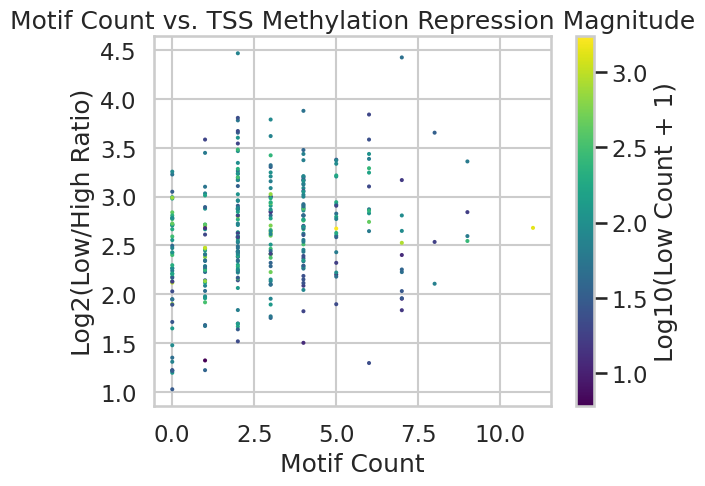

In [11]:
plt.scatter(tss_meth_repression_magnitude['Motif_Count'], np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), s=2, c=np.log10(tss_meth_repression_magnitude['0%']+1), cmap='viridis')
plt.xlabel('Motif Count')
plt.ylabel('Log2(Low/High Ratio)')
plt.title('Motif Count vs. TSS Methylation Repression Magnitude')
plt.colorbar(label='Log10(Low Count + 1)')
plt.show()

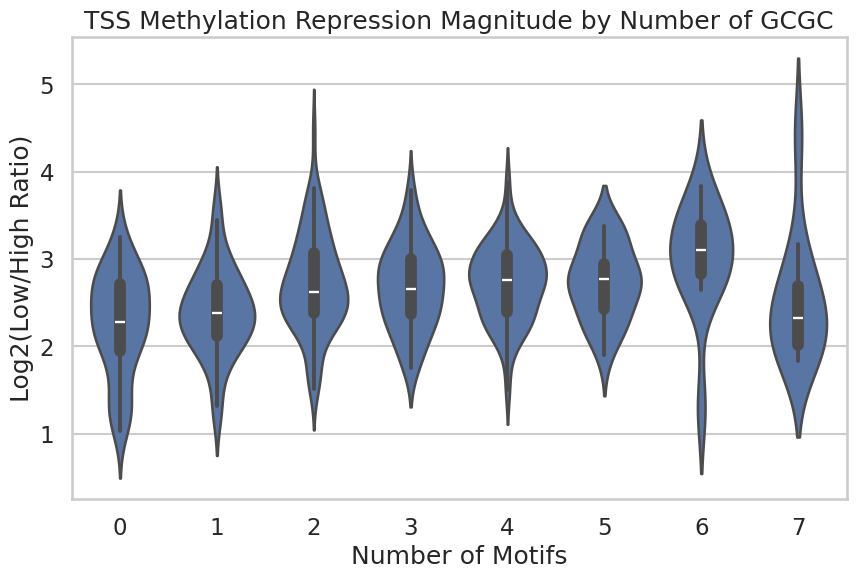

In [14]:
# violin plot of low_to_high_ratio for oligos with Motif_Count = 0, 1, 2, 3, 4, 5, 6, 7
import seaborn as sns
tss_meth_repression_magnitude['Motif_Count_Bin'] = pd.cut(tss_meth_repression_magnitude['Motif_Count'], bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5], labels=['0', '1', '2', '3', '4', '5', '6', '7'])
plt.figure(figsize=(10, 6))
sns.violinplot(x='Motif_Count_Bin', y=np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), data=tss_meth_repression_magnitude, inner='box')
plt.xlabel('Number of Motifs')
plt.ylabel('Log2(Low/High Ratio)')
plt.title('TSS Methylation Repression Magnitude by Number of GCGC')
plt.show()

In [13]:
# fit a linear regression model for log2(low_to_medium_ratio) ~ CpG_Count
import statsmodels.api as sm
X = tss_meth_repression_magnitude['Motif_Count']
y = np.log2(tss_meth_repression_magnitude['low_to_high_ratio'])
X = sm.add_constant(X)  # Adds a constant term to the predictor
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      low_to_high_ratio   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     21.17
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           6.08e-06
Time:                        22:33:25   Log-Likelihood:                -256.66
No. Observations:                 322   AIC:                             517.3
Df Residuals:                     320   BIC:                             524.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.4254      0.050     48.649      

In [184]:
test_motifs = []
for c1 in ['A', 'C', 'G', 'T']:
    for c2 in ['A', 'C', 'G', 'T']:
        test_motifs.append(c1+"CG"+c2)
print(test_motifs)

['ACGA', 'ACGC', 'ACGG', 'ACGT', 'CCGA', 'CCGC', 'CCGG', 'CCGT', 'GCGA', 'GCGC', 'GCGG', 'GCGT', 'TCGA', 'TCGC', 'TCGG', 'TCGT']


In [190]:
for motif in test_motifs:
    motif_counts = count_motifs('/gpfs/data/zhou-lab/dcai/059_DT/1_meCpG_STAP/data_500/data_500.fa', motif)

    motif_count = []
    for oligo in tss_meth_repression_magnitude['Oligo_ID']:
        sequence_id = oligo_to_chrom.get(oligo)
        oligo_index = int(sequence_id.replace("seq", "")) - 1
        gc_content = motif_counts[oligo_index]
        motif_count.append(gc_content)
    tss_meth_repression_magnitude['Motif_Count'] = motif_count
    tss_meth_repression_magnitude.dropna(inplace=True)

    stat, p_value = mannwhitneyu(
        np.log2(tss_meth_repression_magnitude.query("Motif_Count == 0")['low_to_high_ratio']), 
        np.log2(tss_meth_repression_magnitude.query("Motif_Count > 0")['low_to_high_ratio']), 
        alternative='two-sided', 
        nan_policy='omit'
    )
    print(f"Has Motif Count > 0: {tss_meth_repression_magnitude.query('Motif_Count > 0').shape[0]} / {tss_meth_repression_magnitude.shape[0]}")
    print(f"Motif: {motif}, Mann-Whitney U statistic: {stat}, P-value: {p_value:.4e}")

Has Motif Count > 0: 87 / 322
Motif: ACGA, Mann-Whitney U statistic: 11130.5, P-value: 2.2120e-01
Has Motif Count > 0: 146 / 322
Motif: ACGC, Mann-Whitney U statistic: 12803.5, P-value: 9.5781e-01
Has Motif Count > 0: 144 / 322
Motif: ACGG, Mann-Whitney U statistic: 14405.5, P-value: 5.5741e-02
Has Motif Count > 0: 166 / 322
Motif: ACGT, Mann-Whitney U statistic: 11348.0, P-value: 5.5383e-02
Has Motif Count > 0: 180 / 322
Motif: CCGA, Mann-Whitney U statistic: 12293.0, P-value: 5.5751e-01
Has Motif Count > 0: 220 / 322
Motif: CCGC, Mann-Whitney U statistic: 11562.0, P-value: 6.6036e-01
Has Motif Count > 0: 294 / 322
Motif: CCGG, Mann-Whitney U statistic: 4171.5, P-value: 9.0698e-01
Has Motif Count > 0: 166 / 322
Motif: CCGT, Mann-Whitney U statistic: 12292.0, P-value: 4.3237e-01
Has Motif Count > 0: 167 / 322
Motif: GCGA, Mann-Whitney U statistic: 12307.5, P-value: 4.4716e-01
Has Motif Count > 0: 272 / 322
Motif: GCGC, Mann-Whitney U statistic: 4346.0, P-value: 5.0092e-05
Has Motif Cou

## overlaps with NRF1

In [25]:
import numpy as np
from scipy.ndimage import binary_closing

# 1. Extract the boolean masks 
fwd_mask = motifmatches_np[:, 168, :] > 10
rev_mask = motifmatches_rc_np[:, 168, :] > 10

# 2. Combine them (forward OR backward)
all_matches = fwd_mask | rev_mask

# 3. Bridge gaps of 10 bp or less
merge_window = np.ones((1, 11), dtype=bool)
merged_matches = binary_closing(all_matches, structure=merge_window)

# 4. Count matches per sequence natively in NumPy
# Pad the left side with False so a match at position 0 is correctly recognized as a new start
padded_matches = np.pad(merged_matches, ((0, 0), (1, 0)), mode='constant', constant_values=False)

# A new match event starts wherever the current position is True and the previous was False
match_starts = padded_matches[:, 1:] & ~padded_matches[:, :-1]

# Sum these "start flags" across the sequence axis (axis 1)
counts_per_sequence = np.sum(match_starts, axis=1)

# Result: A 1D array where counts_per_sequence[i] is the number of valid match events in sequence i
print(f"Counts for the first 10 sequences: {counts_per_sequence[:10]}")
print(f"Total sequences with AT LEAST one match: {np.sum(counts_per_sequence > 0)}")

oligos_with_motif_count = counts_per_sequence

df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

oligo_with_motif_count = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    oligo_index = int(sequence_id.replace("seq", "")) - 1
    has_motif = oligos_with_motif_count[oligo_index]
    oligo_with_motif_count.append(has_motif)
tss_meth_repression_magnitude['Num_NRF'] = oligo_with_motif_count
tss_meth_repression_magnitude.dropna(inplace=True)

Counts for the first 10 sequences: [1 1 0 0 0 0 0 0 1 1]
Total sequences with AT LEAST one match: 280


In [29]:
tss_meth_repression_magnitude

Meth_State,Oligo_ID,0%,0.1%,60%,100%,low_to_high_ratio,Num_NRF,Num_GCGC
0,CRISPer-promoters:12_SOCS1_chr16_11256199_-:ACGGGAGCGG,10.0,13.0,4.0,1.0,4.600000,2,5
1,CRISPer-promoters:13_C19orf43_chr19_12734681_-:GATAACCTAC,11.0,6.0,3.0,3.0,2.833333,0,4
2,CRISPer-promoters:13_C19orf43_chr19_12734681_-:GGCATCTGAC,21.0,10.0,3.0,3.0,5.166667,0,4
3,CRISPer-promoters:15_ECI1_chr16_2251586_-:AACTCAAGCC,32.0,38.0,6.0,4.0,7.000000,0,4
4,CRISPer-promoters:16_LETMD1_chr12_51048326_+:GAGTCAGGGA,107.0,80.0,14.0,10.0,7.791667,0,2
...,...,...,...,...,...,...,...,...
325,promoter_design:tss8_generated_1:TCTACCGCCG,87.0,67.0,4.0,17.0,7.333333,0,2
326,promoter_design:tss8_generated_2:GGCATAATGC,47.0,55.0,6.0,15.0,4.857143,0,1
327,promoter_design:tss8_generated_3:GTACGCGTCG,83.0,101.0,21.0,9.0,6.133333,0,3
328,promoter_design:tss8_real:TCGCAAGGTA,36.0,44.0,8.0,8.0,5.000000,0,3


In [28]:
# count GCGC
motif_count = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    oligo_index = int(sequence_id.replace("seq", "")) - 1
    gc_content = motif_counts[oligo_index]
    motif_count.append(gc_content)
tss_meth_repression_magnitude['Num_GCGC'] = motif_count
tss_meth_repression_magnitude.dropna(inplace=True)

In [31]:
stat, p_value = mannwhitneyu(
    np.log2(tss_meth_repression_magnitude.query("Num_NRF == 0")['low_to_high_ratio']), 
    np.log2(tss_meth_repression_magnitude.query("Num_NRF > 0")['low_to_high_ratio']), 
    alternative='two-sided', 
    nan_policy='omit'
)
print(f"NRF Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value:.4e}")

stat, p_value = mannwhitneyu(
    np.log2(tss_meth_repression_magnitude.query("Num_GCGC == 0")['low_to_high_ratio']), 
    np.log2(tss_meth_repression_magnitude.query("Num_GCGC > 0")['low_to_high_ratio']), 
    alternative='two-sided', 
    nan_policy='omit'
)
print(f"GCGC Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value:.4e}")

NRF Mann-Whitney U statistic: 8129.5
P-value: 1.5838e-07
GCGC Mann-Whitney U statistic: 4346.0
P-value: 5.0092e-05


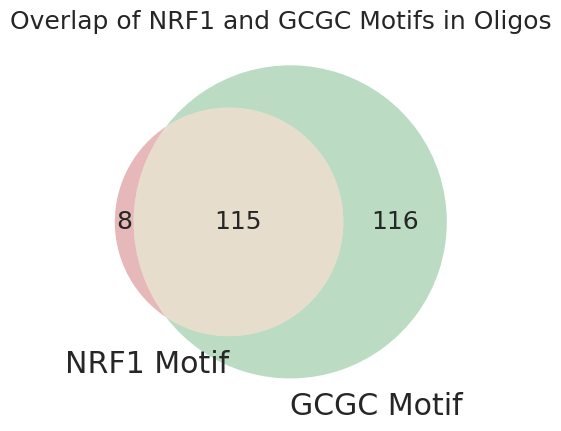

In [59]:
from matplotlib_venn import venn2
nrf = set(tss_meth_repression_magnitude.query("Num_NRF == 1")['Oligo_ID'])
cgcg = set(tss_meth_repression_magnitude.query("Num_GCGC >= 2")['Oligo_ID'])
venn2([nrf, cgcg], set_labels=('NRF1 Motif', 'GCGC Motif'))
plt.title('Overlap of NRF1 and GCGC Motifs in Oligos')
plt.show()

In [65]:
stat, p_value = mannwhitneyu(
    np.log2(tss_meth_repression_magnitude.query("Num_NRF == 0 & Num_GCGC == 0")['low_to_high_ratio']), 
    np.log2(tss_meth_repression_magnitude.query("Num_NRF == 0 & Num_GCGC > 0")['low_to_high_ratio']), 
    alternative='two-sided', 
    nan_policy='omit'
)
print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value:.4e}")

Mann-Whitney U statistic: 1588.0
P-value: 7.7472e-02


In [44]:
stat, p_value = mannwhitneyu(
    np.log2(tss_meth_repression_magnitude.query("Num_NRF == 1")['low_to_high_ratio']), 
    np.log2(tss_meth_repression_magnitude.query("Num_NRF == 0")['low_to_high_ratio']), 
    alternative='two-sided', 
    nan_policy='omit'
)
print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value:.4e}")

Mann-Whitney U statistic: 10447.5
P-value: 7.5232e-06


In [52]:
stat, p_value = mannwhitneyu(
    np.log2(tss_meth_repression_magnitude.query("Num_GCGC == 6")['low_to_high_ratio']), 
    np.log2(tss_meth_repression_magnitude.query("Num_GCGC == 0")['low_to_high_ratio']), 
    alternative='two-sided', 
    nan_policy='omit'
)
print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value:.4e}")

Mann-Whitney U statistic: 555.0
P-value: 9.7045e-05


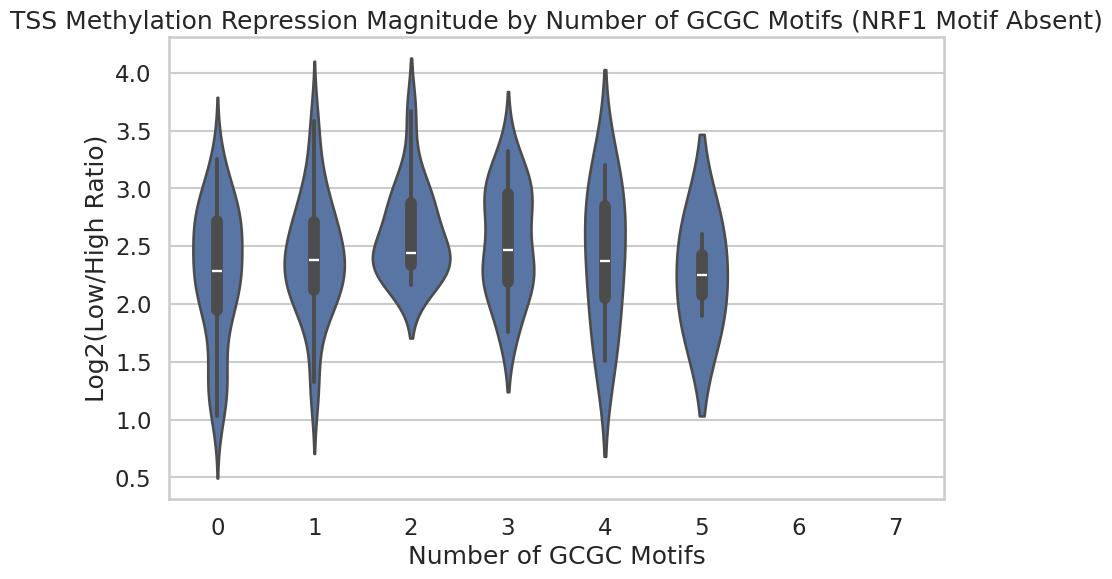

In [38]:
# violin plot of low_to_high_ratio for oligos with Motif_Count = 0, 1, 2, 3, 4, 5, 6, 7
import seaborn as sns
subset = tss_meth_repression_magnitude.query("Num_NRF == 0").copy()
subset['Num_GCGC_Bin'] = pd.cut(subset['Num_GCGC'], bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5], labels=['0', '1', '2', '3', '4', '5', '6', '7'])
plt.figure(figsize=(10, 6))
sns.violinplot(x='Num_GCGC_Bin', y=np.log2(subset['low_to_high_ratio']), data=subset, inner='box')
plt.xlabel('Number of GCGC Motifs')
plt.ylabel('Log2(Low/High Ratio)')
plt.title('TSS Methylation Repression Magnitude by Number of GCGC Motifs (NRF1 Motif Absent)')
plt.show()

# Test CGCGCG motif

In [ ]:
import sys
import re
from Bio import SeqIO

def count_motifs(fasta_path):
    motif = "CGCGCG"
    
    # Create the regex pattern for overlapping matches using a "lookahead" (?=...)
    # This allows the regex engine to find a match without consuming the characters,
    # meaning it can start the next search inside the previous match.
    overlap_pattern = re.compile(rf'(?={motif})')

    counts = []
    for record in SeqIO.parse(fasta_path, "fasta"):
        # Convert the sequence object to a standard string and make it uppercase
        seq_str = str(record.seq).upper()
        
        # 1. Non-Overlapping Count (Standard string method)
        non_overlap_count = seq_str.count(motif)
        
        # # 2. Overlapping Count (Regex lookahead method)
        # overlap_count = len(overlap_pattern.findall(seq_str))
        
        counts.append(non_overlap_count)
    return counts

motif_counts = count_motifs('/gpfs/data/zhou-lab/dcai/059_DT/1_meCpG_STAP/data_500/data_500.fa')

In [225]:
df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

motif_count = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    oligo_index = int(sequence_id.replace("seq", "")) - 1
    gc_content = motif_counts[oligo_index]
    motif_count.append(gc_content)
tss_meth_repression_magnitude['Motif_Count'] = motif_count
tss_meth_repression_magnitude.dropna(inplace=True)

In [226]:
tss_meth_repression_magnitude

Meth_State,Oligo_ID,0%,0.1%,60%,100%,low_to_high_ratio,Motif_Count
0,CRISPer-promoters:12_SOCS1_chr16_11256199_-:ACGGGAGCGG,10.0,13.0,4.0,1.0,4.600000,0
1,CRISPer-promoters:13_C19orf43_chr19_12734681_-:GATAACCTAC,11.0,6.0,3.0,3.0,2.833333,0
2,CRISPer-promoters:13_C19orf43_chr19_12734681_-:GGCATCTGAC,21.0,10.0,3.0,3.0,5.166667,0
3,CRISPer-promoters:15_ECI1_chr16_2251586_-:AACTCAAGCC,32.0,38.0,6.0,4.0,7.000000,3
4,CRISPer-promoters:16_LETMD1_chr12_51048326_+:GAGTCAGGGA,107.0,80.0,14.0,10.0,7.791667,0
...,...,...,...,...,...,...,...
325,promoter_design:tss8_generated_1:TCTACCGCCG,87.0,67.0,4.0,17.0,7.333333,0
326,promoter_design:tss8_generated_2:GGCATAATGC,47.0,55.0,6.0,15.0,4.857143,0
327,promoter_design:tss8_generated_3:GTACGCGTCG,83.0,101.0,21.0,9.0,6.133333,0
328,promoter_design:tss8_real:TCGCAAGGTA,36.0,44.0,8.0,8.0,5.000000,0


In [227]:
stat, p_value = mannwhitneyu(
    np.log2(tss_meth_repression_magnitude.query("Motif_Count == 0")['low_to_high_ratio']), 
    np.log2(tss_meth_repression_magnitude.query("Motif_Count nbh e4rd> 0")['low_to_high_ratio']), 
    alternative='two-sided', 
    nan_policy='omit'
)
print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value:.4e}")

Mann-Whitney U statistic: 5850.5
P-value: 1.1676e-01


# CG density

In [230]:
cg_matches_np = np.load("./intermediate_data/oligo500_cg_screen.npy")

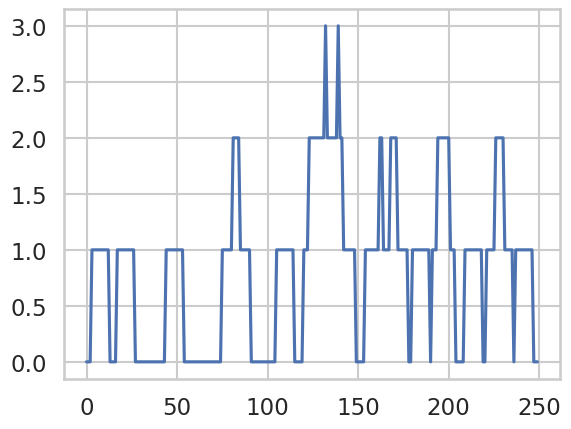

In [252]:
# use sum pooling kernel=5 to smooth the cg count
from scipy.ndimage import uniform_filter1d
cg_count_smoothed = uniform_filter1d(cg_matches_np, size=10, axis=-1)*10/2
plt.plot(cg_count_smoothed[2])

In [253]:
df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

cg_density = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    oligo_index = int(sequence_id.replace("seq", "")) - 1
    cg_density.append(cg_count_smoothed[oligo_index].max())
tss_meth_repression_magnitude['CG_Density'] = cg_density
tss_meth_repression_magnitude.dropna(inplace=True)

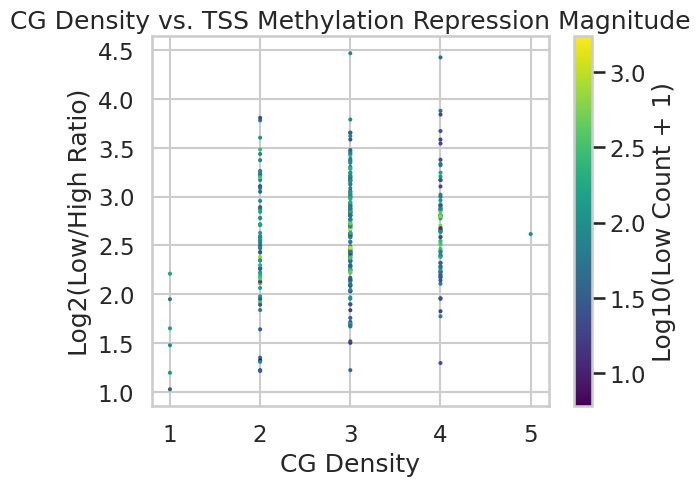

In [254]:
plt.scatter(tss_meth_repression_magnitude['CG_Density'], np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), s=2, c=np.log10(tss_meth_repression_magnitude['0%']+1), cmap='viridis')
plt.xlabel('CG Density')
plt.ylabel('Log2(Low/High Ratio)')
plt.title('CG Density vs. TSS Methylation Repression Magnitude')
plt.colorbar(label='Log10(Low Count + 1)')
plt.show()

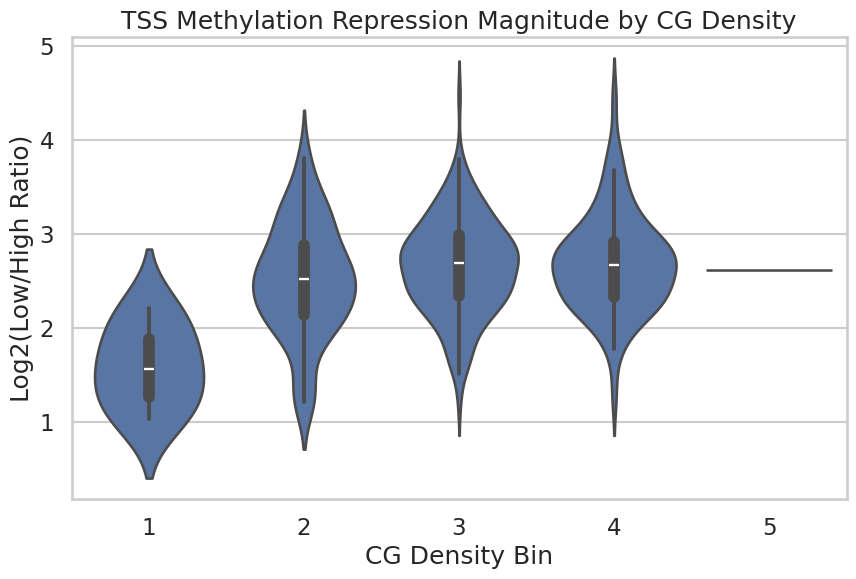

In [250]:
# violin plot of low_to_high_ratio for oligos with CG_Density = 1, 2, 3, 4, 5
import seaborn as sns
tss_meth_repression_magnitude['CG_Density_Bin'] = pd.cut(tss_meth_repression_magnitude['CG_Density'], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], labels=['1', '2', '3', '4', '5'])
plt.figure(figsize=(10, 6))
sns.violinplot(x='CG_Density_Bin', y=np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), data=tss_meth_repression_magnitude, inner='box')
plt.xlabel('CG Density Bin')
plt.ylabel('Log2(Low/High Ratio)')
plt.title('TSS Methylation Repression Magnitude by CG Density')
plt.show()

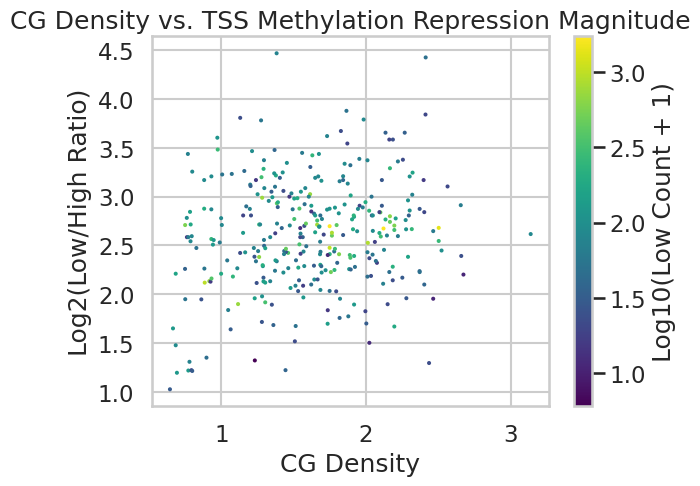

In [262]:
# use sum pooling kernel=5 to smooth the cg count
from scipy.ndimage import gaussian_filter1d
cg_count_smoothed = gaussian_filter1d(cg_matches_np, sigma=10, axis=-1)*10/2

df = filtered_tss_counts_agg.copy()

df_pivoted = df.pivot(index='Oligo_ID', columns='Meth_State', values='Count')

# 2. Calculate the ratio by low (0% and 0.1%) vs high (60% and 100%)
df_pivoted['low_to_high_ratio'] = (df_pivoted['0%']+df_pivoted['0.1%']) / (df_pivoted['60%']+df_pivoted['100%'])

# 3. (Optional) Clean up the resulting DataFrame
# Reset the index to turn 'Oligo_ID' back into a regular column
tss_meth_repression_magnitude = df_pivoted.reset_index()[['Oligo_ID', '0%', '0.1%', '60%', '100%', 'low_to_high_ratio']]

cg_density = []
for oligo in tss_meth_repression_magnitude['Oligo_ID']:
    sequence_id = oligo_to_chrom.get(oligo)
    oligo_index = int(sequence_id.replace("seq", "")) - 1
    cg_density.append(cg_count_smoothed[oligo_index].max())
tss_meth_repression_magnitude['CG_Density'] = cg_density
tss_meth_repression_magnitude.dropna(inplace=True)

plt.scatter(tss_meth_repression_magnitude['CG_Density'], np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), s=2, c=np.log10(tss_meth_repression_magnitude['0%']+1), cmap='viridis')
plt.xlabel('CG Density')
plt.ylabel('Log2(Low/High Ratio)')
plt.title('CG Density vs. TSS Methylation Repression Magnitude')
plt.colorbar(label='Log10(Low Count + 1)')
plt.show()

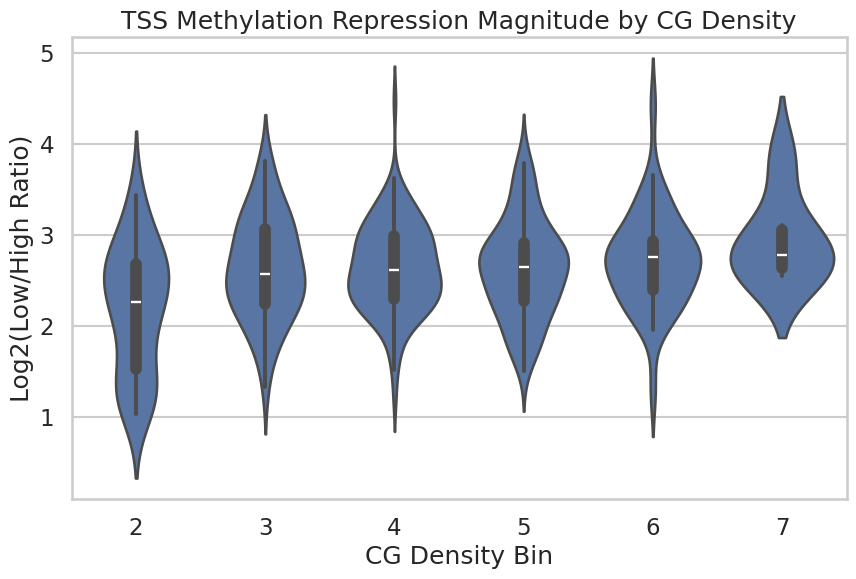

In [258]:
# violin plot of low_to_high_ratio for oligos with CG_Density = 2, 3, 4, 5, 6, 7
import seaborn as sns
tss_meth_repression_magnitude['CG_Density_Bin'] = pd.cut(tss_meth_repression_magnitude['CG_Density'], bins=[1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5], labels=['2', '3', '4', '5', '6', '7'])
plt.figure(figsize=(10, 6))
sns.violinplot(x='CG_Density_Bin', y=np.log2(tss_meth_repression_magnitude['low_to_high_ratio']), data=tss_meth_repression_magnitude, inner='box')
plt.xlabel('CG Density Bin')
plt.ylabel('Log2(Low/High Ratio)')
plt.title('TSS Methylation Repression Magnitude by CG Density')
plt.show()

In [263]:
# fit a linear regression model for log2(low_to_medium_ratio) ~ CpG_Count
import statsmodels.api as sm
X = tss_meth_repression_magnitude['CG_Density']
y = np.log2(tss_meth_repression_magnitude['low_to_high_ratio'])
X = sm.add_constant(X)  # Adds a constant term to the predictor
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      low_to_high_ratio   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     9.463
Date:                Tue, 09 Jun 2026   Prob (F-statistic):            0.00228
Time:                        22:17:16   Log-Likelihood:                -262.28
No. Observations:                 322   AIC:                             528.6
Df Residuals:                     320   BIC:                             536.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2876      0.109     21.046      0.0

# Example

In [30]:
oligo_to_chrom.get('promoter_design:tss94_real:CGTGGCGGCC')

'seq474'

In [29]:
BAM

PosixPath('/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_500_oligos_S2/STAP_TSS_500_oligos_S2.bowtie2.dedup.bam')

In [31]:
METH_RE = re.compile(r"(?:^|\|)METH=([^|]+)")
OLIGO_UMI_RE = re.compile(r"\|OLIGO=(.+)_([ACGTNacgtn]{22})$")

def parse_query_name(query_name):
    meth_match = METH_RE.search(query_name)
    oligo_match = OLIGO_UMI_RE.search(query_name)
    meth = meth_match.group(1) if meth_match else "UNKNOWN"
    oligo = oligo_match.group(1) if oligo_match else "UNKNOWN"
    umi = oligo_match.group(2).upper() if oligo_match else "UNKNOWN"
    return oligo, meth, umi

def read1_tss_1based(read):
    return int(read.reference_end) if read.is_reverse else int(read.reference_start) + 1

rows = []
with pysam.AlignmentFile('../results/barcode_pipeline/STAP_TSS_500_oligos_S2/STAP_TSS_500_oligos_S2.bowtie2.dedup.seq474.bam', "rb") as bam:
    for read in bam.fetch(until_eof=True):
        if not read.is_read1:
            continue
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        if read.is_qcfail or read.is_duplicate:
            continue
        oligo, meth, umi = parse_query_name(read.query_name)
        aligned_chrom = bam.get_reference_name(read.reference_id)
        expected_chrom = oligo_to_chrom.get(oligo, "UNKNOWN")
        if expected_chrom == "UNKNOWN":
            status = "unknown_oligo_tag"
        elif aligned_chrom == expected_chrom:
            status = "aligned_to_barcode_oligo"
        else:
            status = "misaligned_to_other_oligo"
        rows.append({
            "read_name": read.query_name,
            "oligo_id": oligo,
            "meth_state": meth,
            "umi": umi,
            "expected_chrom": expected_chrom,
            "aligned_chrom": aligned_chrom,
            "tss_position": read1_tss_1based(read),
            "mapq": read.mapping_quality,
            "is_reverse": read.is_reverse,
            "status": status,
        })

read1_df = pd.DataFrame(rows)
print(f"Deduplicated primary mapped read1 records: {len(read1_df):,}")
display(read1_df.head())

Deduplicated primary mapped read1 records: 2,483


,read_name,oligo_id,meth_state,umi,expected_chrom,aligned_chrom,tss_position,mapq,is_reverse,status
0,VH01570:206:AAJ2NL3M5:1:1304:56348:19724|METH=10%|OLIGO=SyntheticTSS:6035934:AACTGAGGGC_CTGTTTTCAGAATGGGGTGGGA,SyntheticTSS:6035934:AACTGAGGGC,10%,CTGTTTTCAGAATGGGGTGGGA,seq278,seq474,54,42,True,misaligned_to_other_oligo
1,VH01570:206:AAJ2NL3M5:1:1207:29384:56338|METH=10%|OLIGO=SyntheticTSS:6035934:AACTGAGGGC_CTGTTGTAAGAATGGGGTGGGA,SyntheticTSS:6035934:AACTGAGGGC,10%,CTGTTGTAAGAATGGGGTGGGA,seq278,seq474,54,42,True,misaligned_to_other_oligo
2,VH01570:206:AAJ2NL3M5:1:2608:52921:19288|METH=20%|OLIGO=promoter_design:tss94_real:CGTGGCGGCC_GACGTTCTGTTTATAGGAATTA,promoter_design:tss94_real:CGTGGCGGCC,20%,GACGTTCTGTTTATAGGAATTA,seq474,seq474,141,42,False,aligned_to_barcode_oligo
3,VH01570:206:AAJ2NL3M5:1:1610:14558:44430|METH=20%|OLIGO=promoter_design:tss94_real:CGTGGCGGCC_CCTAAGCTGTGATAGGTGTTTT,promoter_design:tss94_real:CGTGGCGGCC,20%,CCTAAGCTGTGATAGGTGTTTT,seq474,seq474,150,42,False,aligned_to_barcode_oligo
4,VH01570:206:AAJ2NL3M5:1:2505:25086:33866|METH=0.1%|OLIGO=promoter_design:tss94_real:CGTGGCGGCC_ATCCCCGCAGATGTAAGTAATT,promoter_design:tss94_real:CGTGGCGGCC,0.1%,ATCCCCGCAGATGTAAGTAATT,seq474,seq474,153,42,False,aligned_to_barcode_oligo


In [34]:
aligned_read1_df = read1_df.query("status == 'aligned_to_barcode_oligo'").copy()
aligned_read1_df

,read_name,oligo_id,meth_state,umi,expected_chrom,aligned_chrom,tss_position,mapq,is_reverse,status
2,VH01570:206:AAJ2NL3M5:1:2608:52921:19288|METH=20%|OLIGO=promoter_design:tss94_real:CGTGGCGGCC_GACGTTCTGTTTATAGGAATTA,promoter_design:tss94_real:CGTGGCGGCC,20%,GACGTTCTGTTTATAGGAATTA,seq474,seq474,141,42,False,aligned_to_barcode_oligo
3,VH01570:206:AAJ2NL3M5:1:1610:14558:44430|METH=20%|OLIGO=promoter_design:tss94_real:CGTGGCGGCC_CCTAAGCTGTGATAGGTGTTTT,promoter_design:tss94_real:CGTGGCGGCC,20%,CCTAAGCTGTGATAGGTGTTTT,seq474,seq474,150,42,False,aligned_to_barcode_oligo
4,VH01570:206:AAJ2NL3M5:1:2505:25086:33866|METH=0.1%|OLIGO=promoter_design:tss94_real:CGTGGCGGCC_ATCCCCGCAGATGTAAGTAATT,promoter_design:tss94_real:CGTGGCGGCC,0.1%,ATCCCCGCAGATGTAAGTAATT,seq474,seq474,153,42,False,aligned_to_barcode_oligo
5,VH01570:206:AAJ2NL3M5:1:2205:24688:32029|METH=0.1%|OLIGO=promoter_design:tss94_real:CGTGGCGGCC_AAGCTTATATGTATATGTTGAG,promoter_design:tss94_real:CGTGGCGGCC,0.1%,AAGCTTATATGTATATGTTGAG,seq474,seq474,160,42,False,aligned_to_barcode_oligo
6,VH01570:206:AAJ2NL3M5:1:1409:59927:38068|METH=0.1%|OLIGO=promoter_design:tss94_real:CGTGGCGGCC_AAGCTTATACGTAAAAGGTGAG,promoter_design:tss94_real:CGTGGCGGCC,0.1%,AAGCTTATACGTAAAAGGTGAG,seq474,seq474,160,42,False,aligned_to_barcode_oligo
...,...,...,...,...,...,...,...,...,...,...
2478,VH01570:206:AAJ2NL3M5:1:1604:59302:1095|METH=1%|OLIGO=promoter_design:tss94_real:CGTGGCGGCC_GNACGGCTTTATTAAAAGAGGA,promoter_design:tss94_real:CGTGGCGGCC,1%,GNACGGCTTTATTAAAAGAGGA,seq474,seq474,220,42,False,aligned_to_barcode_oligo
2479,VH01570:206:AAJ2NL3M5:1:2110:10733:16486|METH=1%|OLIGO=promoter_design:tss94_real:CGTGGCGGCC_TAGGTAGCGGATATAAATGTTG,promoter_design:tss94_real:CGTGGCGGCC,1%,TAGGTAGCGGATATAAATGTTG,seq474,seq474,220,42,False,aligned_to_barcode_oligo
2480,VH01570:206:AAJ2NL3M5:1:2203:25484:28659|METH=0.1%|OLIGO=promoter_design:tss94_real:CGTGGCGGCC_CATTGGCTTAGAGAGGGATAGA,promoter_design:tss94_real:CGTGGCGGCC,0.1%,CATTGGCTTAGAGAGGGATAGA,seq474,seq474,220,42,False,aligned_to_barcode_oligo
2481,VH01570:206:AAJ2NL3M5:1:2204:14444:25914|METH=20%|OLIGO=promoter_design:tss94_real:CGTGGCGGCC_CATTGGCTGTATGTAGTATGTT,promoter_design:tss94_real:CGTGGCGGCC,20%,CATTGGCTGTATGTAGTATGTT,seq474,seq474,220,42,False,aligned_to_barcode_oligo


In [37]:
aligned_read1_df['plasmid_umi'] = aligned_read1_df['umi'].str[8:]

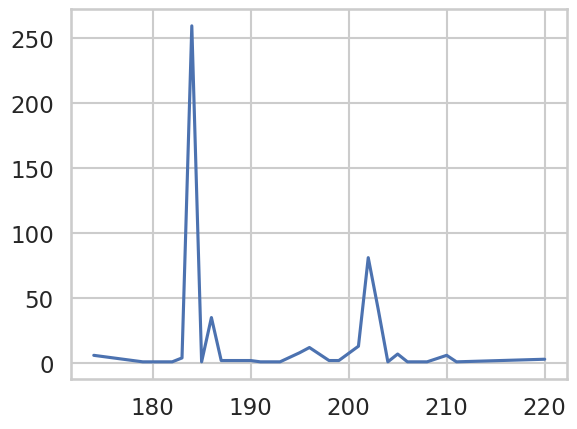

In [ ]:
plot_df = aligned_read1_df.query("meth_state == '0%'").copy()
plt.plot(plot_df.groupby('tss_position').size())

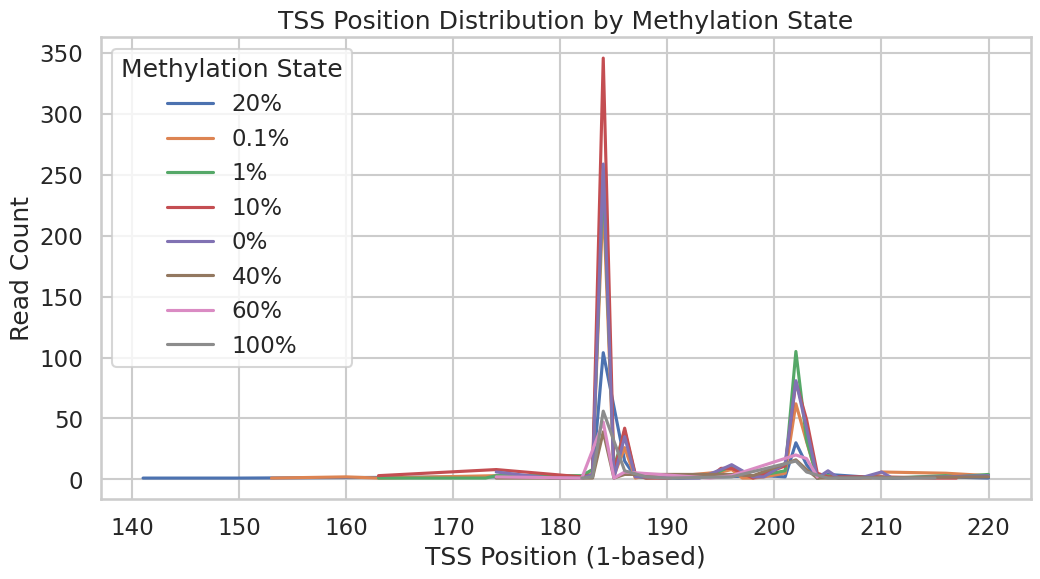

In [50]:
plot_df = aligned_read1_df.groupby(['tss_position', 'meth_state']).size().reset_index(name='count')
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='tss_position', y='count', hue='meth_state')
plt.title('TSS Position Distribution by Methylation State')
plt.xlabel('TSS Position (1-based)')
plt.ylabel('Read Count')
plt.legend(title='Methylation State')

(array([373.,   0.,   0.,  44.,   0.,   0.,   8.,   0.,   0.,   2.]),
 array([1. , 1.3, 1.6, 1.9, 2.2, 2.5, 2.8, 3.1, 3.4, 3.7, 4. ]),
 <BarContainer object of 10 artists>)

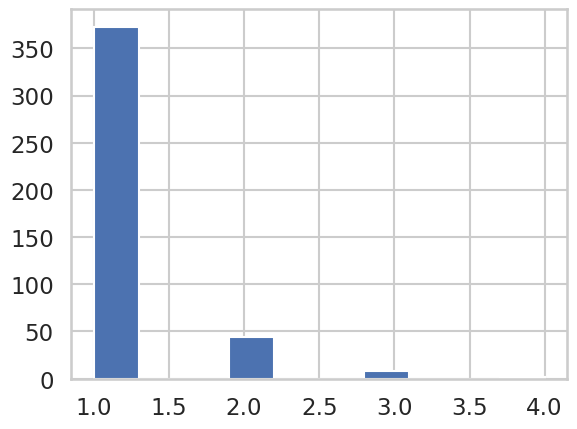

In [ ]:
plt.hist(aligned_read1_df.query("meth_state == '0%'").groupby(by=['plasmid_umi', 'tss_position']).size().reset_index(name='count')['count'], bins=10)